<h1>Required functions</h1>

In [2]:
#Visualize data output
import matplotlib.pyplot as plt
import json
import statistics
import numpy as np

In [9]:
QD = [2**i for i in range(10)]
PROCESS = [1,2,4,8]
WORKLOAD = ["randread","randwrite","read","write"]
MARKERS = [ "d", "^" , "X", "P","<",">","o","h","+"]
CALLS=0
BAR_COLOR = "springgreen"
CPU_COLOR = {
    'usr':"lightskyblue",
    'sys':"steelblue",
    'io':"black",
}


def plot_lat_percentile(experiment, name, percentile = 0,div=1, ax = None):
    if ax is None:
        ax = plt.gca()
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v) for k, v in data.items()}
    y = [i for i in data.keys() if i >= percentile]
    x = [data[i]/div for i in y]
    # Plot CDF
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    print(name, data)
    print("Percentage (95% - 50%): ", ((data[99.0] - data[50.0])/data[50.0])*100)
    ax.plot(x, y, '-'+mark,label=name)
    ax.grid(True)

def plot_lat_line(experiments, percentile, X, name, scale=1000):
    points = []
    for exp in experiments:
        if percentile is "max":
            data = op[exp]['latency']
        else:
            data = op[exp]['latency']['percentile']
            data = {float(k): float(v) for k, v in data.items()}
        points.append(data[percentile]/scale)
    print(name, percentile, points)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot([str(i) for i in X], points, '-'+mark, label=name)
    plt.grid(True)

def plot_lat_bar(experiment, name, ax, pos):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v)/10**3 for k, v in data.items()}
    boxes = [
        {
            'label' : name,
            'whislo': data[5.00],    # Bottom whisker position
            'q1'    : data[20.0],    # First quartile (25th percentile)
            'med'   : data[50.0],    # Median         (50th percentile)
            'q3'    : data[80.0],    # Third quartile (75th percentile)
            'whishi': data[95.00],    # Top whisker position
            'fliers': []        # Outliers
        }
    ]
    print(boxes)
    ax.bxp(boxes,positions=[pos])
    plt.xlabel("Experiment")
    plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
    plt.grid(True, 'both','y')

def plot_ctx_line(experiments,x,label):
    obs = []
    for exp in experiments:
        y = op[exp]['fio_cpu']['ctx']
        y = y / 1000
        obs.append(y)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(x,obs,'-'+mark,label=label)
    plt.grid(True)

def plot_net_line(experiments, key, x, label):
    obs = []
    for exp in experiments:
        y = op[exp][key]
        obs.append(y)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(x,obs,marker=mark,label=label)
    plt.grid(True)    

def plot_iops_line(experiments,x,label):
    obs = []
    err = []
    for exp in experiments:
        y = op[exp]['iops']['mean']
        y = y / 1000
        obs.append(y)
        err.append(op[exp]['iops']['stddev']/1000)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    #plt.plot(x,obs,'-'+mark,label=label)
    print(err)
    plt.errorbar(x,obs,err,marker=mark,label=label)
    plt.grid(True)


def plot_iops_across_line(experiments,x,label):
    obs = []
    for exp in experiments:
        y = op[exp]['iops_across']
        y = y / 1000
        obs.append(y)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot([str(i) for i in x],obs,'-'+mark,label=label)
    plt.grid(True)

def plot_iops_bar(experiment, name):
    y = op[experiment]['iops']['mean']
    y = y / 1000
    print(experiment,op[experiment]['iops'])
    plt.bar([name],[y],color=BAR_COLOR)
    plt.ylabel('KIOPS')
    plt.grid(True)



def plot_iops_cpu(experiments):
    pass

def plot_bw_bar(experiment, name):
    y = op[experiment]['bw']['mean']
    print(name, y)
    y = y/1000
    plt.bar([name], [y], color="lightskyblue")
    plt.xlabel("Experiment")
    plt.ylabel('Bandwidth (MBps)')
    plt.grid(True)

def plot_bw_line(experiments,x,label):
    obs = []
    for exp in experiments:
        y = op[exp]['bw']
        y = y / (1024**2)
        obs.append(y)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot([str(i) for i in x],obs,'-'+mark,label=label)
    plt.ylabel("GB/s")
    plt.grid(True)

def plot_run_time(experiments, x, label):
    results = []
    for i in experiments:
        usr = op[i]['cpu']['usr']
        sys = op[i]['cpu']['sys']
        runtime = op[i]['cpu']['total'] / 1000
        results.append(usr*runtime + sys*runtime)
    print(label, results)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot([str(i) for i in x],results, "-"+mark,label=label)
    plt.grid()


def plot_init_rp_time(experiments, x, label):
    results = []
    for i in experiments:
        print(i)
        results.append(op[i]['initiator']['reqprocessing'])
    print(label, results)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot([str(i) for i in x],results, "-"+mark,label=label)
    plt.grid()

def plot_target_blk_time(experiments, x, label):
    results = []
    for i in experiments:
        results.append(op[i]['target']['blk'])
    print(label, results)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot([str(i) for i in x],results, "-"+mark,label=label)
    plt.grid()

def cpu_utilization(experiment, name):
    cpu = op[experiment]['cpu']
    print(experiment, cpu)
    bottom=0
    for i in ['usr','sys']:
        plt.bar([name], [cpu[i]],color=CPU_COLOR[i],bottom=bottom, label=i)
        bottom += cpu[i]
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def cpu_init_utilization(experiment, name, plot_cpu):
    cpu = op[experiment]['init_cpu']
    print(experiment, cpu)

    if plot_cpu == -1:
        plot_cpu="all"
    else:
        plot_cpu = str(plot_cpu)

    bottom=0
    for i in ['usr','sys','io']:
        plt.bar([name], [float(cpu[plot_cpu][i])],color=CPU_COLOR[i],bottom=bottom, label=i)
        bottom += float(cpu[plot_cpu][i])
    
    print("CPU util : ", bottom - float(cpu[plot_cpu][i]))
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def cpu_local_utilization(experiment, name, plot_cpu):
    cpu = op[experiment]['local_cpu']
    print(experiment, cpu)

    if plot_cpu == -1:
        plot_cpu="all"
    else:
        plot_cpu = str(plot_cpu)

    bottom=0
    for i in ['usr','sys','io']:
        plt.bar([name], [float(cpu[plot_cpu][i])],color=CPU_COLOR[i],bottom=bottom, label=i)
        bottom += float(cpu[plot_cpu][i])
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def cpu_target_utilization(experiment, name):
    cpu = op[experiment]['target_cpu']
    print(experiment, cpu)
    bottom=0
    plot_cpu = 'all'
    plot_cpu_util = 0
    for i in cpu.keys():
        if i != 'all':
            util = float(cpu[i]['sys'])
            if util > plot_cpu_util:
                plot_cpu = i
                plot_cpu_util = util

    for i in ['sys']:
        plt.bar([name], [float(cpu[plot_cpu][i])], color=CPU_COLOR[i], bottom=bottom, label=i)
        bottom += float(cpu[plot_cpu][i])
        
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def plot_iops_ts(file, name, lim=-1):
    try:
        f = open(file,'r')
    except:
        return
    
    numbers = []
    obs = []
    prev_ts = 0
    for i in f.readlines():
        try:
            ts = int(i.split(",")[0])
            if prev_ts > ts:
                numbers = []
                obs.append(numbers)
            prev_ts = ts
            numbers.append(int(i.split(",")[1])/1000)
        except:
            pass
    obs.append(numbers)
    obs = [sum(i) for i in zip(*obs)]
    plt.plot(obs[:lim],label=name)
    print(name, statistics.median(obs), statistics.mean(obs))
    #plt.axhline(y=statistics.median(obs), linestyle='dashed')
    #plt.axhline(y=statistics.mean(obs), linestyle='dotted')

def plot_lat_iops(experiments, percentile, names):
    dic = {}
    for exp,name in zip(experiments, names):
        iops = op[exp]['iops']['mean']
        data = op[exp]['latency']['percentile']
        data = {float(k): float(v) for k, v in data.items()}
        dic[name] = [data[percentile]/1000, iops/1000]
    return dic


def microbench(data, toplot, percentile, plot_key, plot_target = True):
    block = data[toplot][str(percentile)]["block"]
    nvmeof_init = data[toplot][str(percentile)]["nvmeof_initiator"]
    tcp = data[toplot][str(percentile)]["tcp"]
    target = data[toplot][str(percentile)]["target"]
    print(data[toplot][str(percentile)])
    bar_width = 0.4
    plt.bar(plot_key, block, bar_width, label='Block')
    plt.bar(plot_key, nvmeof_init, bar_width, bottom=block, label='NVMeOF Initiator')
    plt.bar(plot_key, tcp, bar_width, bottom=block + nvmeof_init, label='TCP')
    if plot_target:
        plt.bar(plot_key, target, bar_width, bottom=block + nvmeof_init + tcp, label='Target')



<>:33: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:33: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipykernel_3038008/621947941.py:33: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if percentile is "max":


<h1>Performance</h1>

In [3]:
fp = open("./performance/crunched_numbers_performance.json")
op = json.load(fp)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in PROCESS:
    for j in QD:
        try:
            plot_iops_bar("local_SSD_randwrite_QD{}_P{}".format(j,i),"QD{}P{}".format(j,i))
        except:
            pass
plt.title('IOPS bar graph for random write operation')

In [ ]:
BAR_COLOR="springgreen"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i in QD:
    plot_iops_bar("local_SSD_randread_QD{}_P1".format(i),"QD{}".format(i))
plt.title('IOPS vs queue depths 1P (random read on local setup)')
plt.xlabel("Queue depths")

In [ ]:
BAR_COLOR="springgreen"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i in QD:
    plot_iops_bar("remote_poll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('IOPS vs queue depths 1P.4KB.iou (random read on remote(NVMeoF-TCP) setup)')
plt.xlabel("Queue depths")

In [ ]:
BAR_COLOR="springgreen"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i in QD:
    plot_iops_bar("remote_poll_iou+p_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('IOPS vs queue depths 1P.4KB.iou+p (random read on remote(NVMeoF-TCP) setup)')
plt.xlabel("Queue depths")

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_utilization("local_SSD_randread_QD{}_P1".format(i),"QD{}".format(i))
plt.title('CPU utilization vs queue depths')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_utilization("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at initiator for different queue depths (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou","npoll_ioup","poll_ioup"]:
    experiments=[]
    for i in QD:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_ctx_line(experiments, QD, "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Context switch count for different iouring modes (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('Context switches')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_init_utilization("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i), 0)
plt.title('CPU utilization at initiator for different queue depths with iou (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_local_utilization("local_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i), 0)
plt.title('CPU utilization at initiator for different queue depths with iou (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_init_utilization("remote_npoll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i), 0)
plt.title('CPU utilization at initiator for different queue depths with iou+p (random reads on NVMeoF)')
plt.xlabel("Queue depth")
#plt.yticks([20 * i for i in range(6)])
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    experiments = []
    for j in ["npoll_iou","poll_iou"]:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    cpu_target_utilization(experiments,"QD{}".format(i))
plt.title('CPU utilization at target for different queue depths with iou (random reads on NVMeoF)')
plt.xlabel("Queue depth")

"""
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
"""

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_target_utilization("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at target for different queue depths with iou+p (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_utilization("remote_poll_iou+p_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at initiator for different queue depths (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
BAR_COLOR="springgreen"
fig, ax = plt.subplots(figsize=(25, 6), dpi=200)
for i in PROCESS:
    for j in QD:
        plot_iops_bar("local_SSD_randread_QD{}_P{}".format(j,i),"P{}.QD{}".format(i,j))
plt.title('IOPS bar graph for random read operation')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for j in PROCESS:
    experiments=[]
    for i in QD:
        experiments.append("local_SSD_randread_QD{}_P{}".format(i, j))
    plot_iops_line(experiments, QD, "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS vs number of processes (random read on local)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou","npoll_ioup","poll_ioup"]:
    experiments=[]
    for i in PROCESS:
        experiments.append("remote_{}_SSD_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, PROCESS, "{}".format(j).split("_")[1])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of cores with QD128 (random read on NVMeoF-TCP)')
plt.xlabel("Number of process")
plt.ylabel('KIOPS')
plt.legend()

No polling [117.55350833300001, 230.18966176799998, 390.462732218, 460.07523431000004]
polling [117.51241841, 150.34360251, 324.907200837, 460.178949791]


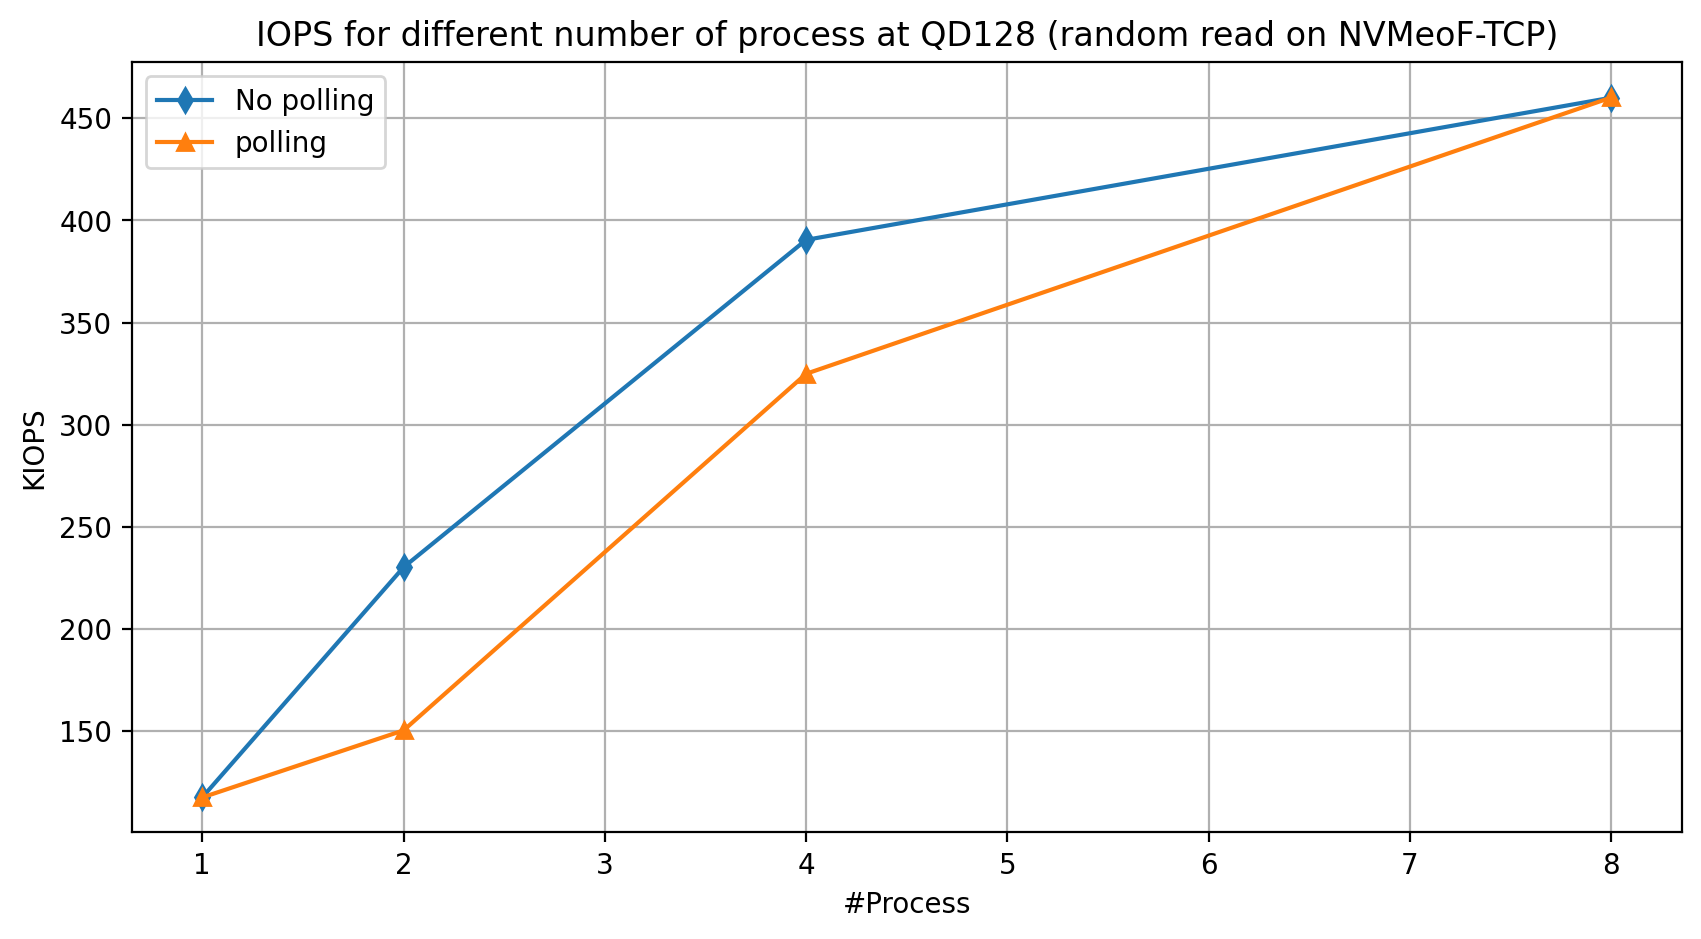

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["No polling","polling"]
for en, j in enumerate(["perf_npoll_ioup","poll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8]:
        experiments.append("remote_{}_SSD_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, [1, 2, 4, 8], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of process at QD128 (random read on NVMeoF-TCP)')
plt.xlabel("#Process")
plt.ylabel('KIOPS')
plt.legend()

iou [6.379275, 12.491479167, 21.266552301, 36.757225, 64.980276151, 86.013770833, 78.563366667, 94.667304167, 92.898849372]
[0.222589626, 0.49140961099999997, 1.208891077, 2.033286539, 7.433132565, 13.117076353, 10.423274697, 7.073770497000001, 6.6351163500000006]
iou + poll on block [7.878103333, 15.938784641, 24.763488333, 42.635261667, 64.886836667, 89.029878333, 94.01438333300001, 112.950098333, 112.598106845]
[0.18439249000000002, 0.414025812, 1.087826419, 2.008202989, 3.2610294800000004, 6.185399615000001, 6.6735739569999994, 8.210291726, 7.890470697]
iou + poll on NVMeoF-TCP [9.025849372, 17.753815900000003, 28.506121339, 49.201025105, 79.100389121, 106.977460251, 116.689761506, 117.51241841, 94.043451883]
[0.11413987, 0.290668123, 1.213134677, 2.088125046, 6.651967533, 9.790402935, 10.33847385, 7.841830423, 7.980201043]


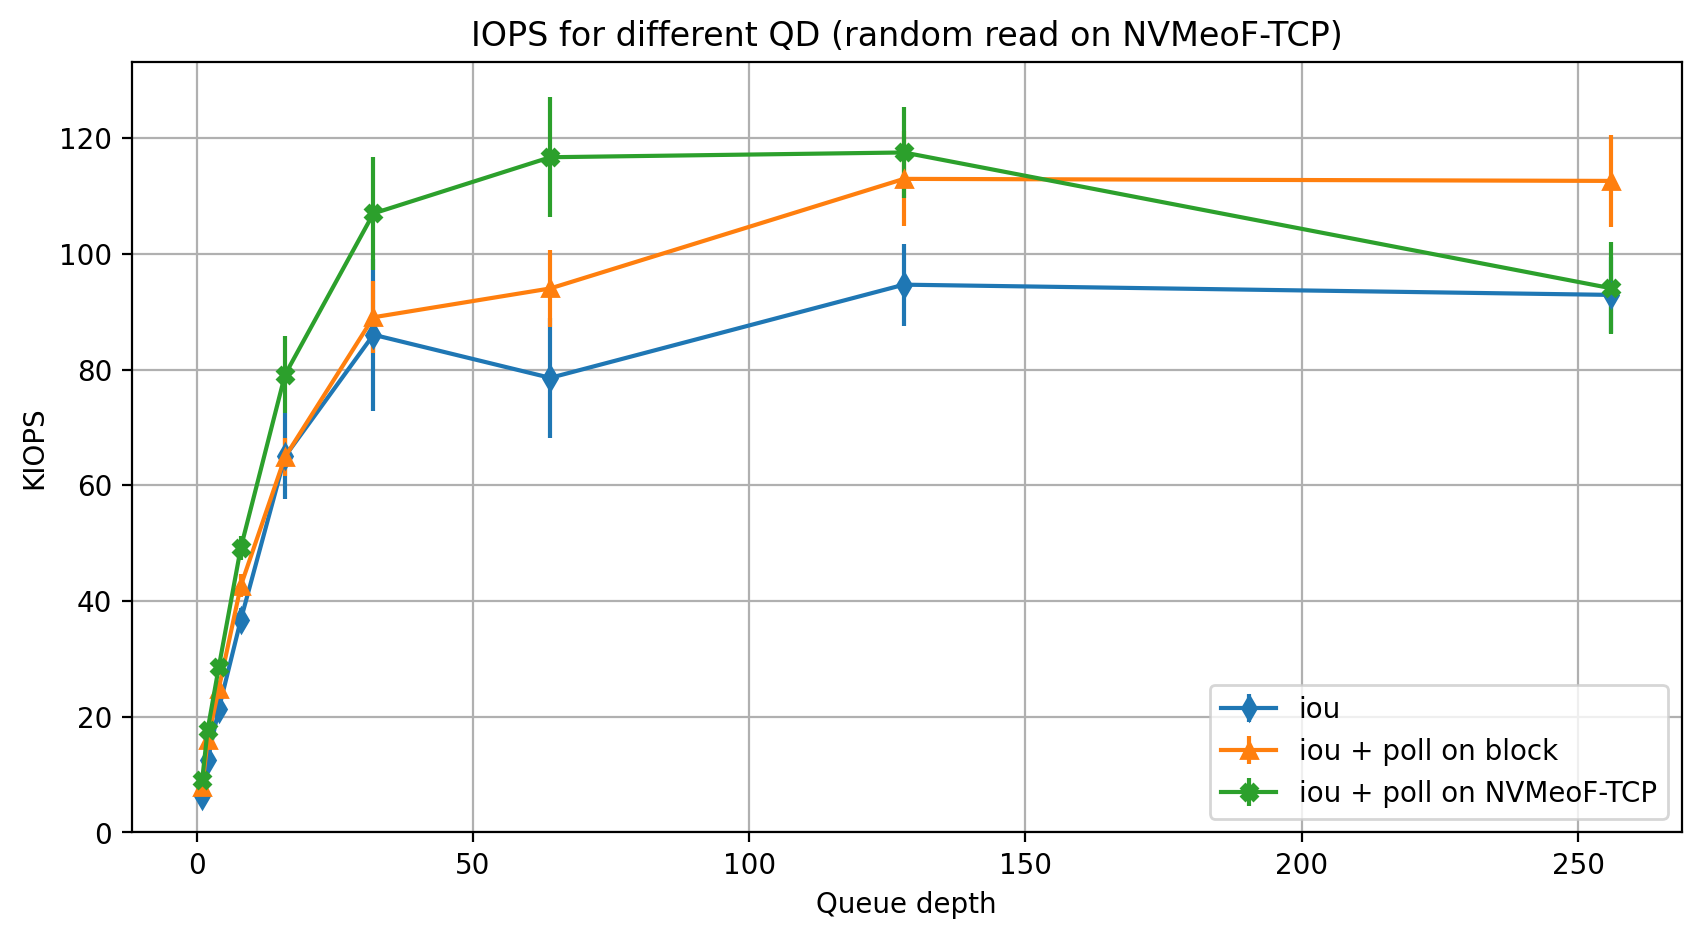

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["iou","iou + poll on block","iou + poll on NVMeoF-TCP"]
for en, j in enumerate(["npoll_iou","perf_npoll_ioup","poll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8, 16 ,32, 64, 128, 256]:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_iops_line(experiments, [1, 2, 4, 8, 16 ,32, 64, 128, 256], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different QD (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.ylim(bottom=0)
plt.legend()

1P [6.676857741, 13.380372385000001, 21.419275000000003, 33.462133333, 50.124091667, 51.207711297, 59.426058333, 88.07269583300001, 90.017591667]
[0.329812661, 0.693491713, 1.591967315, 2.097105676, 4.7504242450000005, 7.138357051, 6.355601614, 7.895284782, 7.552178289]


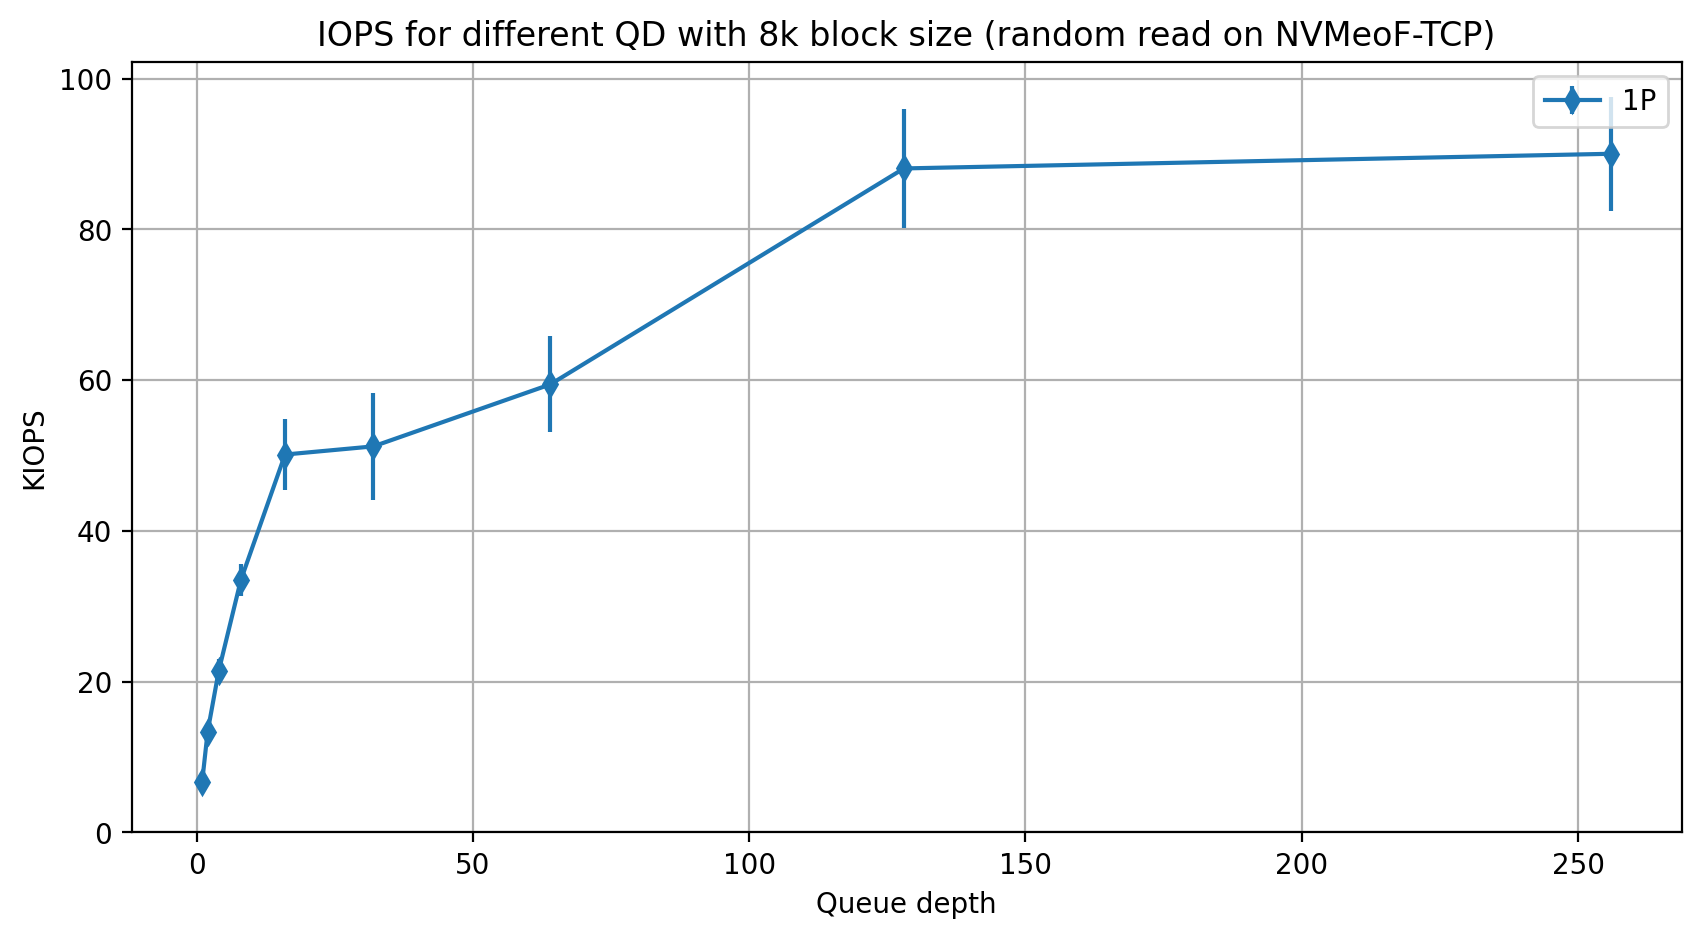

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["iou","iou + poll on block","iou + poll on NVMeoF-TCP"]
for en, j in enumerate([1]):
    experiments=[]
    for i in [1, 2, 4, 8, 16 ,32, 64, 128, 256]:
        experiments.append("remote_npoll_iou_SSD_randread_QD{}_P{}_8k".format(i, j))
    plot_iops_line(experiments, [1, 2, 4, 8, 16 ,32, 64, 128, 256], "{}P".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different QD with 8k block size (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.ylim(bottom=0)
plt.legend()

1P [17.069198333, 25.655134999999998, 33.63749, 40.044551667, 68.41997, 73.257593333, 65.560916667, 82.840255426, 76.39608666699999]
[0.890263114, 1.577568474, 3.1501395189999997, 3.215209773, 5.0618656689999995, 9.87755, 5.380497547, 2.981130333, 9.433229077]


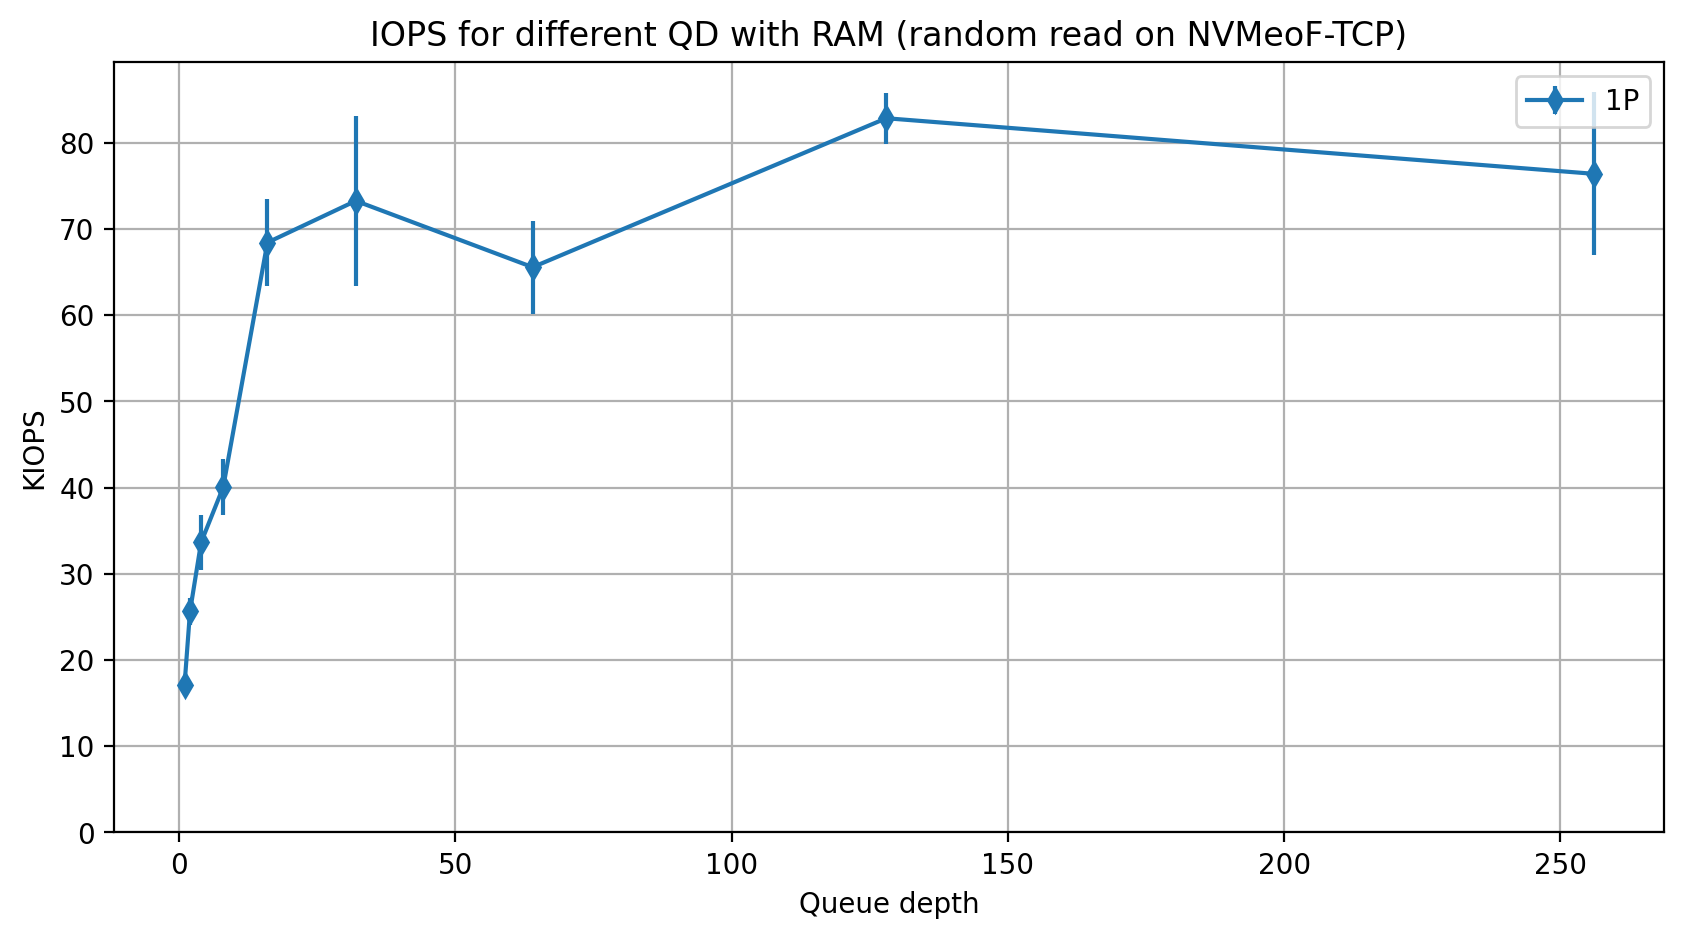

In [8]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["iou","iou + poll on block","iou + poll on NVMeoF-TCP"]
for en, j in enumerate([1]):
    experiments=[]
    for i in [1, 2, 4, 8, 16 ,32, 64, 128, 256]:
        experiments.append("remote_perf_iou_RAM_randread_QD{}_P{}_4k".format(i, j))
    plot_iops_line(experiments, [1, 2, 4, 8, 16 ,32, 64, 128, 256], "{}P".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different QD with RAM (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.ylim(bottom=0)
plt.legend()

1P [9.595621667, 18.306853333, 33.674558333, 45.133855000000004, 45.090795, 45.230116667000004, 45.34688, 45.141885, 45.050986667]
[0.027416442, 0.209929001, 0.088882056, 0.099666425, 0.08800085199999999, 0.077537258, 0.15990977899999997, 0.194881142, 0.17176243400000002]


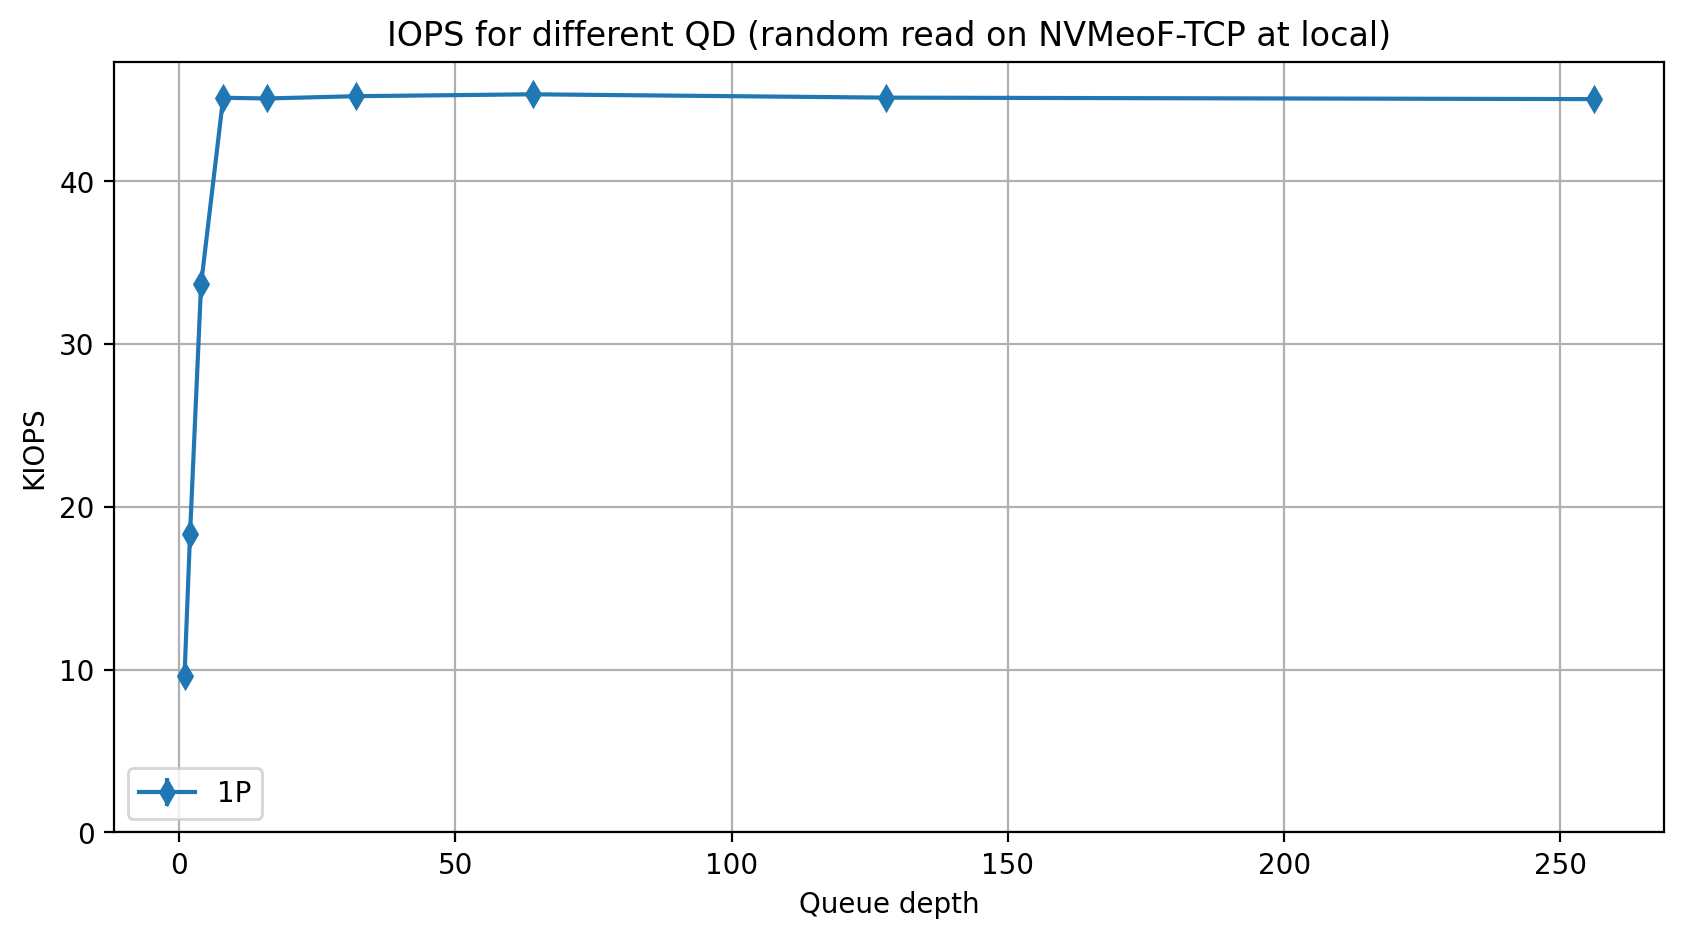

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["iou","iou + poll on block","iou + poll on NVMeoF-TCP"]
for en, j in enumerate([1]):
    experiments=[]
    for i in [1, 2, 4, 8, 16 ,32, 64, 128, 256]:
        experiments.append("localtcp_perf_iou_SSD_randread_QD{}_P{}_4k".format(i, j))
    plot_iops_line(experiments, [1, 2, 4, 8, 16 ,32, 64, 128, 256], "{}P".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different QD (random read on NVMeoF-TCP at local)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.ylim(bottom=0)
plt.legend()

95 [171.008, 189.44, 259.072, 309.248, 382.976, 684.032, 1368.064, 1843.2, 3817.472]
95 [127.488, 132.096, 222.208, 268.288, 391.168, 602.112, 1044.48, 1384.448, 2998.272]
95 [111.104, 116.224, 193.536, 207.872, 261.12, 378.88, 684.032, 1368.064, 4046.848]


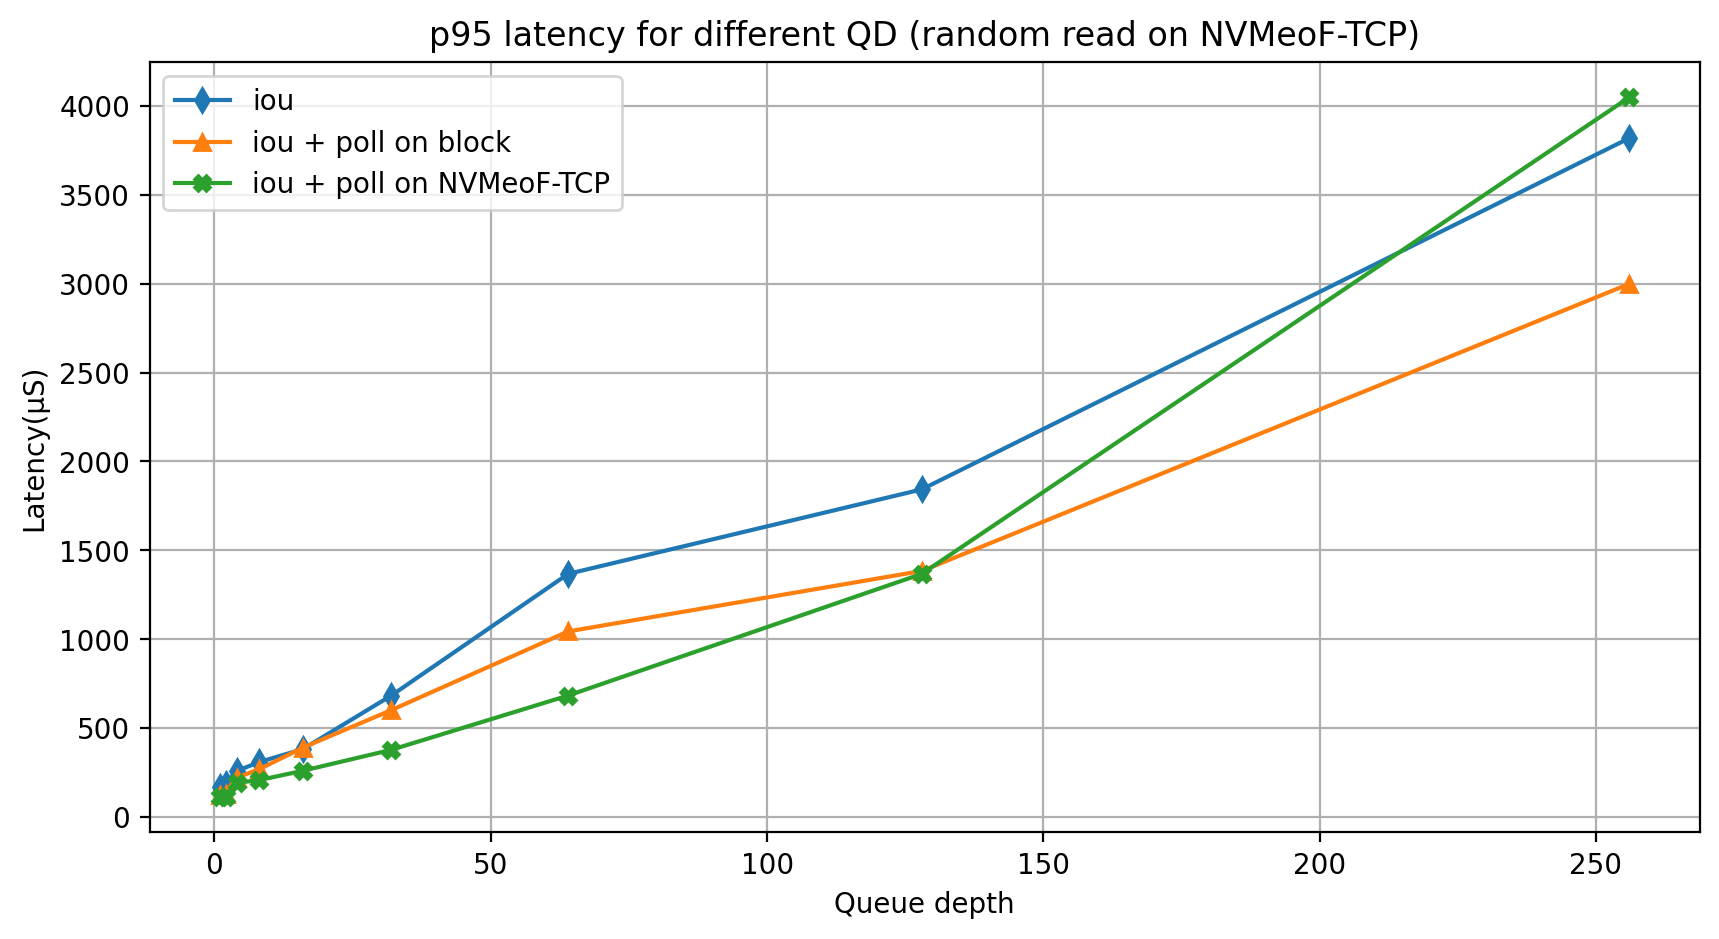

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["iou","iou + poll on block","iou + poll on NVMeoF-TCP"]
for en, j in enumerate(["npoll_iou","perf_npoll_ioup","poll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8, 16 ,32, 64, 128, 256]:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_lat_line(experiments, 95, [1, 2, 4, 8, 16 ,32, 64, 128, 256], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p95 latency for different QD (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
plt.legend()

NameError: name 'op' is not defined

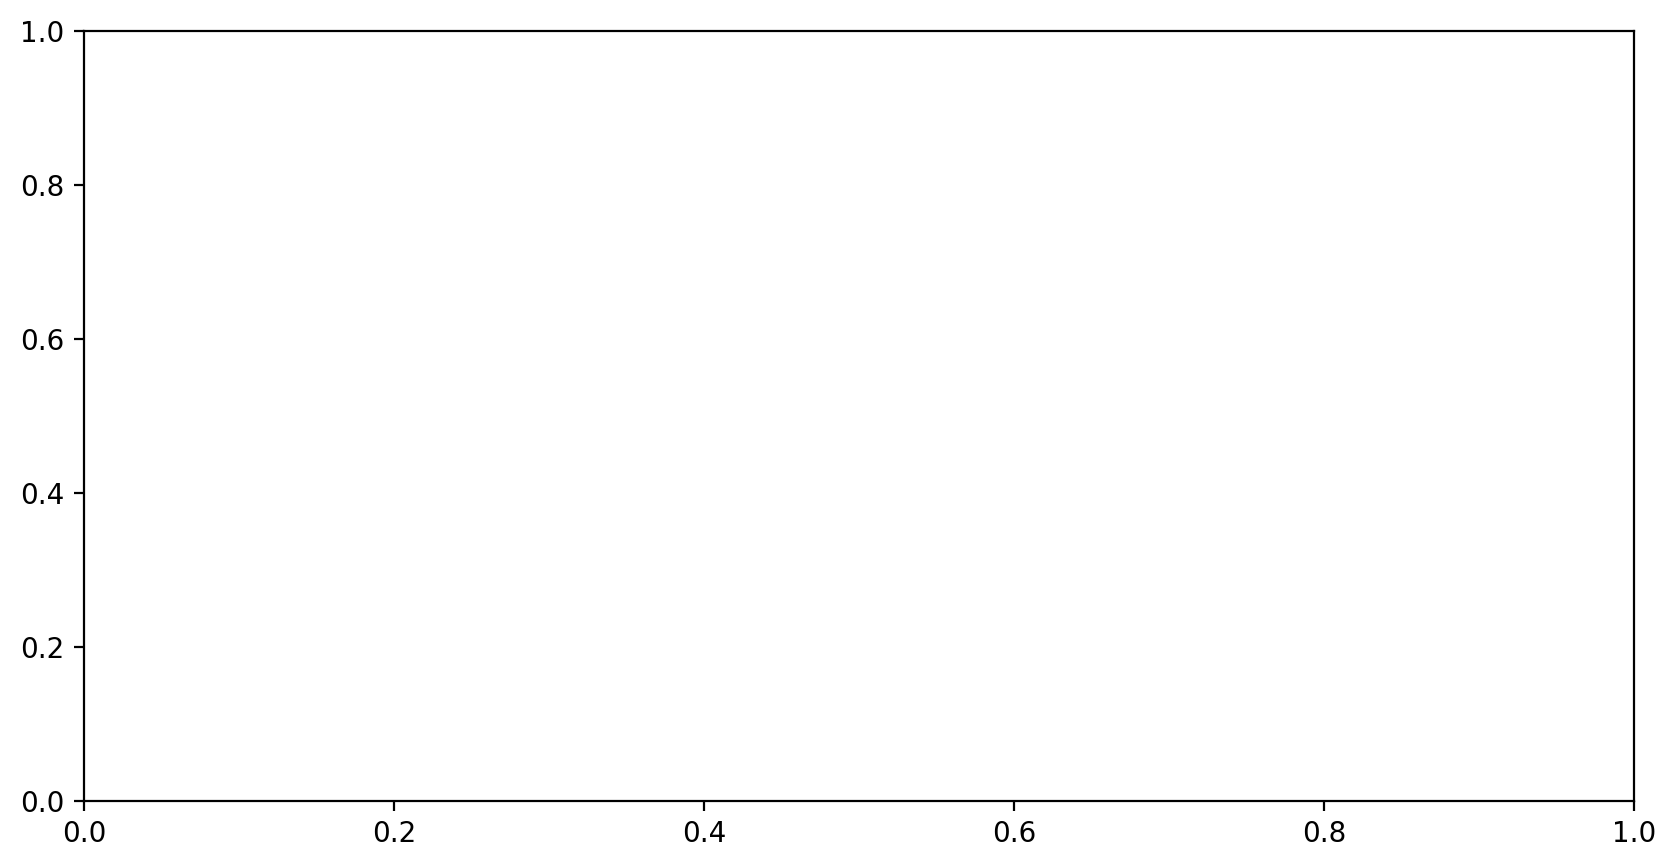

In [3]:

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["No polling","polling"]
for en, j in enumerate(["perf_npoll_ioup","poll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8, 16 ,32, 64, 128]:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_lat_line(experiments, 95, [1, 2, 4, 8, 16 ,32, 64, 128], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('P95 latency for different QD (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
plt.grid(True)
plt.legend()

95 [82.432, 88.576, 144.384, 175.104, 234.496, 333.824]
95 [134.144, 140.288, 199.68, 280.576, 378.88, 514.048]


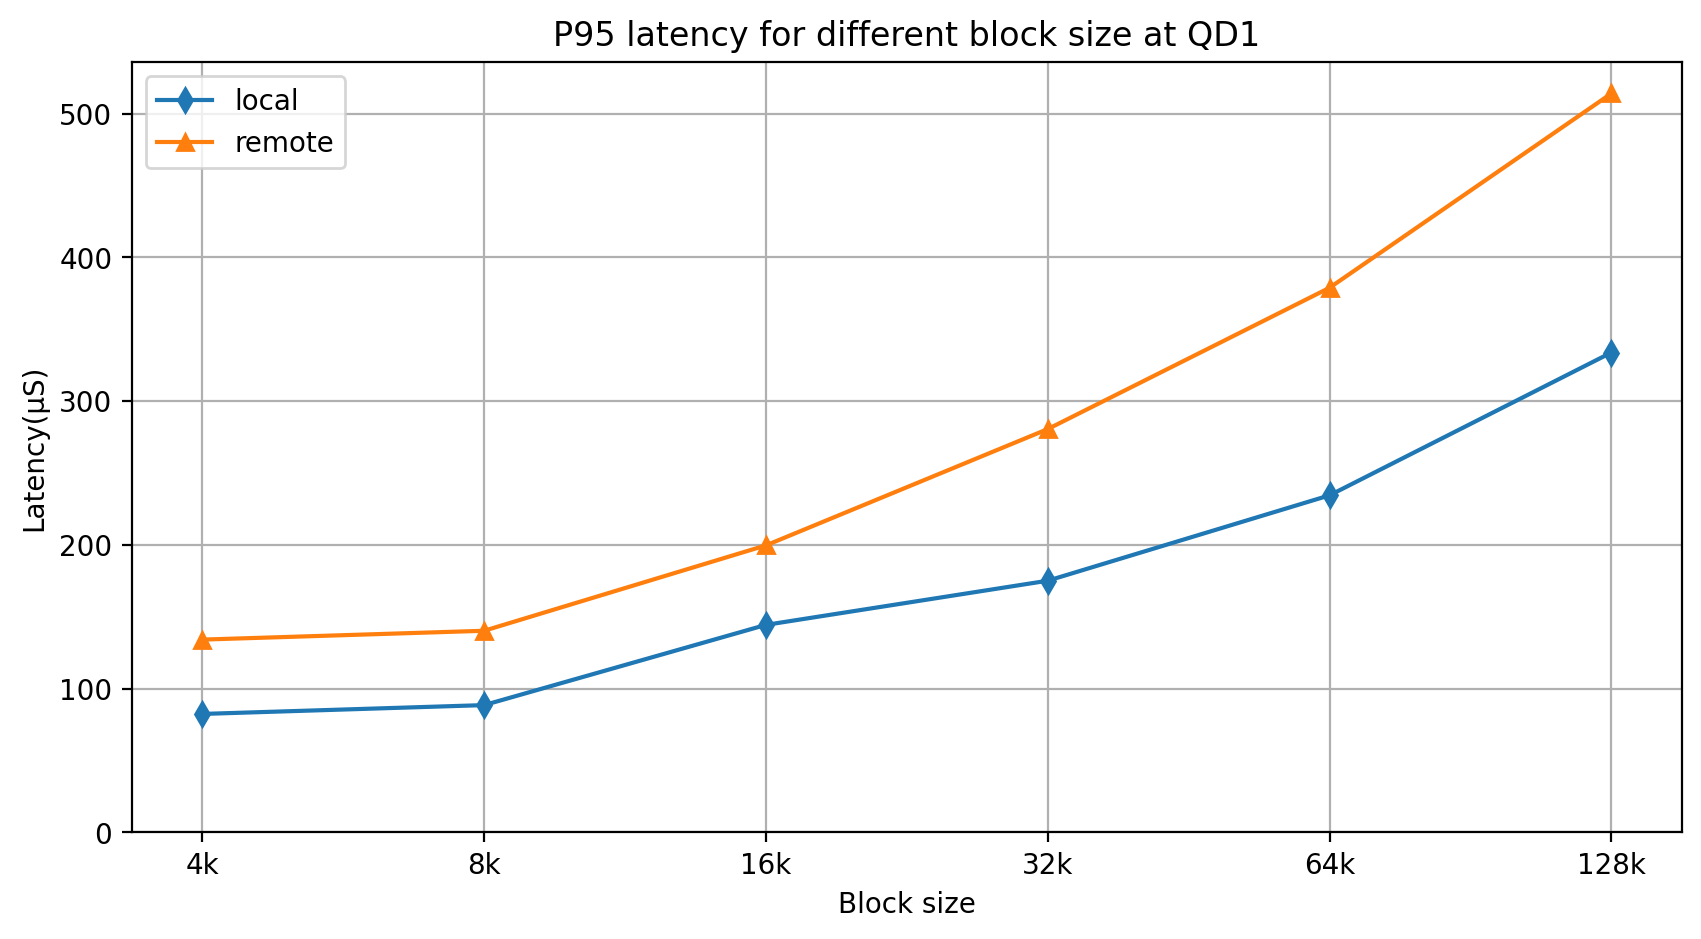

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["localhost_perf_ioup","remote_perf_npoll_ioup"]):
    experiments=[]
    for i in ["4k", "8k", "16k", "32k", "64k", "128k"]:
        experiments.append("{}_SSD_randread_QD1_P1_{}".format(j, i))
    plot_lat_line(experiments, 95, ["4k", "8k", "16k", "32k", "64k", "128k"], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('P95 latency for different block size at QD1')
plt.xlabel("Block size")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
plt.ylim(bottom=0)
plt.legend()

95 [82.432, 83.456, 94.72, 116.224]
95 [134.144, 134.144, 142.336, 164.864]


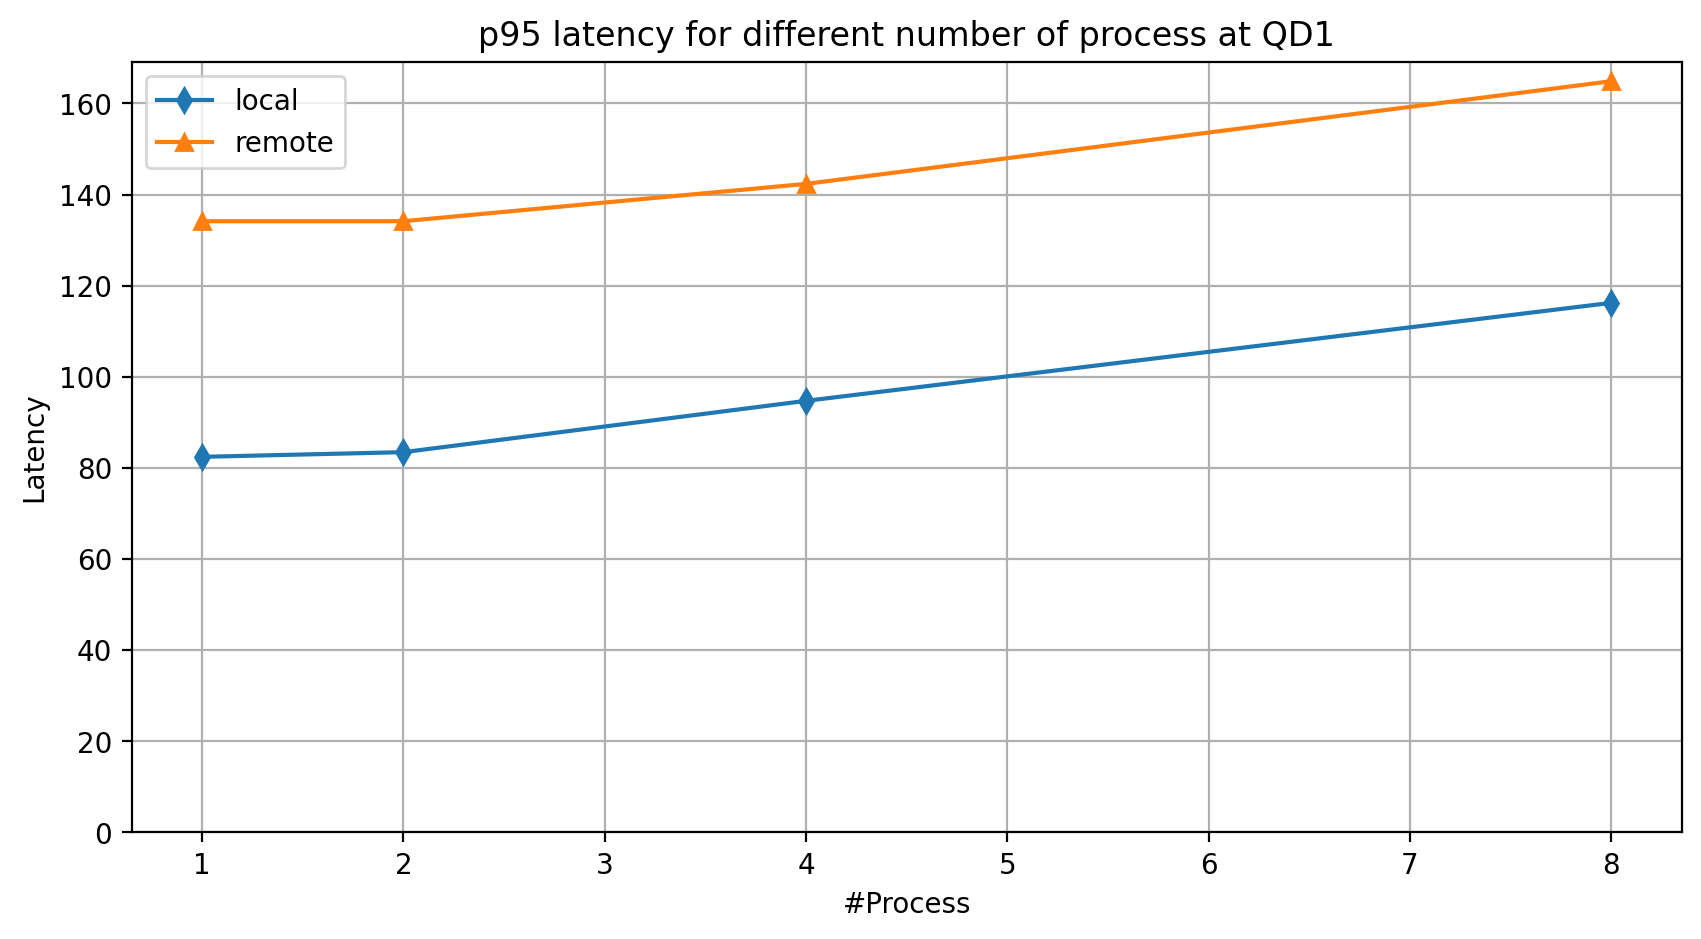

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["localhost_perf_ioup","remote_perf_npoll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8]:
        experiments.append("{}_SSD_randread_QD1_P{}_4k".format(j, i))
    plot_lat_line(experiments, 95, [1, 2, 4, 8], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p95 latency for different number of process at QD1')
plt.xlabel("#Process")
plt.ylabel('Latency')
plt.ylim(bottom=0)
plt.legend()

local [326.374679167, 458.957366667, 460.22673640200003, 460.58589121299997]
[1.069047717, 0.945087057, 0.43727468199999997, 11.773151234]
remote [112.950098333, 230.18966176799998, 390.462732218, 460.07523431000004]
[8.210291726, 8.752445109, 6.290679383, 2.8482640110000004]


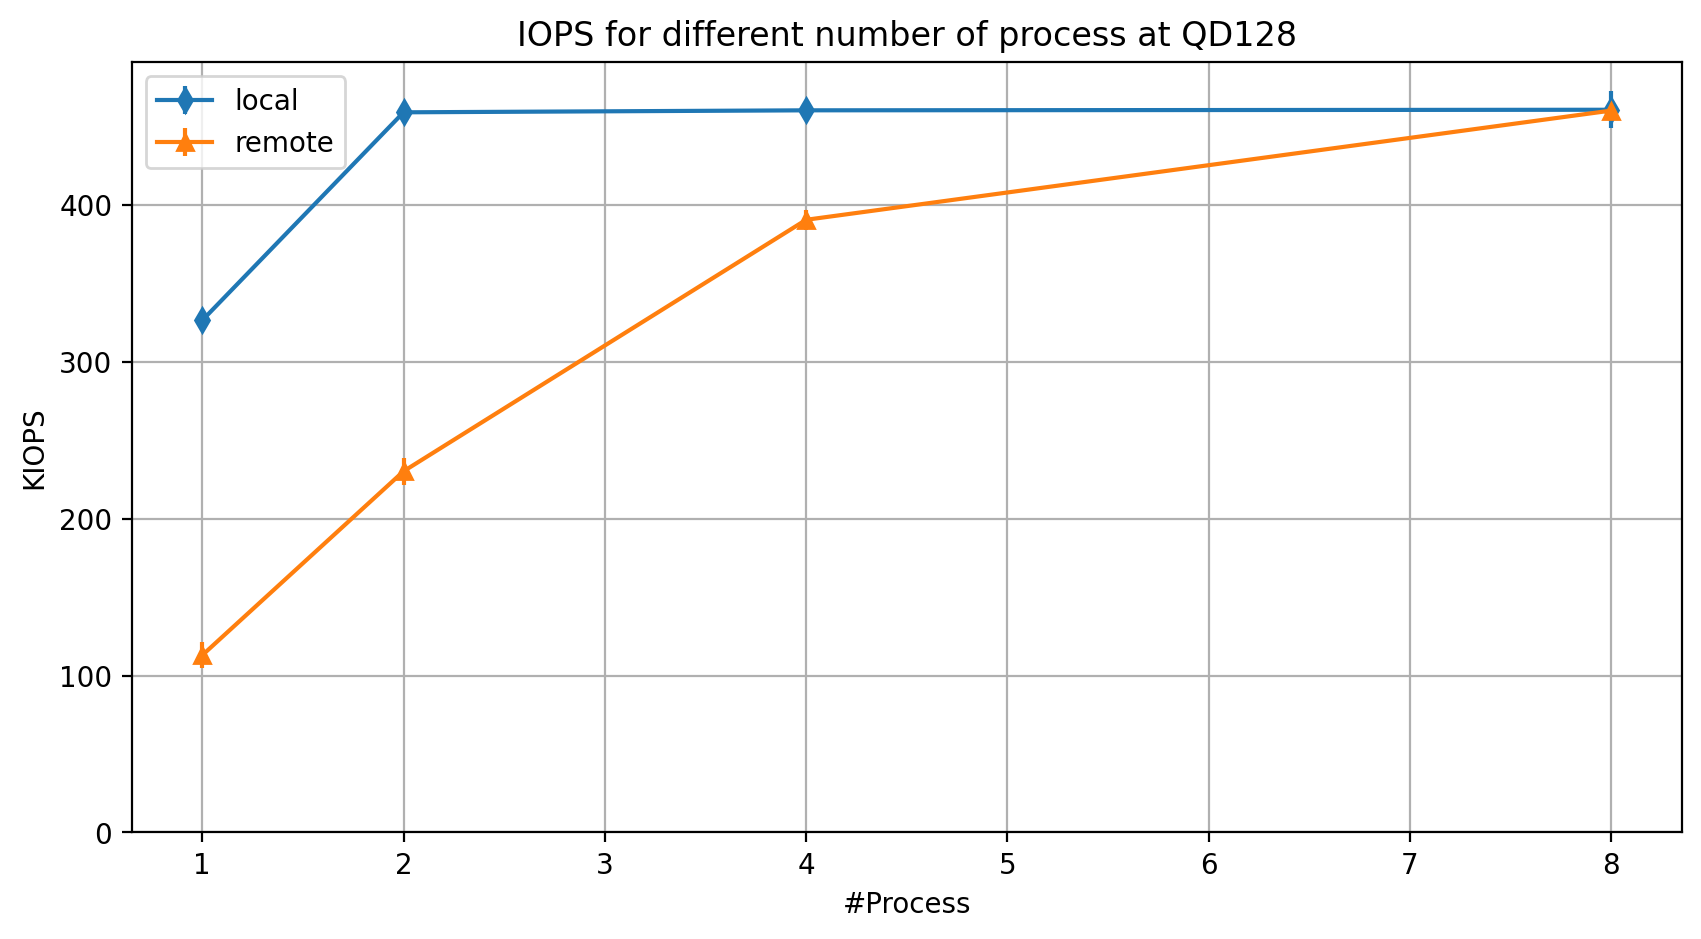

In [12]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["localhost_perf_ioup","remote_perf_npoll_ioup"]):
    experiments=[]
    for i in [1,2,4,8]:
        experiments.append("{}_SSD_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, [1,2,4,8], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of process at QD128')
plt.xlabel("#Process")
plt.ylabel('KIOPS')
plt.ylim(bottom=0)
plt.legend()

local [326.374679167, 170.846170833, 95.298720833, 53.7255375, 28.071412499999997, 11.088391667]
remote [117.55350833300001, 115.32124583299999, 88.720966667, 52.348641667, 27.605929167, 11.088666667]


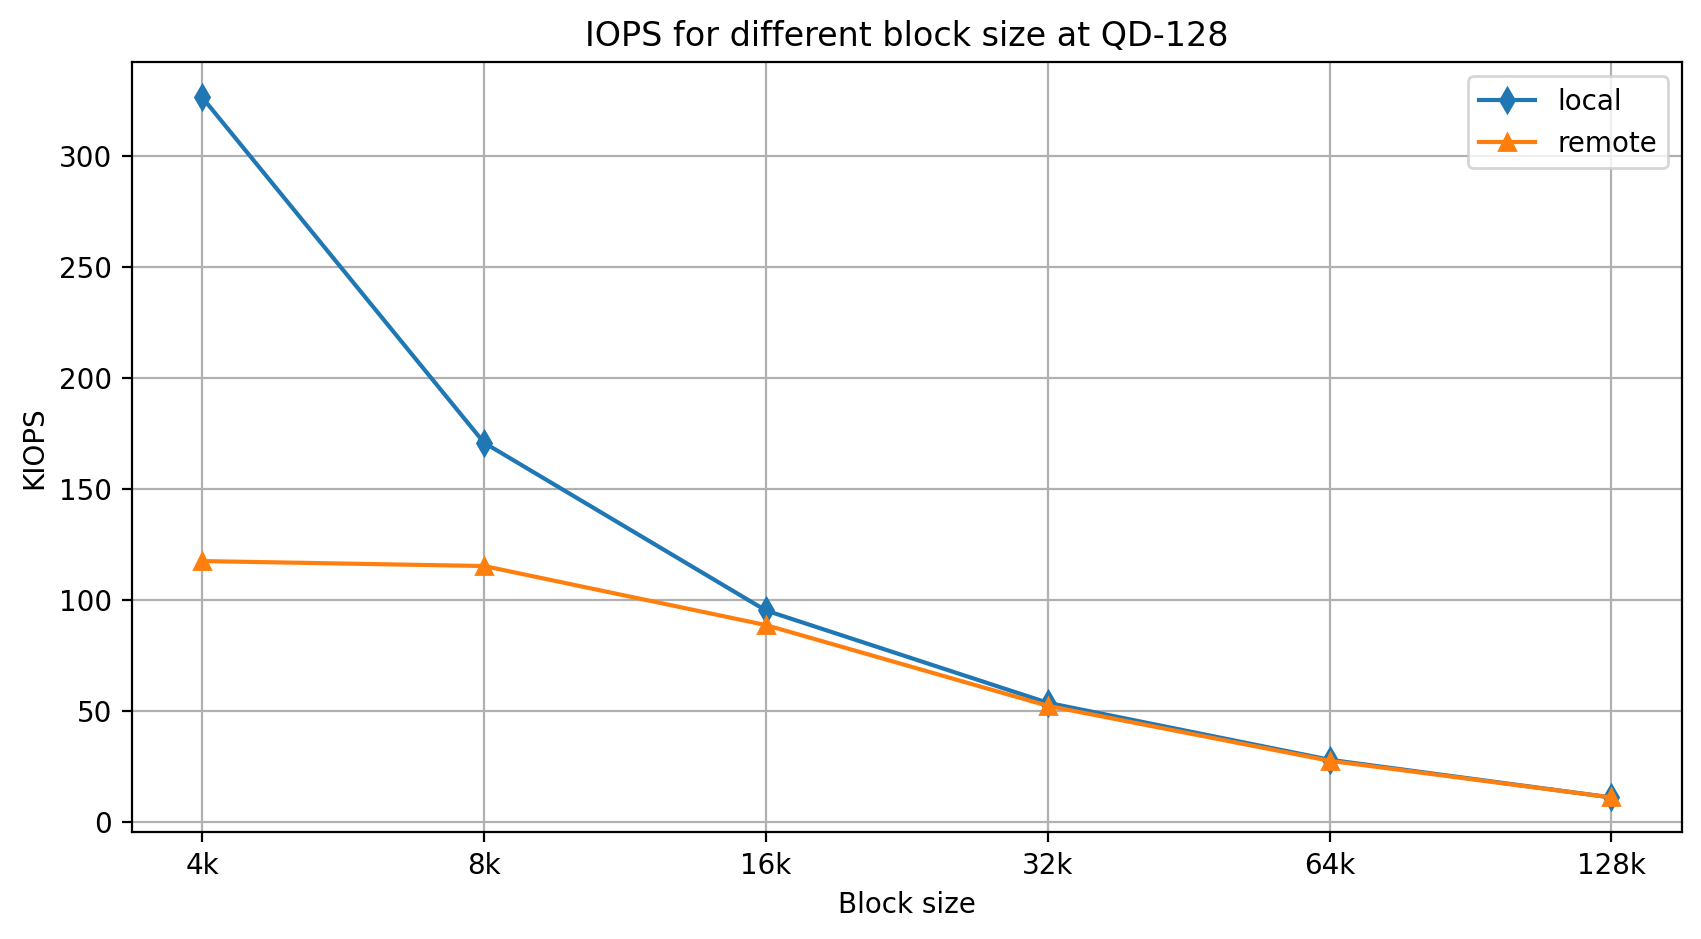

In [20]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["localhost_perf_ioup","remote_perf_npoll_ioup"]):
    experiments=[]
    for i in ["4k", "8k", "16k", "32k", "64k", "128k"]:
        experiments.append("{}_SSD_randread_QD128_P1_{}".format(j, i))
    plot_iops_line(experiments, ["4k", "8k", "16k", "32k", "64k", "128k"], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different block size at QD-128')
plt.xlabel("Block size")
plt.ylabel('KIOPS')
plt.legend()

With aRFS [122.14377499999999, 228.517585, 420.76533389, 460.073202003]
[10.319616057, 8.772700854999998, 7.895238977, 3.486779107]
Without aRFS [115.012513333, 222.705081057, 390.462732218, 460.07523431000004]
[8.098143179, 8.028674003, 6.290679383, 2.8482640110000004]


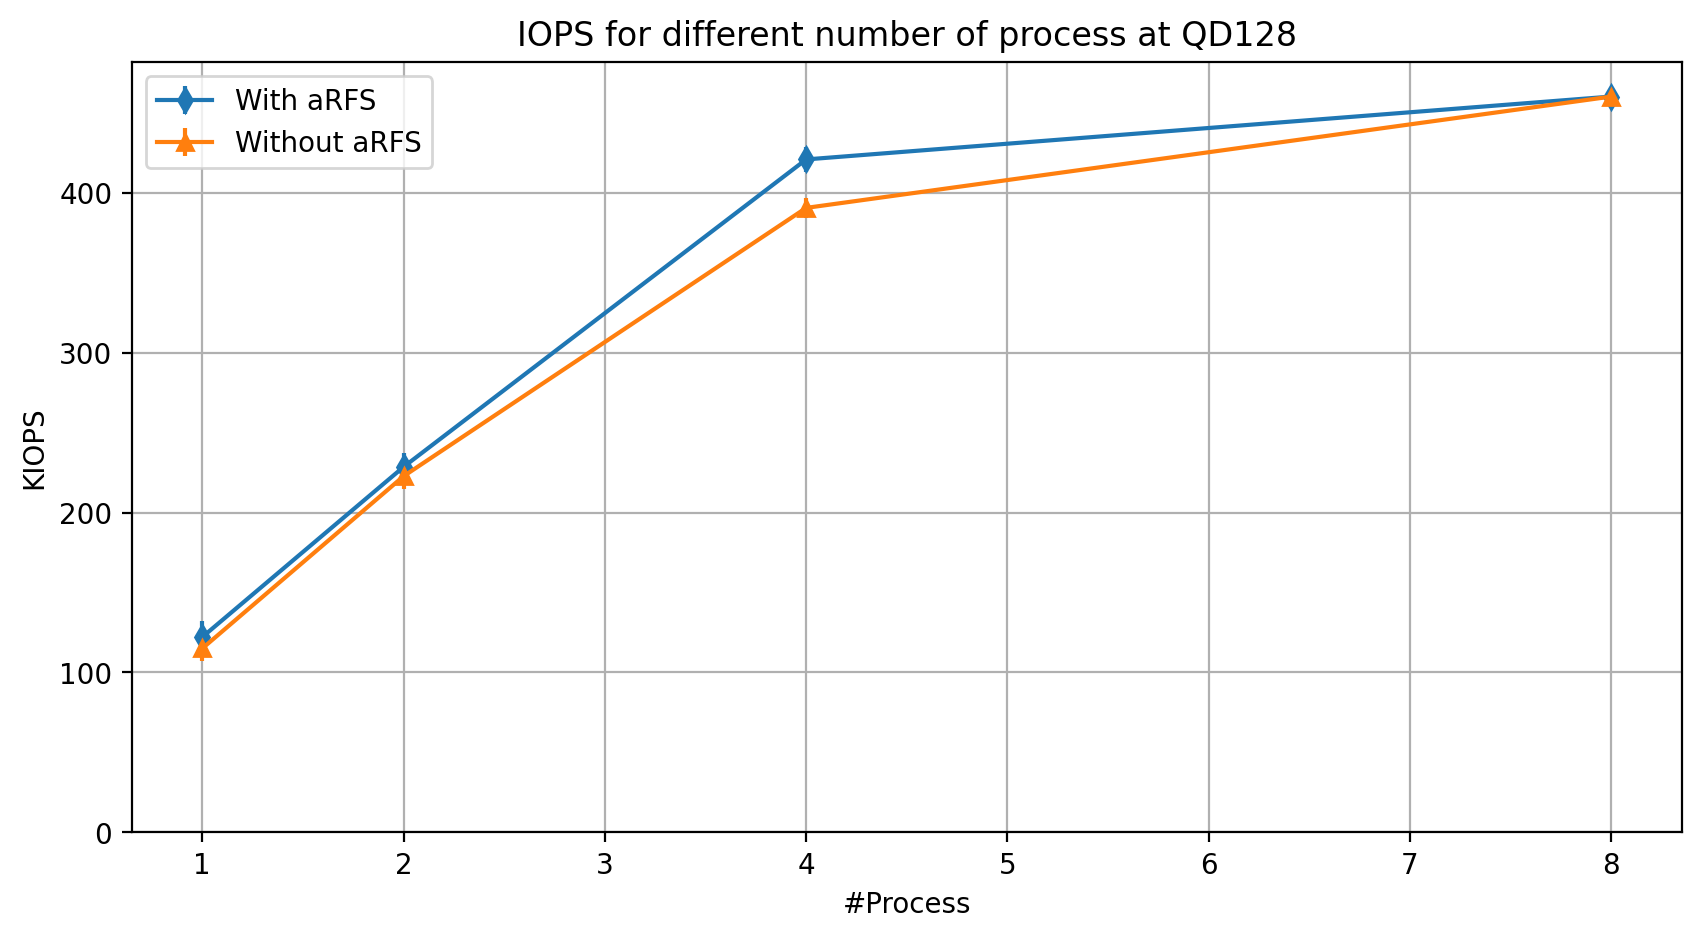

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["With aRFS","Without aRFS"]
for en, j in enumerate(["remote_perf_arfs_ioup","remote_perf_npoll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8]:
        experiments.append("{}_SSD_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, [1, 2, 4, 8], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of process at QD128')
plt.xlabel("#Process")
plt.ylabel('KIOPS')
plt.ylim(bottom=0)
plt.legend()

95 [121.344, 124.416, 132.096, 156.672]
95 [132.096, 132.096, 142.336, 164.864]


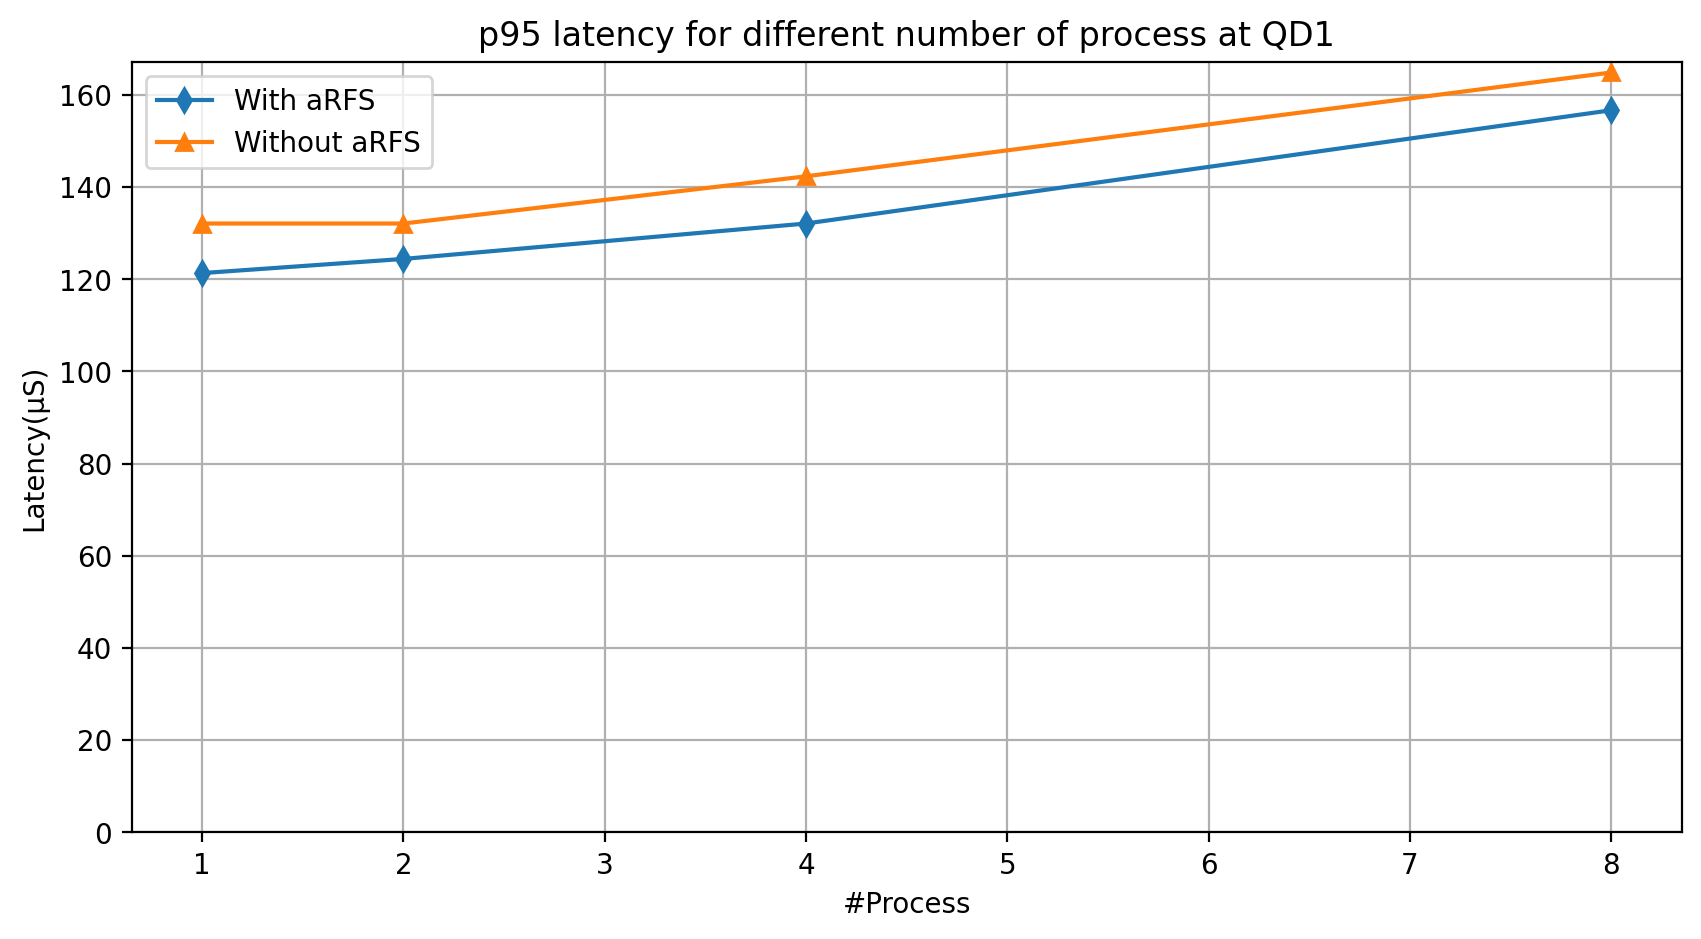

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["With aRFS","Without aRFS"]
for en, j in enumerate(["remote_perf_arfs_ioup","remote_perf_npoll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8]:
        experiments.append("{}_SSD_randread_QD1_P{}_4k".format(j, i))
    plot_lat_line(experiments, 95,[1, 2, 4, 8], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p95 latency for different number of process at QD1')
plt.xlabel("#Process")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
plt.ylim(bottom=0)
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["No polling","polling"]
for en, j in enumerate(["perf_npoll_ioup","poll_ioup"]):
    experiments=[]
    for i in [1, 2, 4, 8]:
        experiments.append("remote_{}_SSD_randread_QD1_P{}_4k".format(j, i))
    plot_lat_line(experiments, 95, [1, 2, 4, 8], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('P95 latency for different number of process at QD1 (random read on NVMeoF-TCP)')
plt.xlabel("#Process")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
plt.legend()

NVMeoF [6.379275, 12.491479167, 21.266552301, 36.757225, 64.980276151, 86.013770833, 78.563366667, 94.667304167, 92.898849372]
[0.222589626, 0.49140961099999997, 1.208891077, 2.033286539, 7.433132565, 13.117076353, 10.423274697, 7.073770497000001, 6.6351163500000006]
DAS [12.267470832999999, 30.446408333, 39.680625, 53.575104167, 90.12123333299999, 146.960425, 232.375008333, 291.511493724, 338.680987448]
[0.029953227, 2.5070748800000002, 2.473954318, 7.3805653940000004, 10.241771661000001, 11.828341277, 20.874084737, 3.900307041, 0.7650833730000001]


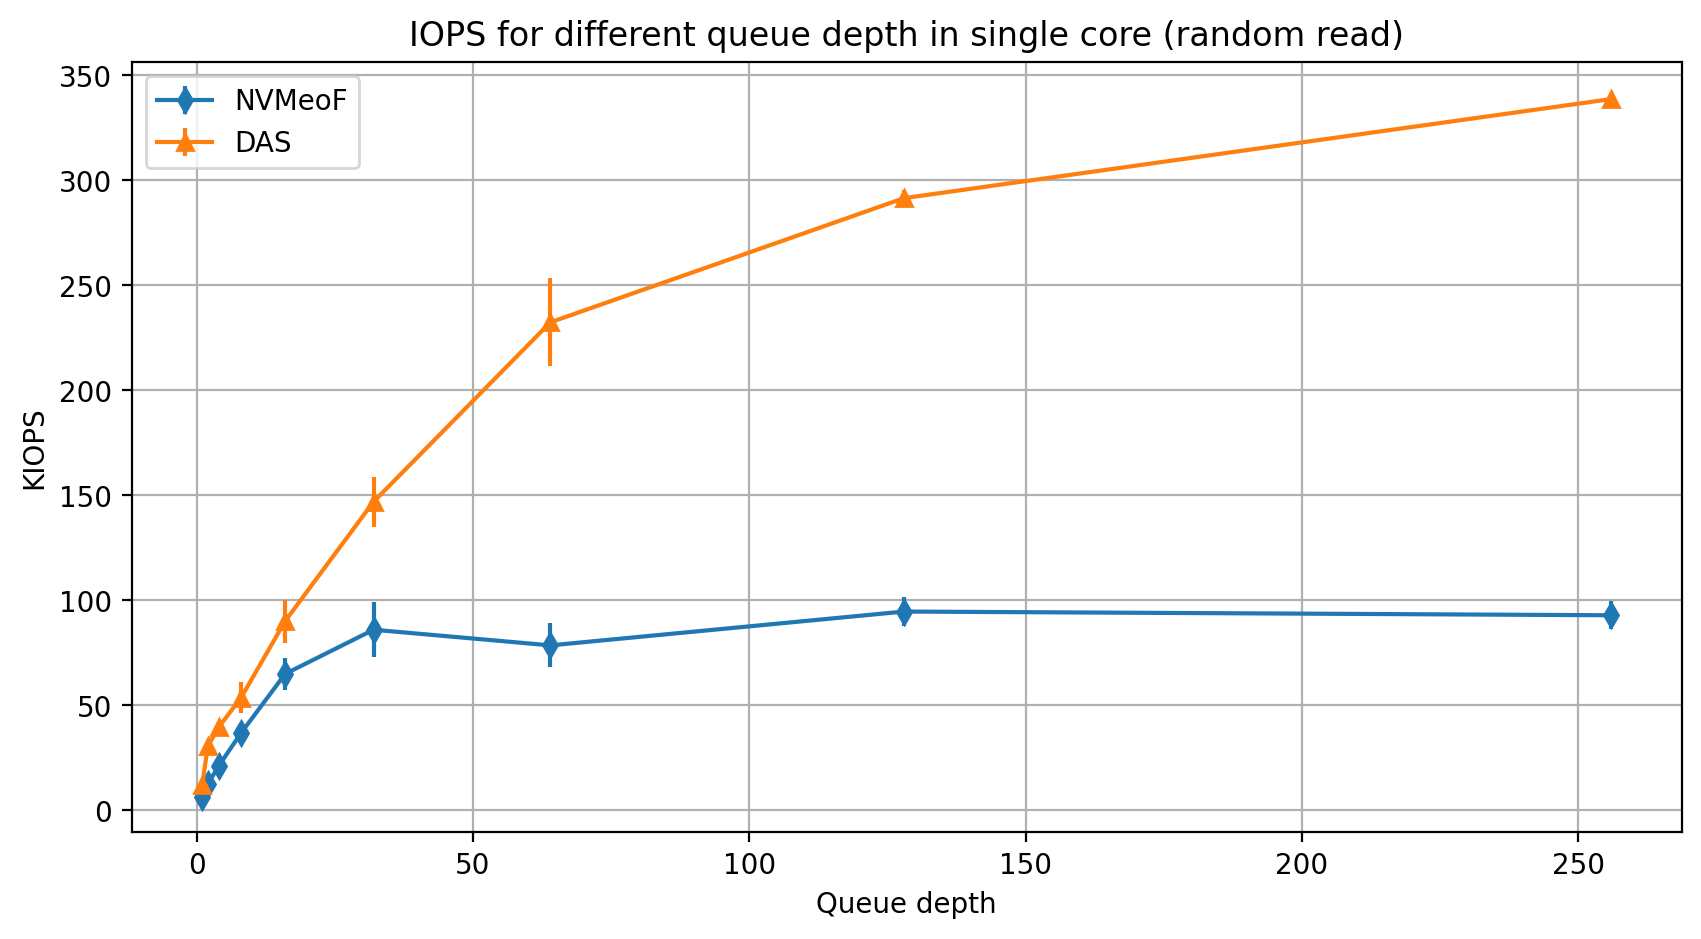

In [17]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["NVMeoF","DAS","iou polling w NVMeoF CQ polling"]
for en, j in enumerate(["remote_npoll_iou","local_poll_iou"]):
    experiments=[]
    for i in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
        experiments.append("{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_iops_line(experiments, [1, 2, 4, 8, 16, 32, 64, 128, 256], labels[en])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different queue depth in single core (random read)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

95 [173.056, 195.584, 261.12, 577.536, 1073.152, 2007.04, 3457.024, 10944.512]
95 [181.248, 242.688, 272.384, 489.472, 1105.92, 2113.536, 3883.008, 8159.232]
95 [175.104, 193.536, 261.12, 577.536, 1056.768, 1957.888, 3391.488, 10813.44]
95 [175.104, 203.776, 272.384, 610.304, 1073.152, 2023.424, 3457.024, 10682.368]


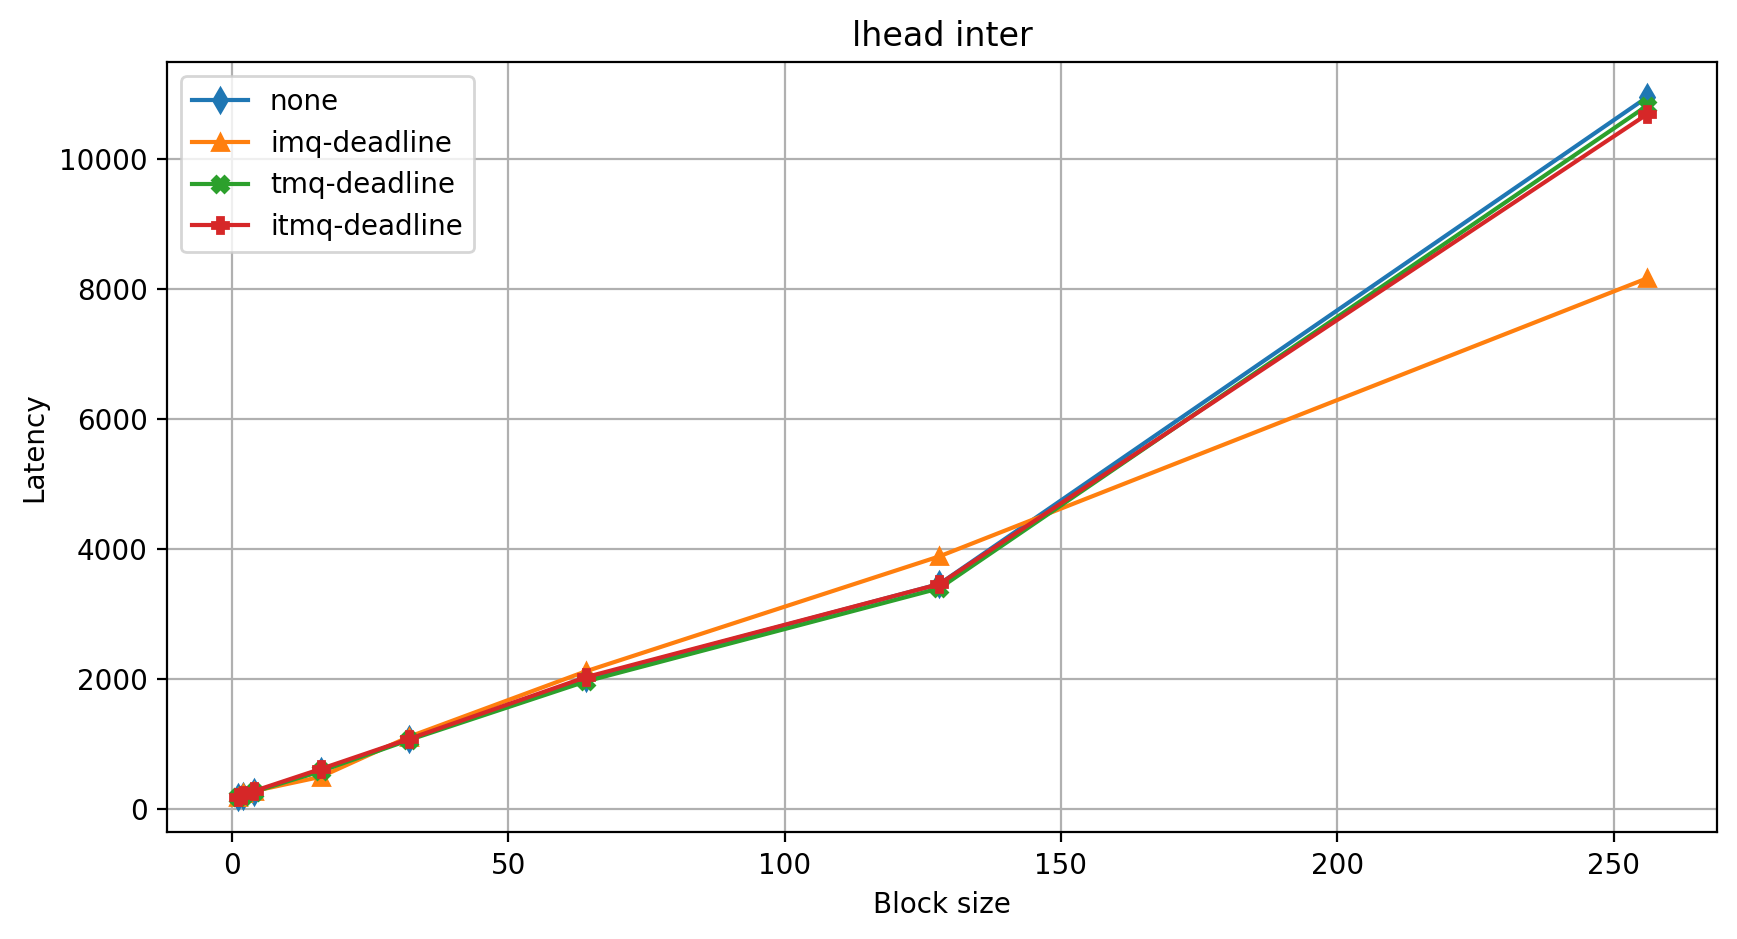

In [21]:
#Interference of the scheduler
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["none","imq-deadline","tmq-deadline","itmq-deadline"]):
    experiments=[]
    for i in [1, 2, 4, 16, 32, 64, 128, 256]:
        experiments.append("remote_lhead_inter_{}_iou_RAM_randread_QD1_P{}_4k".format(j, i))
    plot_lat_line(experiments, 95,[1, 2, 4, 16, 32, 64, 128, 256],j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('lhead inter')
plt.xlabel("Block size")
plt.ylabel('Latency')
plt.legend()

In [ ]:
#Interference of the scheduler
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["none","imq-deadline","tmq-deadline","itmq-deadline"]):
    experiments=[]
    for i in [1, 2, 4, 16, 32, 64, 128, 256]:
        experiments.append("remote_lhead_inter_{}_iou_RAM_randread_QD1_P{}_4k".format(j, i))
    plot_lat_line(experiments, 95,[1, 2, 4, 16, 32, 64, 128, 256],j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('lhead inter')
plt.xlabel("Block size")
plt.ylabel('Latency')
plt.legend()

95 [173.056, 199.68, 268.288, 407.552, 741.376, 1318.912, 1875.968, 3522.56]
95 [177.152, 214.016, 276.48, 460.8, 798.72, 1515.52, 2277.376, 4112.384]
95 [173.056, 201.728, 268.288, 428.032, 823.296, 1204.224, 1728.512, 3588.096]
95 [173.056, 199.68, 272.384, 391.168, 774.144, 1269.76, 1859.584, 3588.096]


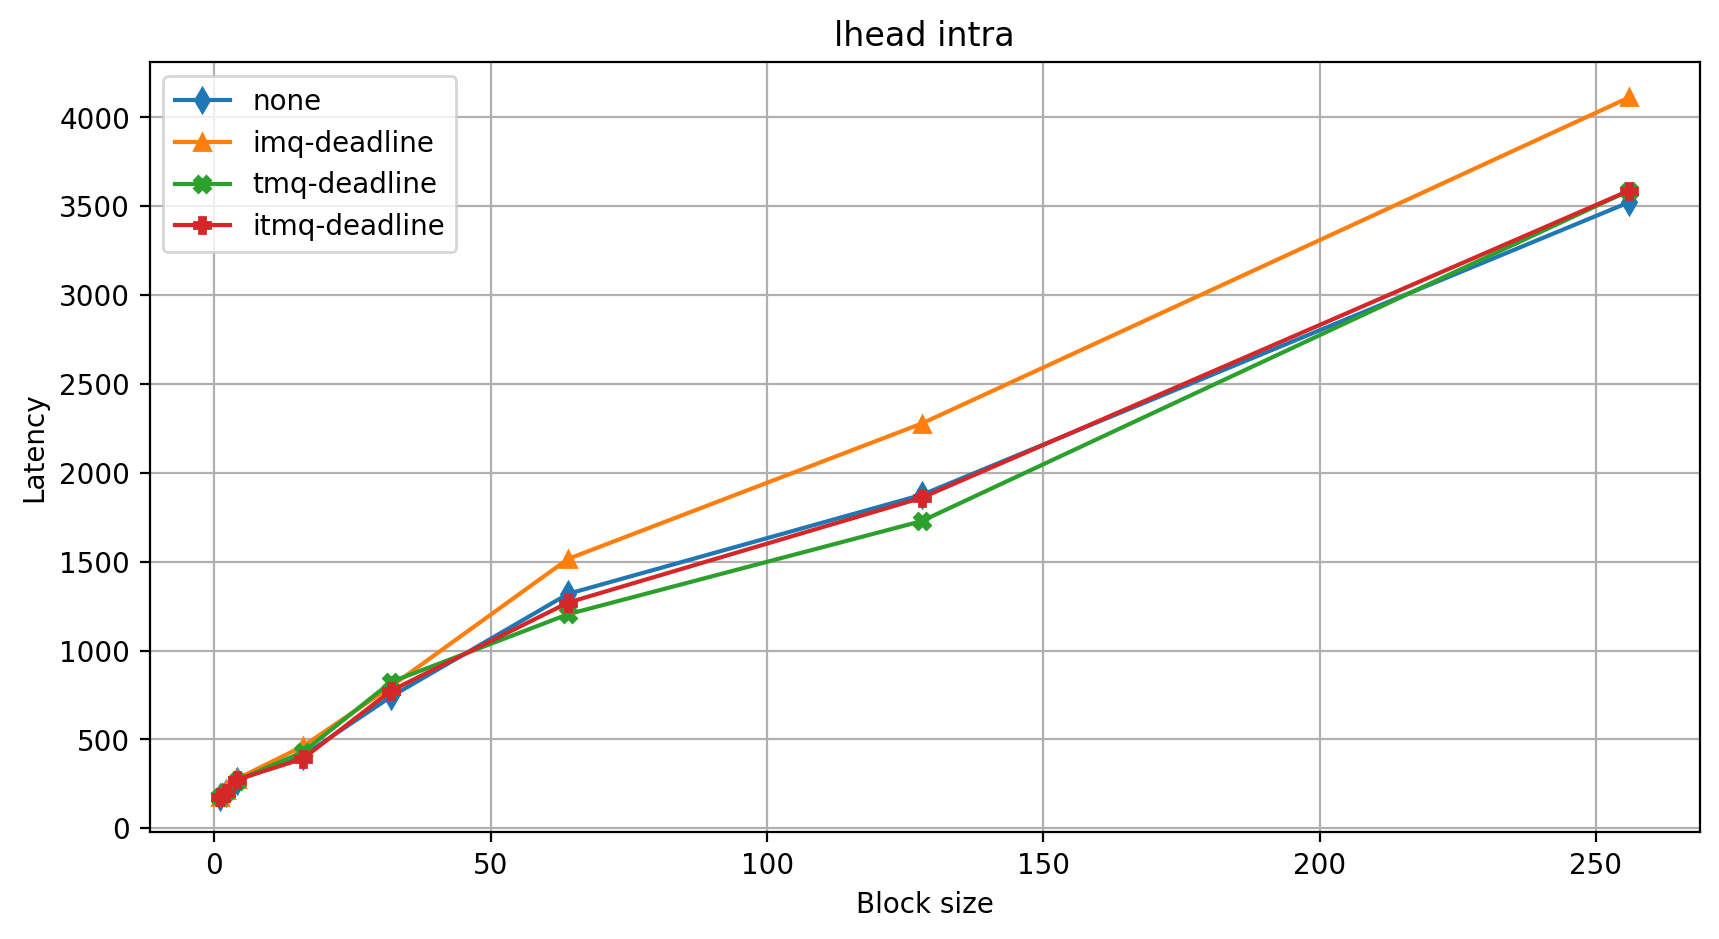

In [20]:
#Interference of the scheduler
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels = ["local","remote"]
for en, j in enumerate(["none","imq-deadline","tmq-deadline","itmq-deadline"]):
    experiments=[]
    for i in [1, 2, 4, 16, 32, 64, 128, 256]:
        experiments.append("remote_lhead_intra_{}_iou_RAM_randread_QD{}_P1_4k".format(j, i))
    plot_lat_line(experiments, 95,[1, 2, 4, 16, 32, 64, 128, 256],j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('lhead intra')
plt.xlabel("Block size")
plt.ylabel('Latency')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["remote_npoll_iou","local_poll_iou"]:
    experiments=[]
    for i in [1,2, 4, 8, 10]:
        experiments.append("{}_SSD_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, [1,2, 4, 8, 10], "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of process with QD128 and single connection (random read on NVMeoF-TCP)')
plt.xlabel("Number of process")
plt.ylabel('KIOPS')
plt.legend()

dev2 [124.510075314, 225.777037657, 405.464974895, 699.5056485360001, 803.1983556490001, 804.659920502, 828.432606695, 917.5430878660001, 918.465811715]
[5.364962673, 18.775262148000003, 11.428710766, 7.56313325, 4.712516186, 4.141080217, 5.902091989, 5.309991717, 9.204538291999999]
ns2 [134.969354167, 199.000323065, 377.606065464, 460.267586036, 460.562205021, 460.29701673600005, 460.423372385, 460.20746443499996, 460.379548117]
[2.856669409, 9.095840373000001, 3.646018366, 0.278797392, 0.215067426, 0.250545592, 0.21646535700000002, 0.237317659, 0.158446366]


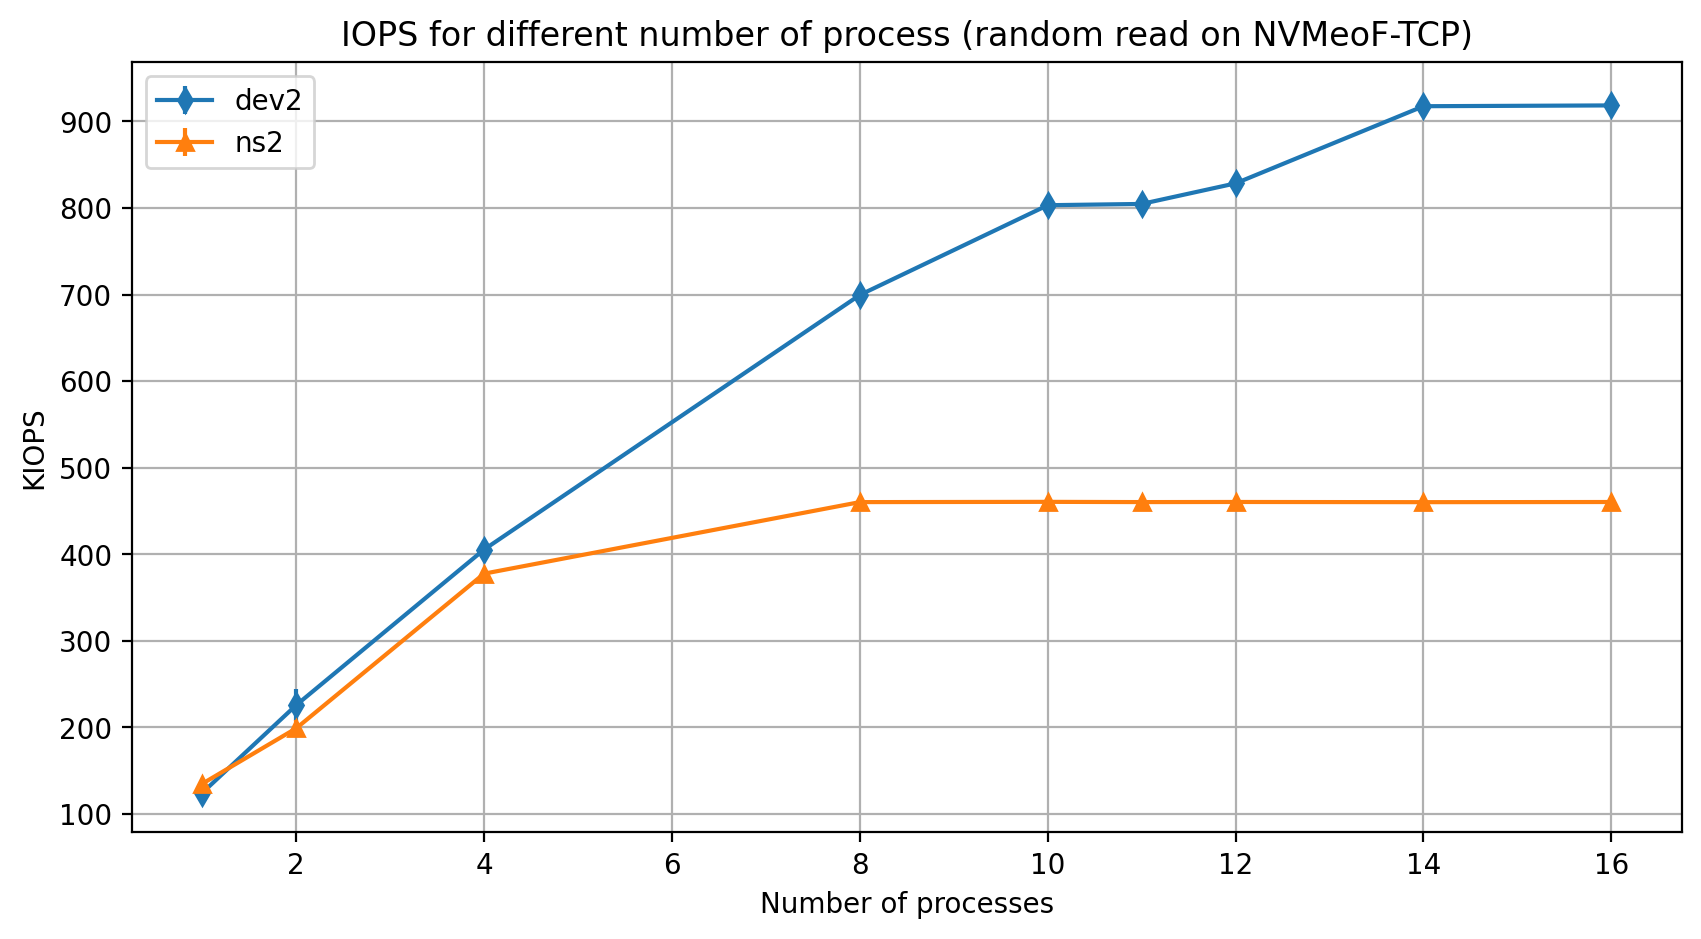

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["dev2","ns2"]: #,"npoll_ioup","poll_ioup"
    experiments=[]
    for i in [1,2, 4, 8, 10, 11, 12, 14, 16]:
        experiments.append("remote_poll_ioup_{}_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, [1,2, 4, 8, 10, 11, 12, 14, 16], "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of process (random read on NVMeoF-TCP)')
plt.xlabel("Number of processes")
plt.ylabel('KIOPS')
plt.legend()

1P [48.076302778, 82.00574722200001, 85.930619444, 85.123666667, 84.835638889, 86.36783286900001, 85.594338889, 84.60080779900001]
[2.8175374029999998, 8.722689544000001, 4.837102715, 5.490699032, 5.344169867, 5.150686444, 5.037892095999999, 5.460867105999999]
2P [92.108306407, 134.501007204, 119.318487465, 102.76207799400001, 155.34662395499998, 152.573988889, 173.709654596, 170.084604457]
[4.294782299, 6.75834859, 7.882070583, 5.213346994, 7.204053710999999, 6.4628772230000004, 6.540282197000001, 6.07449176]
4P [122.721548747, 130.154119777, 239.162222501, 237.21260167100002, 355.98173259099997, 322.706972145, 323.862292479, 316.71734309799996]
[3.756055908, 3.769477838, 6.132694385, 6.261299405, 7.646531191, 7.140532593, 8.158849285, 8.489580330999999]
8P [129.149058496, 253.643796657, 338.51770195, 443.811103064, 452.766559889, 449.847002786, 452.494657382, 453.089142061]
[1.574119824, 3.4507504279999996, 4.549109413999999, 3.927006579, 3.414341637, 4.124775327, 2.9346223989999998,

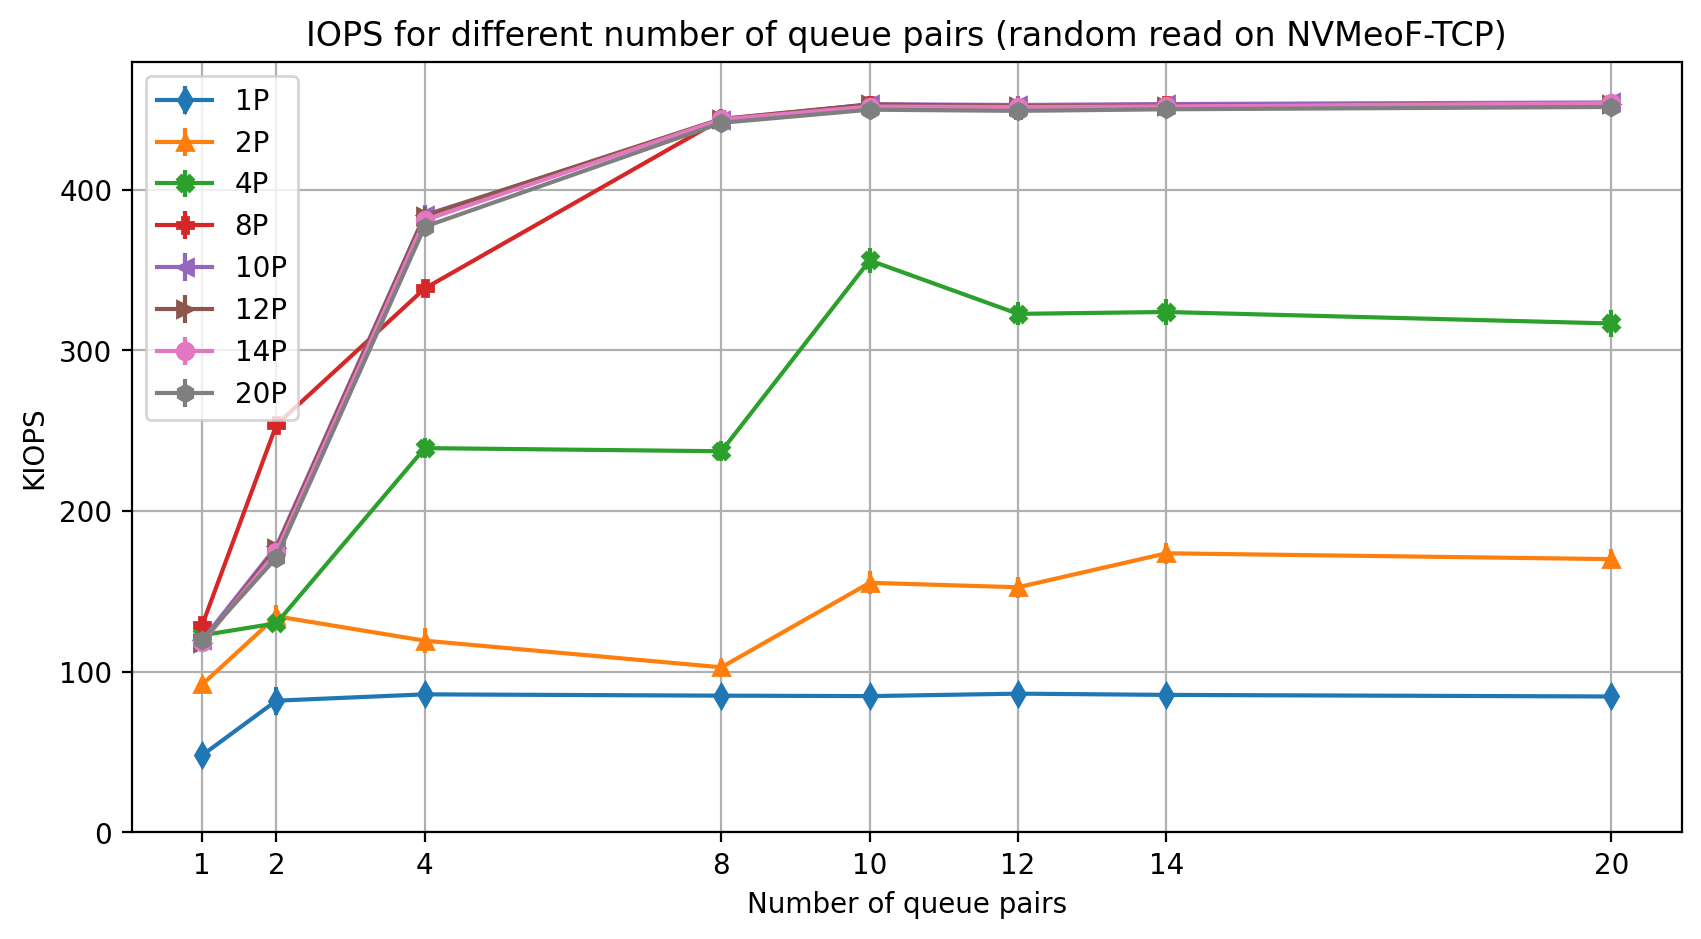

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in [1,2,4,8,10,12,14,20]: #,"npoll_ioup","poll_ioup"
    experiments=[]
    for i in ["1qp","2qp","4qp","8qp","10qp","12qp","14qp","20qp"]: #,
        experiments.append("remote_{}_npoll_ioup_SSD_randread_QD128_P{}_4k".format(i, j))
    plot_iops_line(experiments, [1,2,4,8,10,12,14,20], "{}P".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of queue pairs (random read on NVMeoF-TCP)')
plt.xlabel("Number of queue pairs")
plt.ylabel('KIOPS')
plt.xticks([1,2,4,8,10,12,14,20])
plt.ylim(bottom=0)
plt.legend()

95 [5275.648, 2834.432, 2342.912, 2408.448, 2408.448, 2342.912, 2375.68, 2408.448]
95 [5734.4, 2113.536, 3260.416, 8224.768, 2867.2, 2965.504, 2244.608, 2310.144]
95 [7503.872, 8290.304, 5603.328, 5341.184, 2310.144, 2605.056, 2801.664, 2801.664]
95 [19005.44, 10682.368, 7831.552, 5406.72, 3719.168, 4046.848, 3719.168, 3784.704]
95 [27394.048, 20316.16, 9502.72, 8159.232, 5799.936, 5341.184, 5341.184, 5144.576]
95 [32374.784, 23986.176, 11730.944, 10944.512, 7110.656, 7766.016, 7897.088, 6914.048]
95 [39059.456, 27656.192, 15269.888, 13959.168, 9764.864, 9240.576, 9764.864, 9502.72]
95 [55312.384, 41156.608, 20054.016, 15269.888, 12648.448, 12517.376, 11862.016, 12124.16]


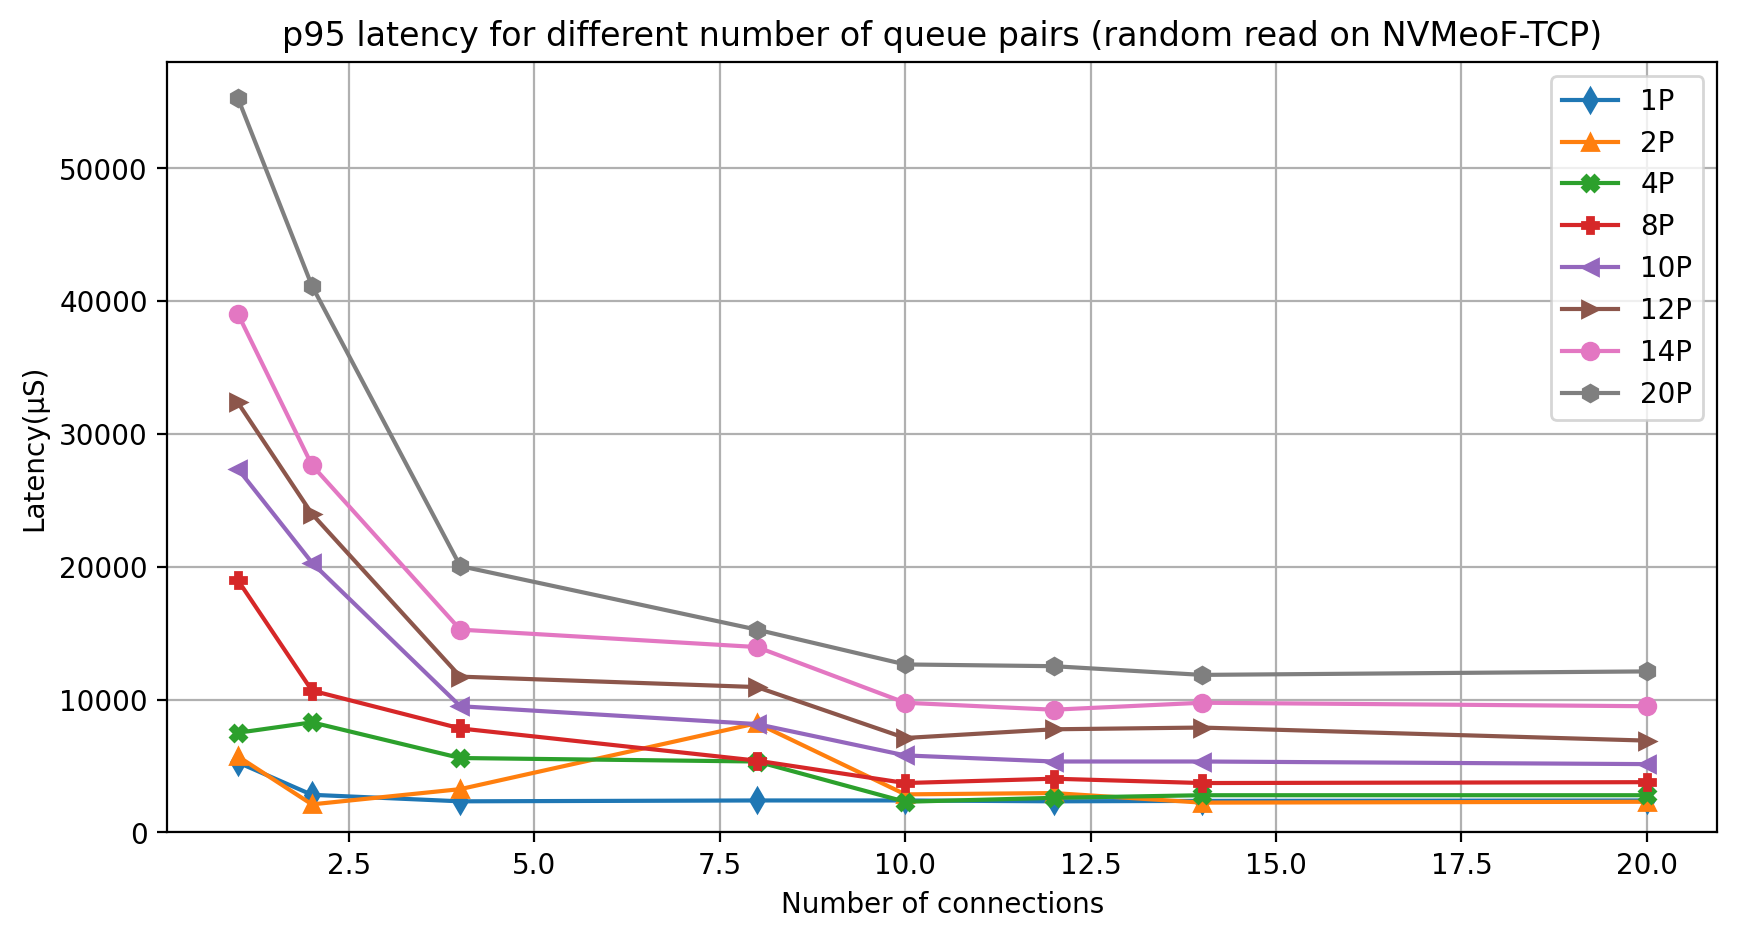

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in [1,2,4,8,10,12,14,20]: #,"npoll_ioup","poll_ioup"
    experiments=[]
    for i in ["1qp","2qp","4qp","8qp","10qp","12qp","14qp","20qp"]: #,
        experiments.append("remote_{}_npoll_ioup_SSD_randread_QD128_P{}_4k".format(i, j))
    plot_lat_line(experiments, 95,[1,2,4,8,10,12,14,20], "{}P".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p95 latency for different number of queue pairs (random read on NVMeoF-TCP)')
plt.xlabel("Number of connections")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
plt.ylim(bottom=0)
plt.legend()

95 [126.464, 132.096, 222.208, 224.256, 264.192, 272.384, 272.384, 276.48, 362.496, 354.304]
95 [116.224, 125.44, 209.92, 211.968, 257.024, 264.192, 268.288, 272.384, 370.688, 350.208]
95 [116.224, 126.464, 209.92, 211.968, 257.024, 305.152, 268.288, 264.192, 370.688, 346.112]


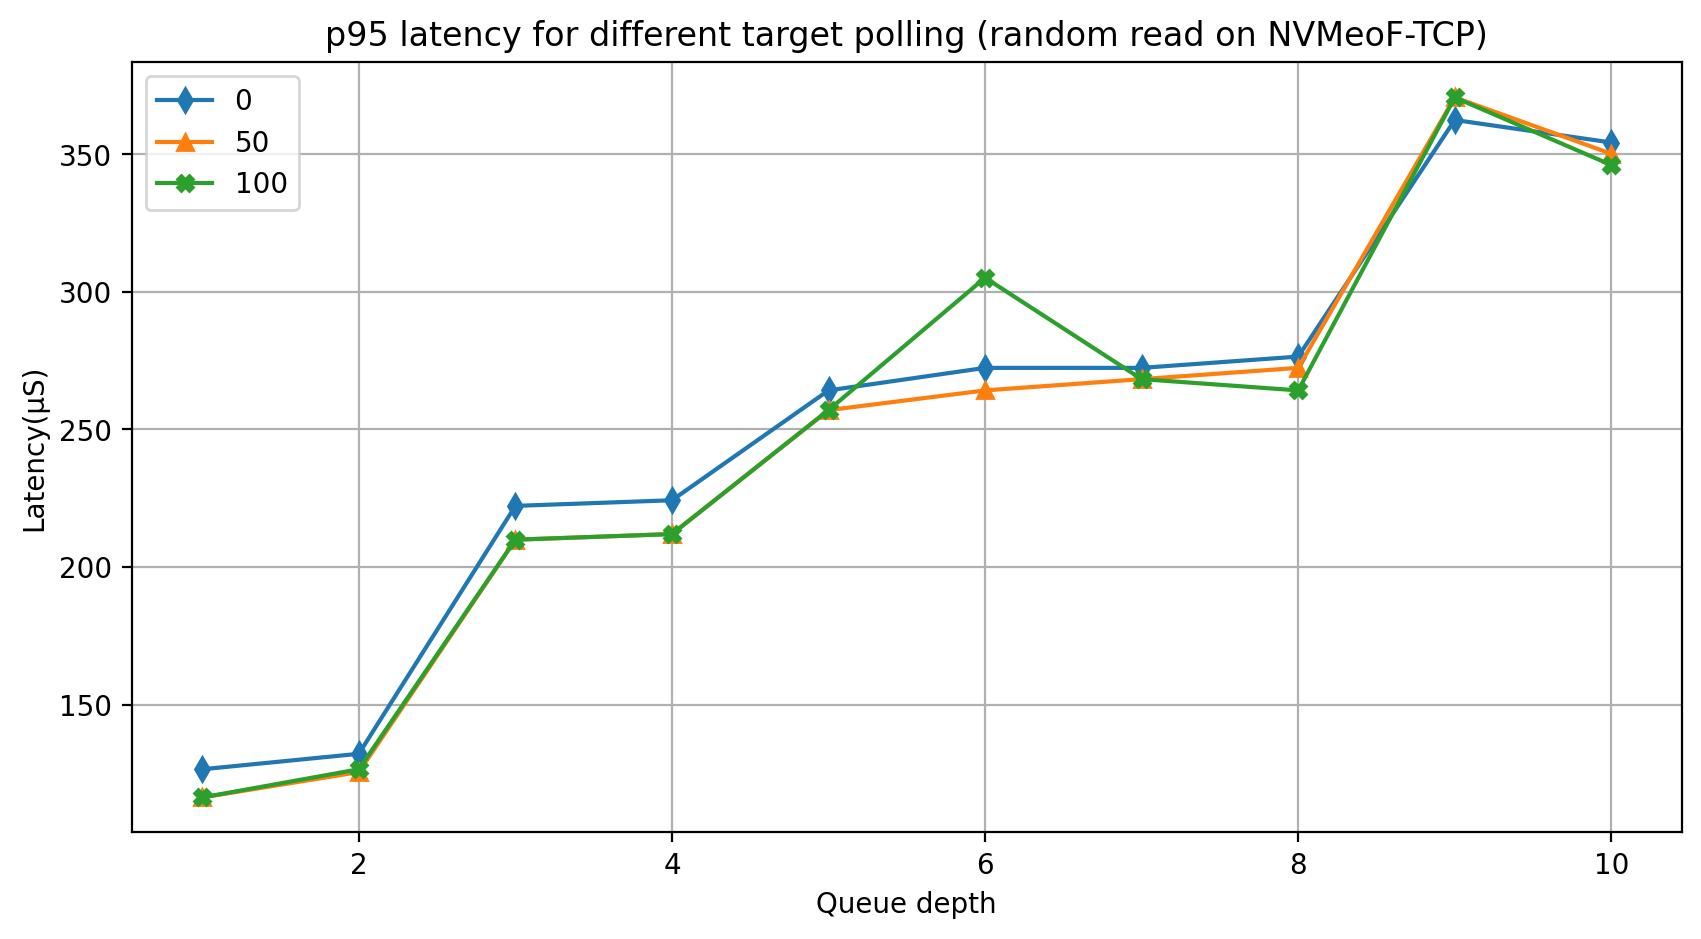

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in [0, 50, 100]:
    experiments=[]
    for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        experiments.append("remote_perf_tpoll{}_ioup_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_lat_line(experiments, 95, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p95 latency for different target polling (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
#plt.yticks([i for i in range(0,300,10)])
plt.legend()

{'QD1': [1859.584, 9.519238494], 'QD32': [53215.232, 12.531179969], 'QD64': [128450.56, 13.672521025], 'QD128': [189792.256, 13.255616667]}
{'QD1': [292.864, 40.888251552], 'QD32': [3063.808, 147.183270518], 'QD64': [7372.8, 252.305559257], 'QD128': [15400.96, 227.995100418]}
{'QD1': [199.68, 52.586108316], 'QD32': [1564.672, 334.512179916], 'QD64': [1941.504, 441.860154812], 'QD128': [5341.184, 407.384729672]}
{'QD1': [185.344, 57.21731583], 'QD32': [1003.52, 403.023735513], 'QD64': [2072.576, 457.318576308], 'QD128': [4947.968, 460.378527197]}
{'QD1': [138.24, 66.206117155], 'QD32': [1056.768, 457.971832636], 'QD64': [1777.664, 460.35509205], 'QD128': [3588.096, 460.411349756]}


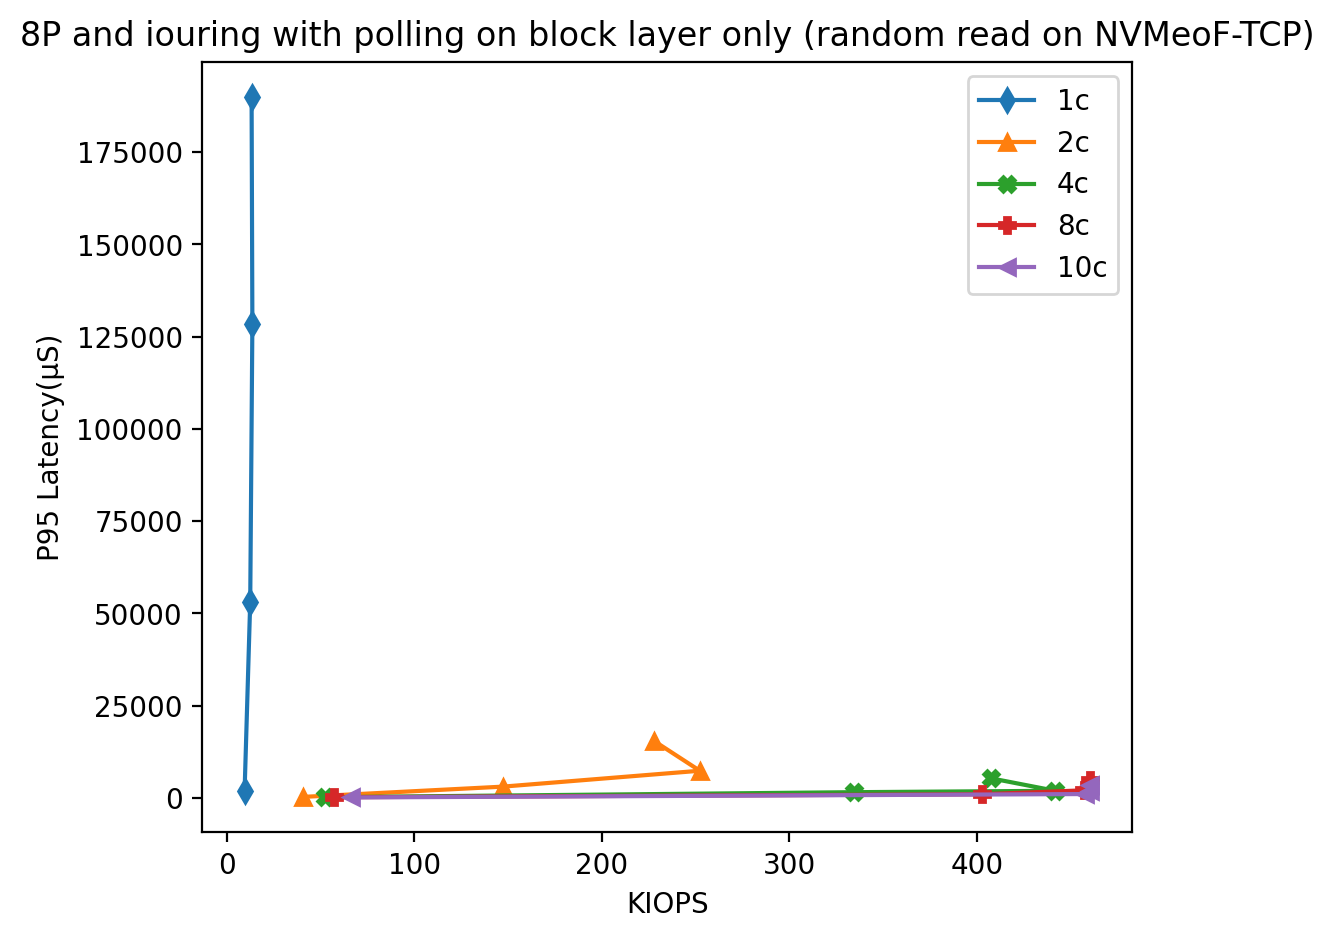

In [13]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in ["1c","2c","4c","8c","10c"]:
    names = []
    experiments = []
    for j in [1, 32, 64, 128]:
        experiments.append("remote_{}_poll_ioup_SSD_randread_QD{}_P8_4k".format(i, j))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("8P and iouring with polling on block layer only (random read on NVMeoF-TCP)")
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in ["4k","8k","16k","32k","64k","128k"]:
    names = []
    experiments = []
    for j in [1, 32, 64, 128]:
        experiments.append("remote_npoll_iou_SSD_randread_QD{}_P1_{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("Saturation point for random read on NVMeoF-TCP with different block sizes")
plt.legend()

remote_score_npoll_iou_SSD_randread_QD1_P1_4k {'all': {'usr': '0.19', 'sys': '1.04', 'io': '4.88'}, '0': {'usr': '2.07', 'sys': '16.09', 'io': '81.58'}, '1': {'usr': '0.07', 'sys': '0.04', 'io': '0.00'}, '2': {'usr': '0.10', 'sys': '0.30', 'io': '0.00'}, '3': {'usr': '0.04', 'sys': '0.02', 'io': '0.00'}, '4': {'usr': '0.10', 'sys': '0.03', 'io': '0.00'}, '5': {'usr': '0.15', 'sys': '0.27', 'io': '0.00'}, '6': {'usr': '0.15', 'sys': '0.24', 'io': '0.01'}, '7': {'usr': '0.13', 'sys': '0.05', 'io': '0.03'}, '8': {'usr': '0.05', 'sys': '0.20', 'io': '0.00'}, '9': {'usr': '0.03', 'sys': '0.03', 'io': '0.01'}, '10': {'usr': '0.01', 'sys': '0.01', 'io': '0.01'}, '11': {'usr': '0.01', 'sys': '0.03', 'io': '0.01'}, '12': {'usr': '0.06', 'sys': '0.03', 'io': '0.03'}, '13': {'usr': '0.03', 'sys': '0.02', 'io': '0.00'}, '14': {'usr': '0.08', 'sys': '0.03', 'io': '0.01'}, '15': {'usr': '0.01', 'sys': '0.06', 'io': '0.26'}}
CPU util :  18.159999999999997
remote_score_npoll_iou_SSD_randread_QD1_P32_4

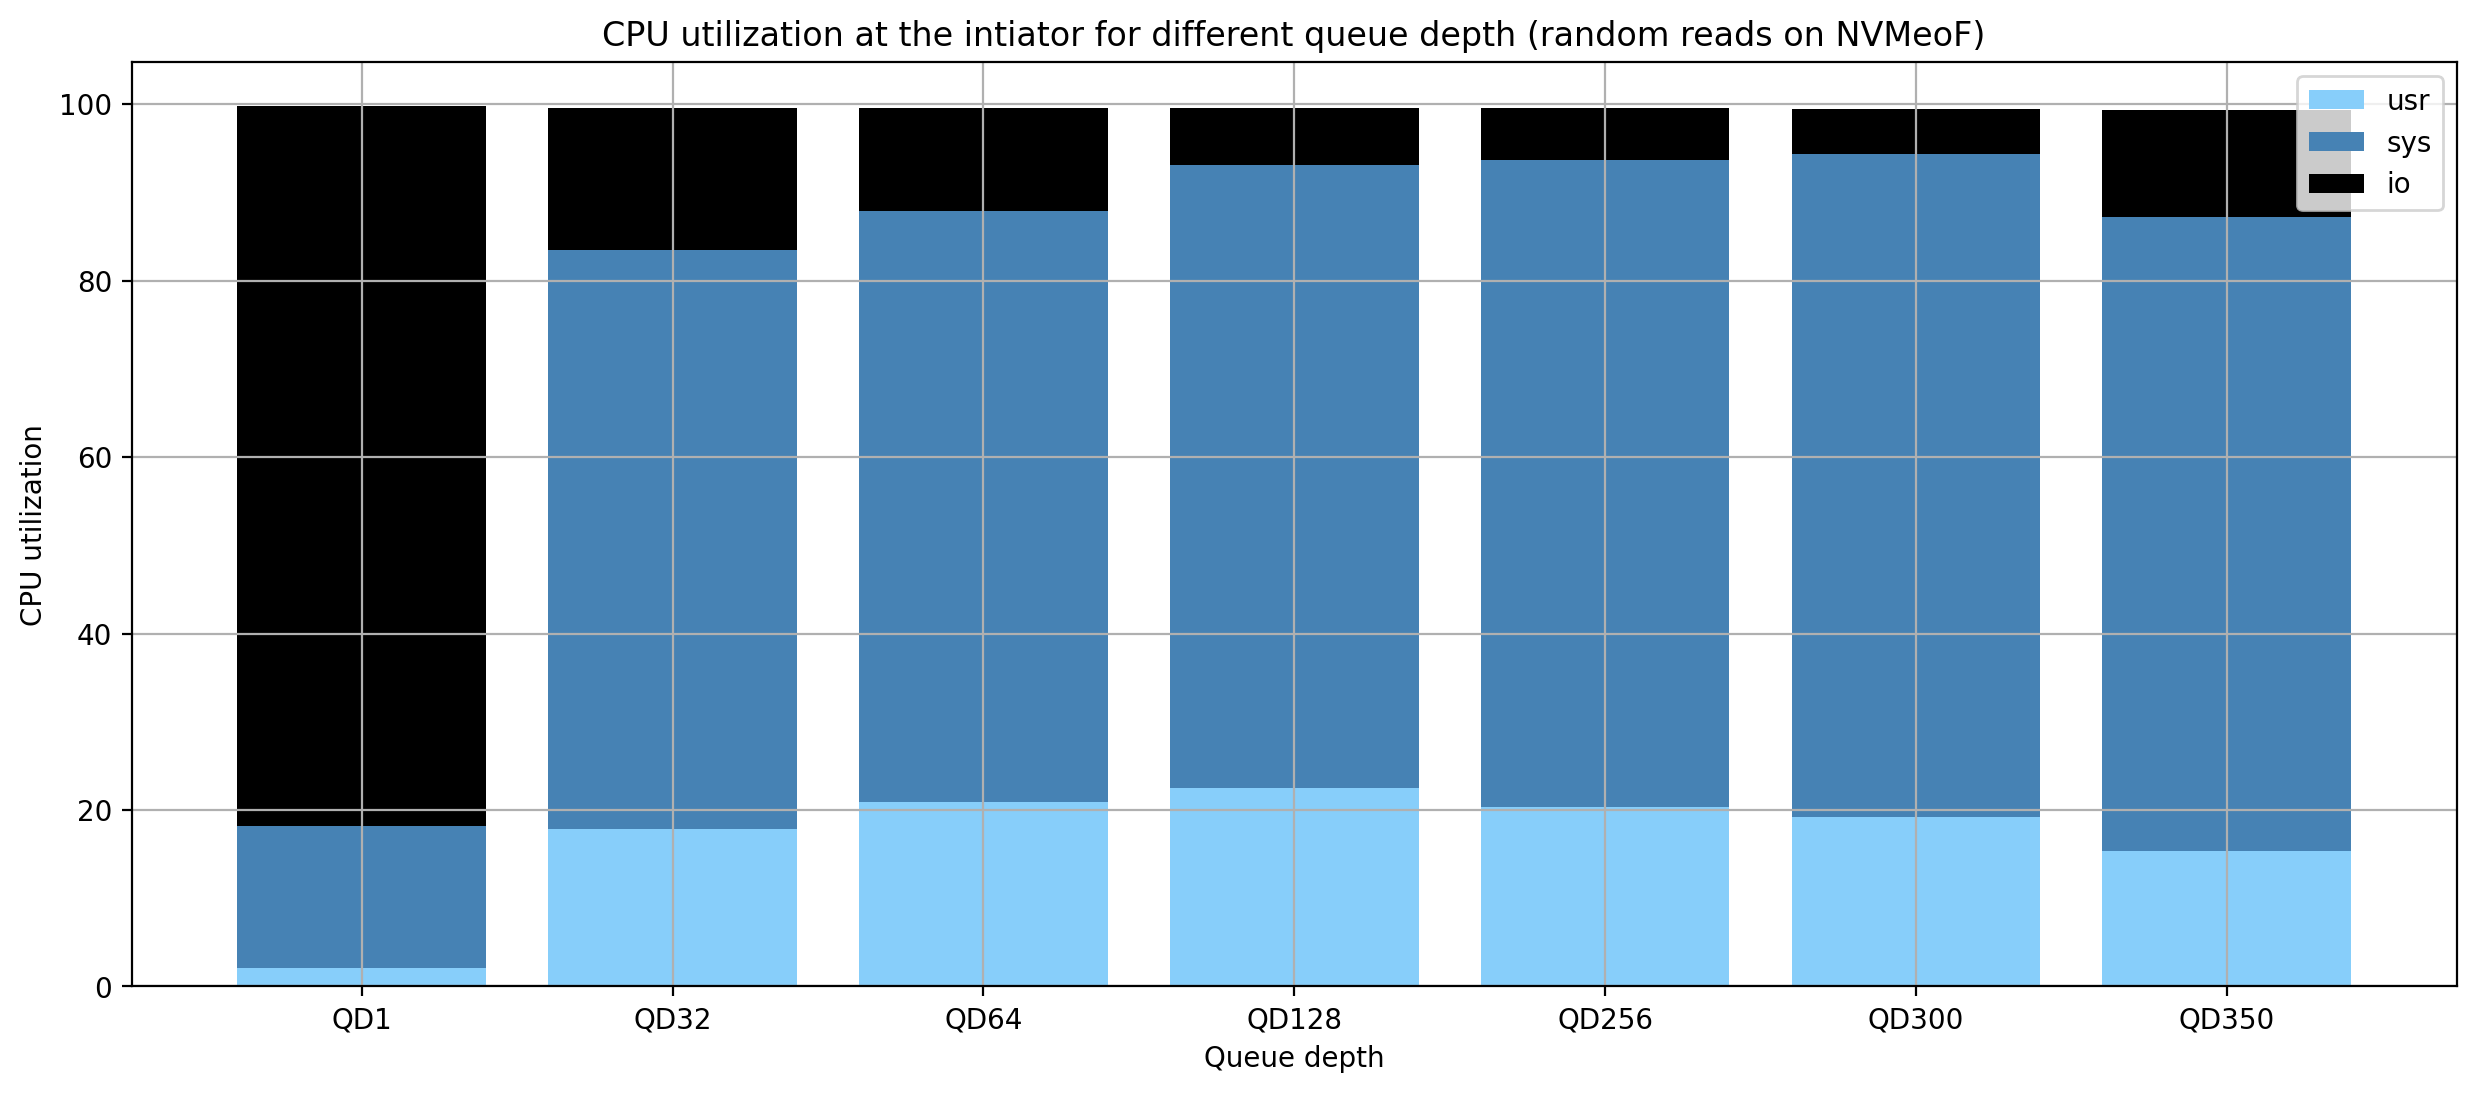

In [62]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in [1, 32, 64, 128, 256, 300, 350]:
    cpu_init_utilization("remote_score_npoll_iou_SSD_randread_QD1_P{}_4k".format(i),"QD{}".format(i),0)
plt.title('CPU utilization at the intiator for different queue depth (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

remote_npoll_iou_SSD_randread_QD1_P1_4k {'all': {'usr': '0.00', 'sys': '0.62', 'io': '0.00'}, '0': {'usr': '0.00', 'sys': '0.02', 'io': '0.01'}, '1': {'usr': '0.00', 'sys': '0.03', 'io': '0.01'}, '2': {'usr': '0.01', 'sys': '0.01', 'io': '0.00'}, '3': {'usr': '0.00', 'sys': '0.01', 'io': '0.01'}, '4': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '6': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '7': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '8': {'usr': '0.00', 'sys': '0.04', 'io': '0.01'}, '9': {'usr': '0.00', 'sys': '6.75', 'io': '0.00'}}
remote_npoll_iou_SSD_randread_QD32_P1_4k {'all': {'usr': '0.00', 'sys': '4.16', 'io': '0.00'}, '0': {'usr': '0.01', 'sys': '0.02', 'io': '0.00'}, '1': {'usr': '0.00', 'sys': '0.04', 'io': '0.00'}, '2': {'usr': '0.00', 'sys': '0.01', 'io': '0.01'}, '3': {'usr': '0.01', 'sys': '0.01', 'io': '0.00'}, '4': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '0.02', 'io': '0.0

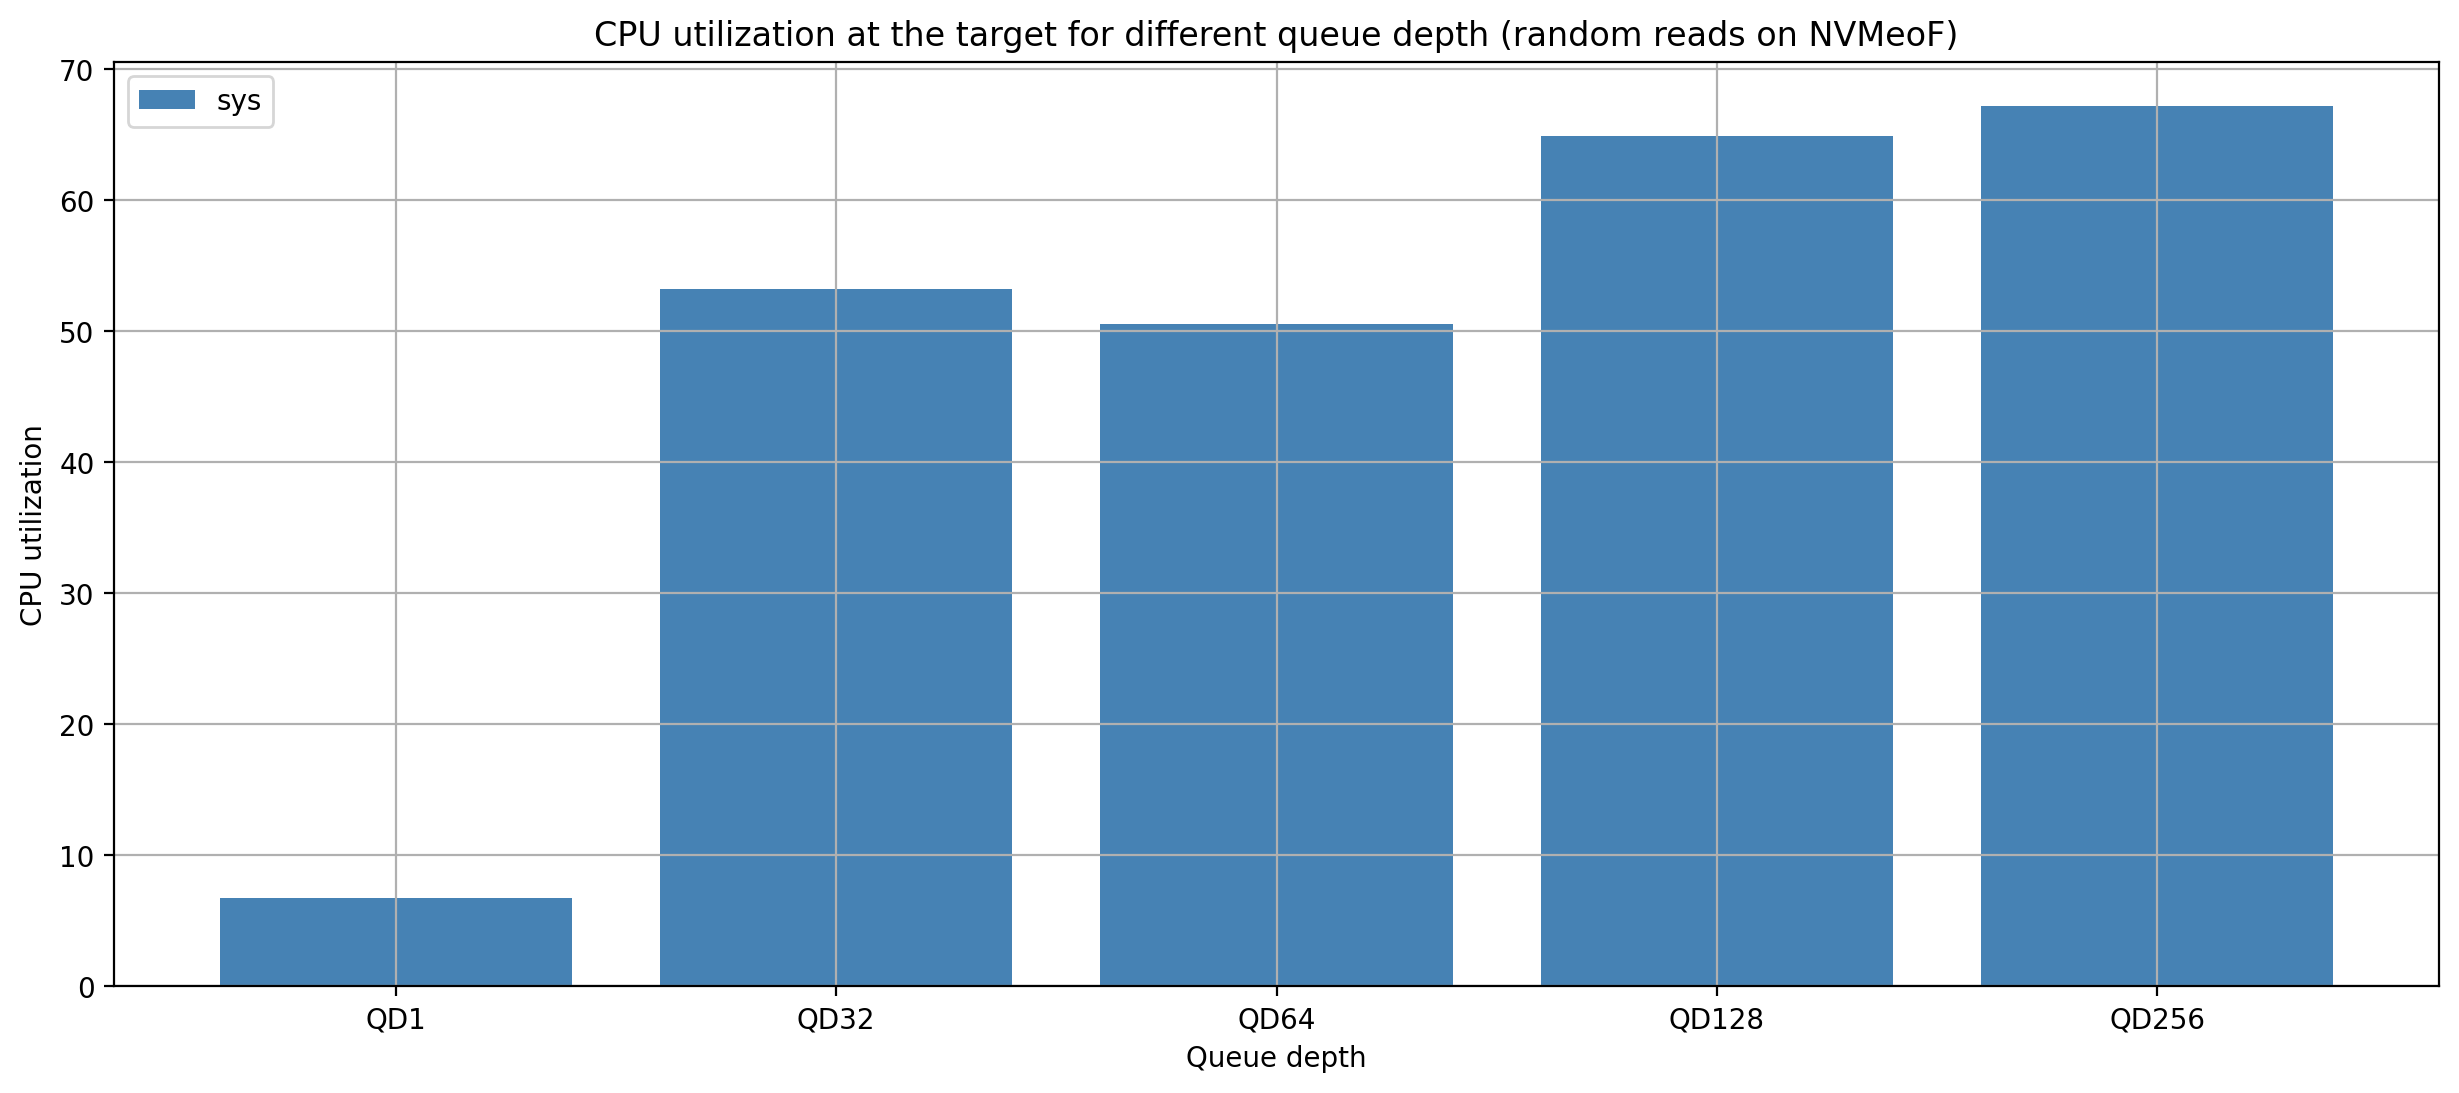

In [61]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in [1, 32, 64, 128, 256]:
    cpu_target_utilization("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at the target for different queue depth (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

local_poll_iou_SSD_randread_QD1_P1_4k {'all': {'usr': '0.10', 'sys': '0.24', 'io': '5.57'}, '0': {'usr': '1.61', 'sys': '3.97', 'io': '94.37'}, '1': {'usr': '0.00', 'sys': '0.01', 'io': '0.01'}, '2': {'usr': '0.00', 'sys': '0.02', 'io': '0.01'}, '3': {'usr': '0.01', 'sys': '0.02', 'io': '0.01'}, '4': {'usr': '0.01', 'sys': '0.01', 'io': '0.01'}, '5': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '6': {'usr': '0.01', 'sys': '0.02', 'io': '0.00'}, '7': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '8': {'usr': '0.01', 'sys': '0.03', 'io': '0.01'}, '9': {'usr': '0.01', 'sys': '0.01', 'io': '0.00'}, '10': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '11': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '12': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '13': {'usr': '0.02', 'sys': '0.01', 'io': '0.00'}, '14': {'usr': '0.01', 'sys': '0.02', 'io': '0.02'}, '15': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}}
local_poll_iou_SSD_randread_QD32_P1_4k {'all': {'usr': '1.64', 'sys': '3.28', 'io': '

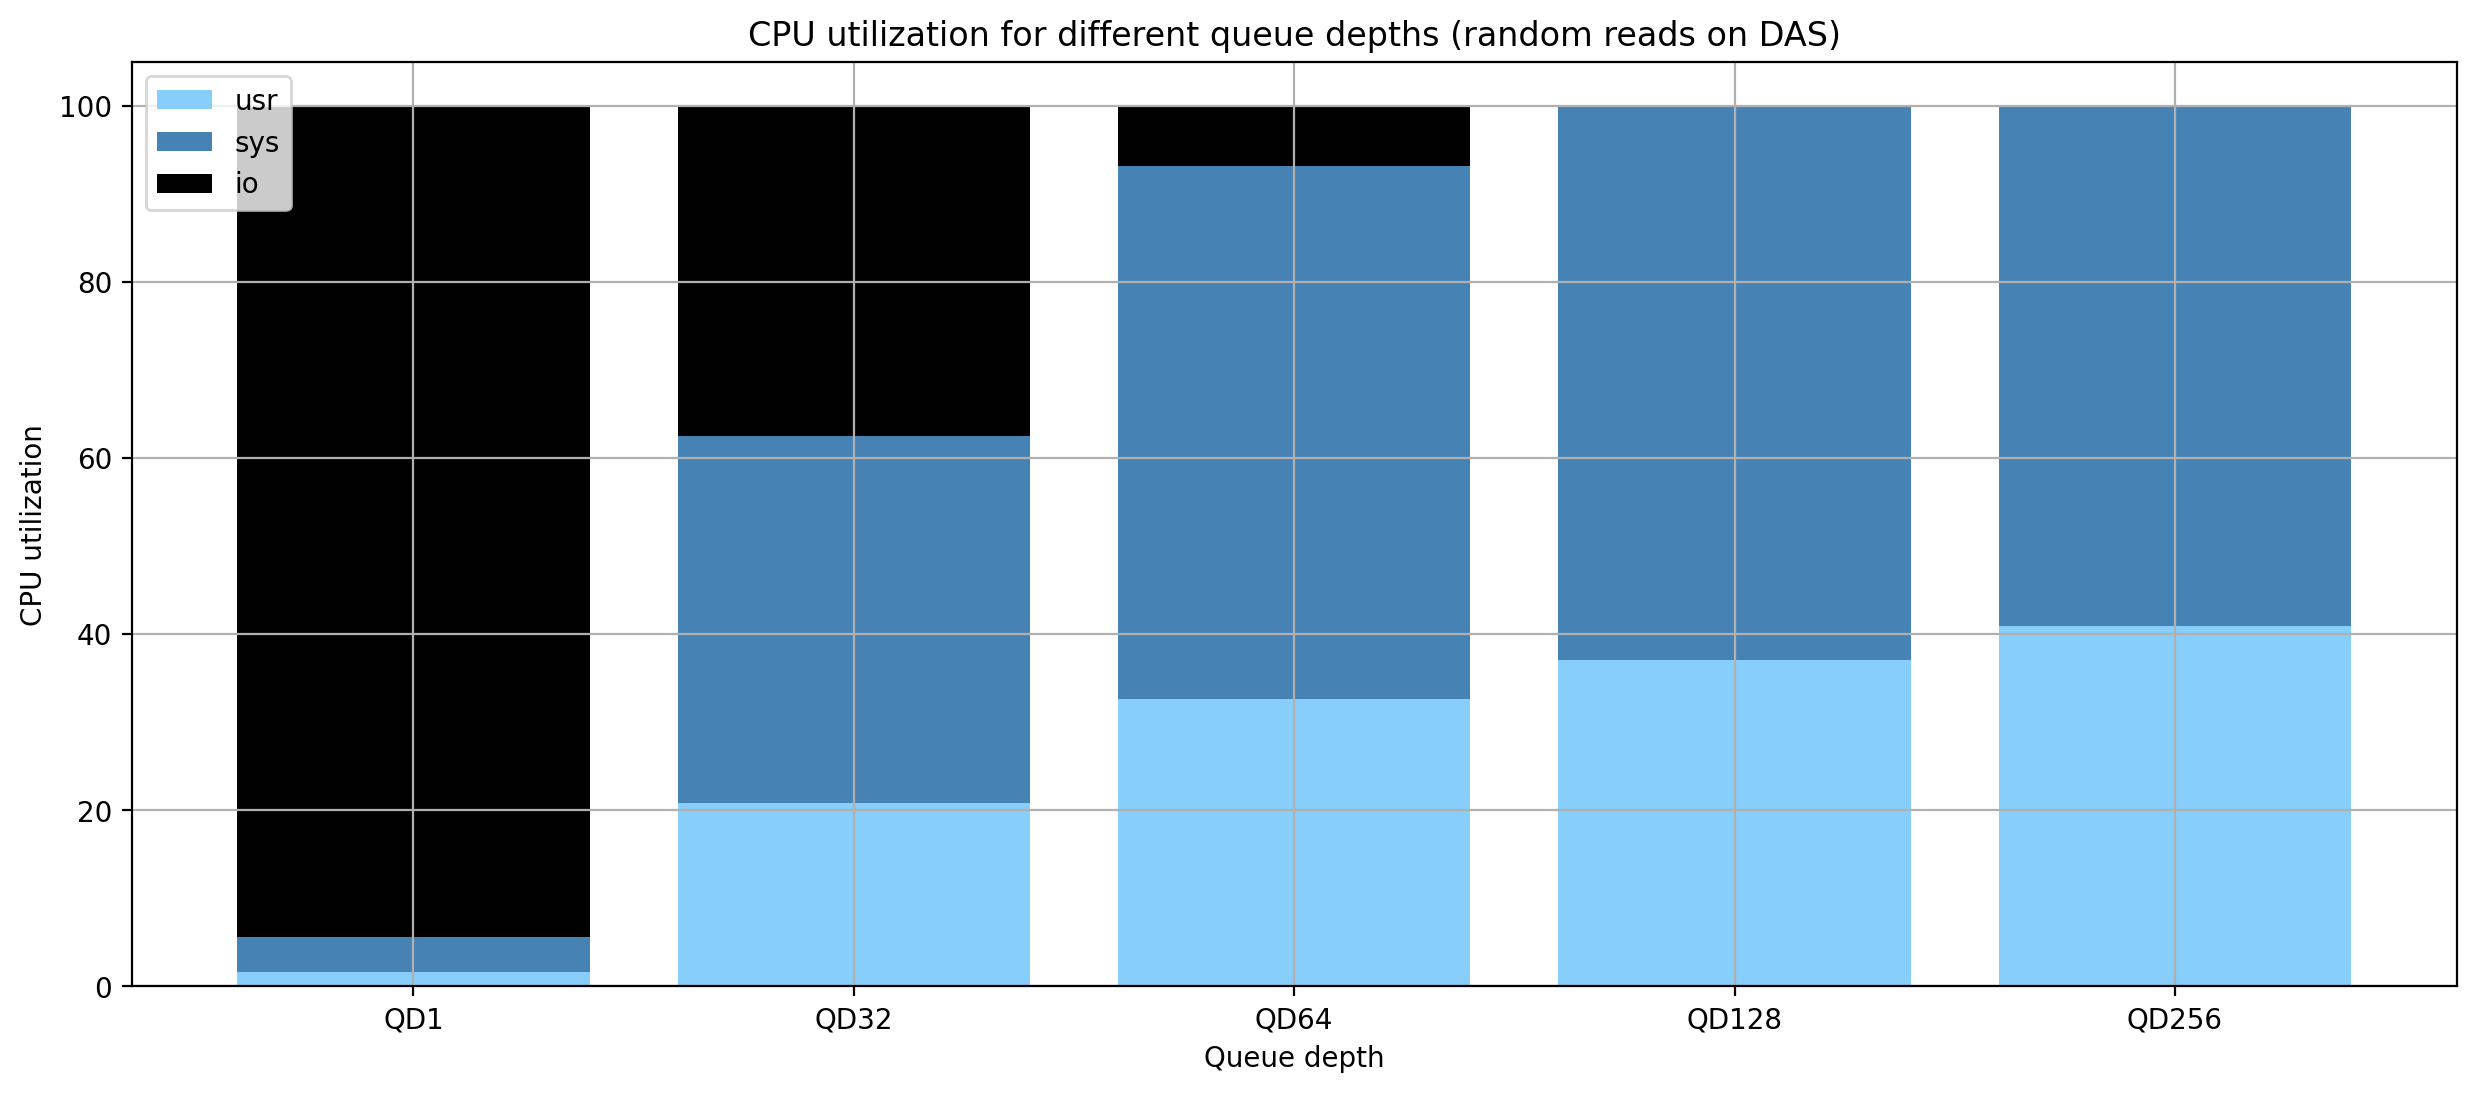

In [62]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in [1, 32, 64, 128, 256]:
    cpu_local_utilization("local_poll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i),0)
plt.title('CPU utilization for different queue depths (random reads on DAS)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in [1, 2, 4, 8, 10]:
    cpu_target_utilization("remote_sc_ioup_SSD_randread_QD128_P{}_4k".format(i),"P{}".format(i))
plt.title('CPU utilization at target for different queue depths with iou (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["poll_iou","poll_ioup"]:
    experiments=[]
    for i in QD:
        experiments.append("local_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_iops_line(experiments, QD, "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different queue depth in single core (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

iou [14.056379167, 22.142487499999998, 32.1977, 33.000608332999995, 40.8579375, 44.305495833, 46.987879167, 49.818112500000005, 60.849541667, 62.713550000000005, 64.638520833, 66.20368333299999, 69.324170833, 70.856779167, 71.252058333, 71.773854167, 69.97131666700001, 68.54346249999999, 71.818183333, 72.453341667, 76.011616667, 72.0067, 69.28557083300001, 68.252451883, 72.955041667, 67.45532636, 70.634541667, 71.85460416699999, 70.66535146400001, 69.0456875, 71.568661088, 74.290570833, 98.268429167, 98.323104603, 99.328341667, 97.938811715, 97.384598326, 96.7891841, 94.374379167, 93.06632499999999, 95.53542677799999, 96.020665272, 101.08086192500001, 100.507627615, 98.4618159, 98.232041667, 97.013495833, 99.760087866, 100.647666667, 99.802661088, 100.808690377, 99.619770833, 100.53960669499999, 101.842066946, 103.541778243, 101.58399583299999, 103.202595833, 101.300866109, 101.842912134, 104.415962343, 102.316368201, 103.505975, 101.086217573]


Text(0, 0.5, 'KIOPS')

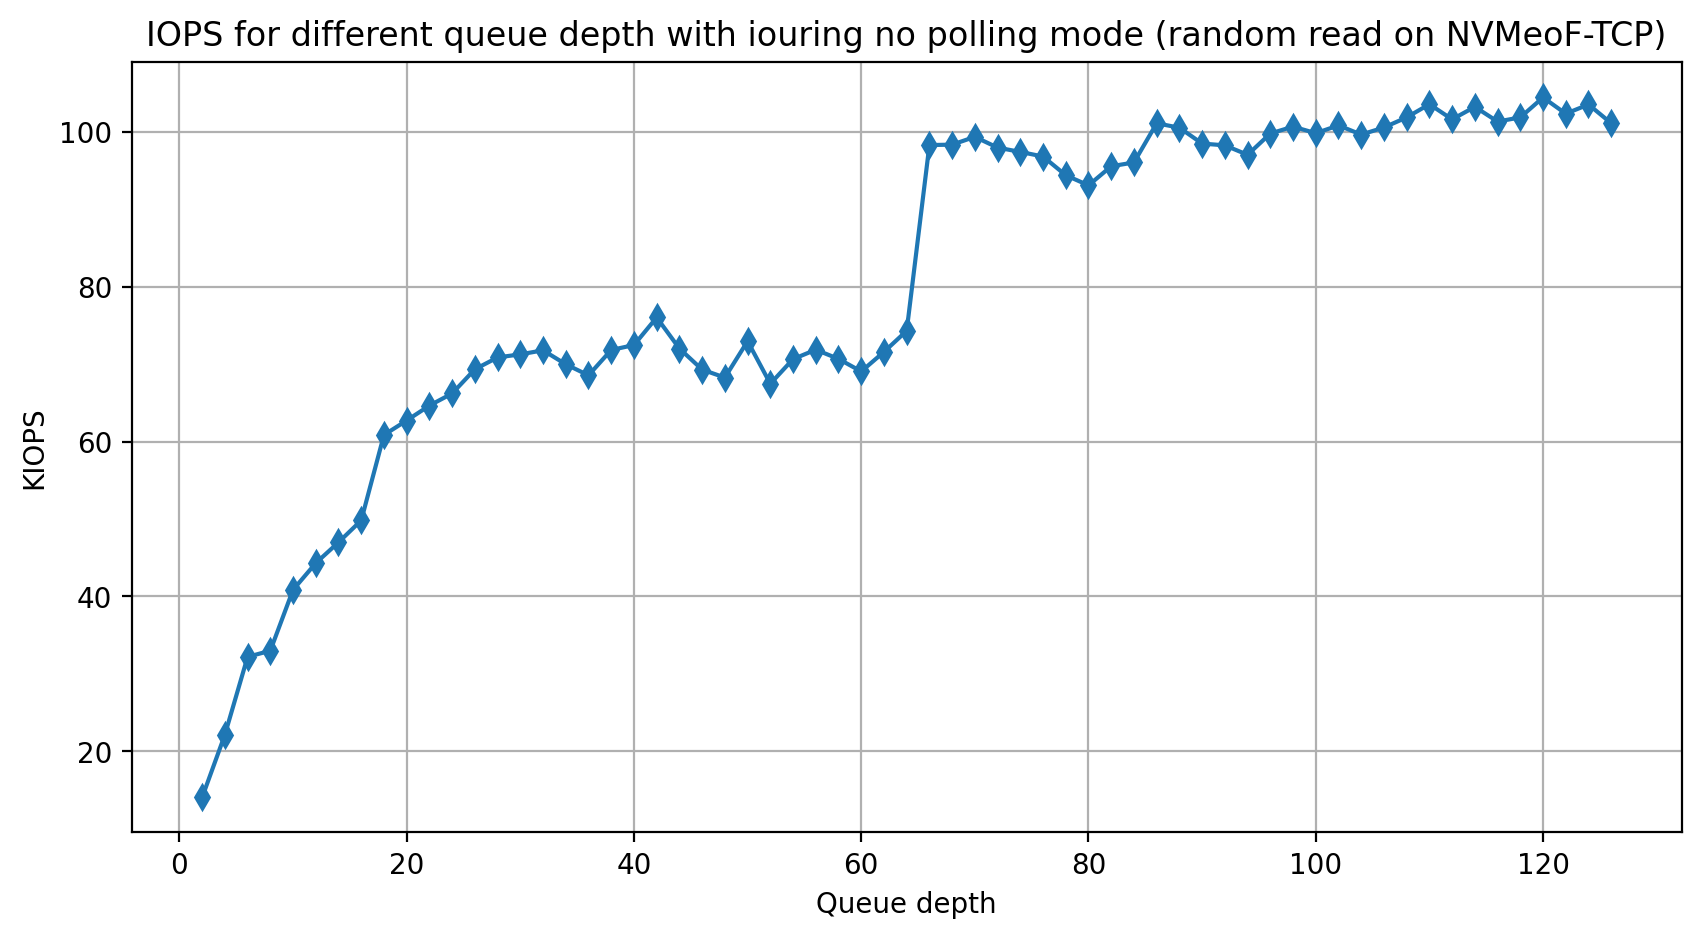

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou"]:
    experiments=[]
    for i in range(2,128,2):
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_iops_line(experiments, [i for i in range(2,128,2)], "{}".format(j).split("_")[1])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different queue depth with iouring no polling mode (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
#plt.xticks([i for i in range(50,71)])
#plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

#IOPS
BAR_COLOR="springgreen"
for i in QD:
    plot_iops_bar("local_SSD_randread_QD{}_P1".format(i),"QD{}".format(i))
plt.xlabel("Queue depth")

#Latency
ax2 = ax.twinx()
for i in [50.0, 95.0, 99.99,"max"]:
    names = []
    experiments = []
    for j in QD:
        experiments.append("local_SSD_randread_QD{}_P1".format(j))
        names.append("QD{}".format(j))
    plot_lat_line(experiments, i, names)
    
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')

plt.title("IOPS and latency vs queue depth 1P (random reads on local)")
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("local_SSD_randread_QD{}_P{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,50.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="P{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P50 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency (random read on local)")
plt.legend()

{'QD1': [2605.056, 5.8305815899999995], 'QD2': [5013.504, 6.294707113], 'QD4': [12255.232, 5.321359833000001], 'QD8': [22413.312, 5.1047907949999995], 'QD16': [43778.048, 4.995359833], 'QD32': [98041.856, 4.9462133889999995], 'QD64': [200278.016, 4.971464435], 'QD128': [429916.16, 4.977341841], 'QD256': [843055.104, 5.024858647], 'QD512': [1652555.776, 7.038150388]}
{'QD1': [3522.56, 6.4483974900000005], 'QD2': [8028.16, 5.5095857740000005], 'QD4': [17956.864, 4.929560669000001], 'QD8': [33423.36, 4.807246862], 'QD16': [64749.568, 4.749066946], 'QD32': [145752.064, 4.760372384999999], 'QD64': [287309.824, 4.782112970999999], 'QD128': [616562.688, 4.78985781], 'QD256': [1249902.592, 5.012615642], 'QD512': [2399141.888, 8.134536387]}
{'QD1': [3915.776, 6.471259414], 'QD2': [9764.864, 5.263794979], 'QD4': [21102.592, 4.7928235290000005], 'QD8': [39059.456, 4.740860168999999], 'QD16': [76021.76, 4.700188034], 'QD32': [168820.736, 4.70716601], 'QD64': [333447.168, 4.729415529], 'QD128': [70

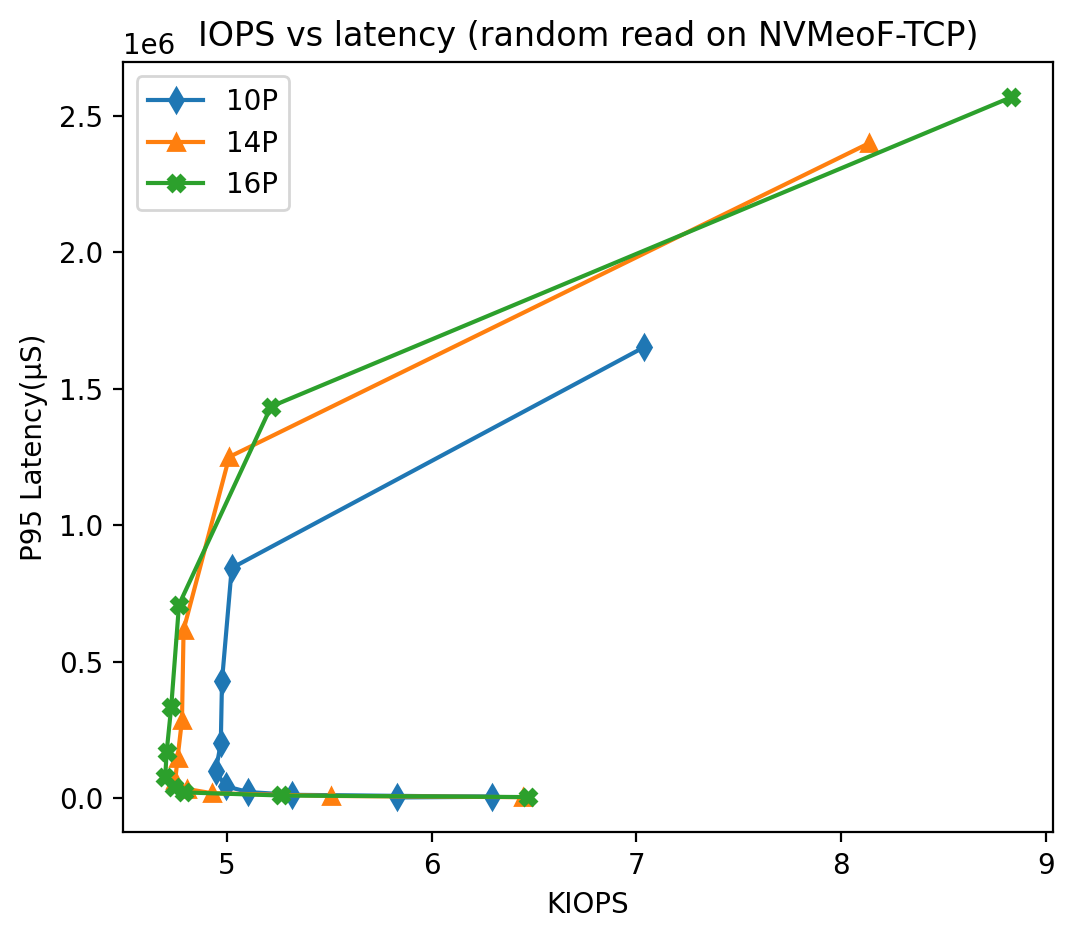

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in [10, 14, 16]:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_npoll_iou_4DEV_randread_QD{}_P{}_1024k".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}P".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency (random read on NVMeoF-TCP)")
plt.legend()

{'P1': [171.008, 6.379678333], 'P2': [197.632, 12.213741461], 'P4': [264.192, 20.197764608], 'P8': [354.304, 31.835846411], 'P16': [577.536, 42.053135225], 'P32': [1011.712, 49.682560935], 'P64': [1859.584, 53.452540631000005], 'P128': [3194.88, 59.728584457], 'P256': [10027.008, 39.379336903], 'P300': [12910.592, 35.923814338], 'P350': [16449.536, 33.978010440999995]}


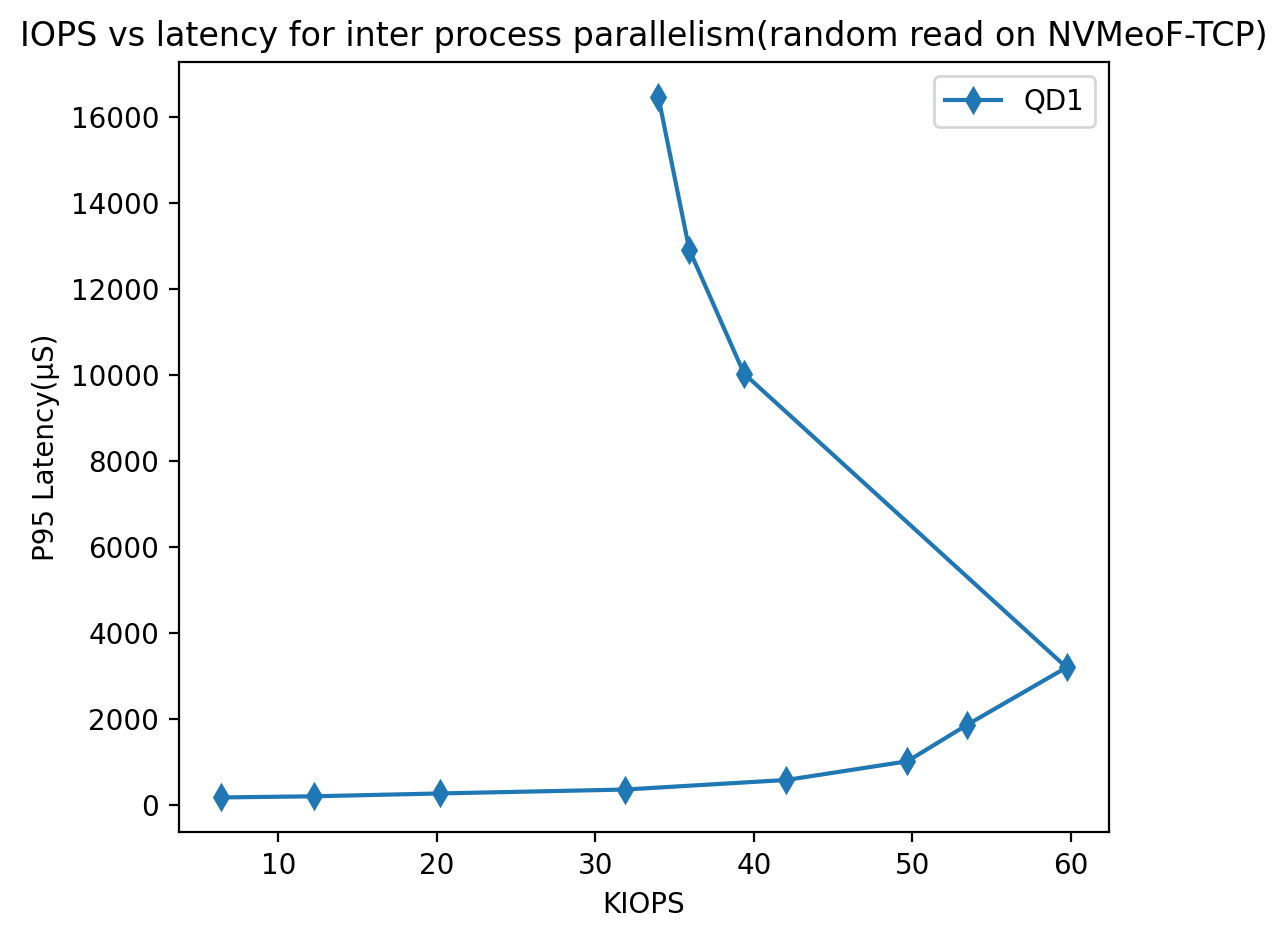

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
names = []
experiments = []
for i in [1, 2, 4, 8]:
    for j in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
        experiments.append("remote_perf_npoll_iou_SSD_randread_QD{}_P{}_4k".format(j))
        names.append("P{}".format(j))
d = plot_lat_iops(experiments,95.0,names)
lat = []
iops = []
for k in d.keys():
    lat.append(d[k][0])
    iops.append(d[k][1])
    scatter_label[(d[k][1], d[k][0])] = k
mark = MARKERS[CALLS]
CALLS = (CALLS + 1)%len(MARKERS)
plt.plot(iops, lat, '-'+mark, label="QD1")
print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for inter process parallelism(random read on NVMeoF-TCP)")
plt.legend()

{'QD1': [82.432, 13.2819], 'QD2': [83.456, 26.015616667], 'QD4': [94.72, 51.0345375], 'QD8': [119.296, 96.126479167], 'QD16': [144.384, 170.719358333], 'QD32': [207.872, 269.27245], 'QD64': [272.384, 318.345704167], 'QD128': [403.456, 326.374679167], 'QD256': [815.104, 320.70903333300004], 'QD512': [1613.824, 320.20092916699997]}
{'QD1': [83.456, 26.211083332999998], 'QD2': [93.696, 51.098483333], 'QD4': [119.296, 96.598545833], 'QD8': [144.384, 172.316520833], 'QD16': [209.92, 275.409479167], 'QD32': [362.496, 374.8615125], 'QD64': [708.608, 442.64309166699996], 'QD128': [1138.688, 458.957366667], 'QD256': [1712.128, 458.2875125], 'QD512': [2834.432, 458.390829167]}
{'QD1': [94.72, 50.994025105], 'QD2': [119.296, 96.56319166700001], 'QD4': [144.384, 172.543245833], 'QD8': [209.92, 276.33022916699997], 'QD16': [362.496, 376.15015062799995], 'QD32': [708.608, 444.423753138], 'QD64': [1138.688, 460.386209205], 'QD128': [1695.744, 460.22673640200003], 'QD256': [2801.664, 460.315683333], '

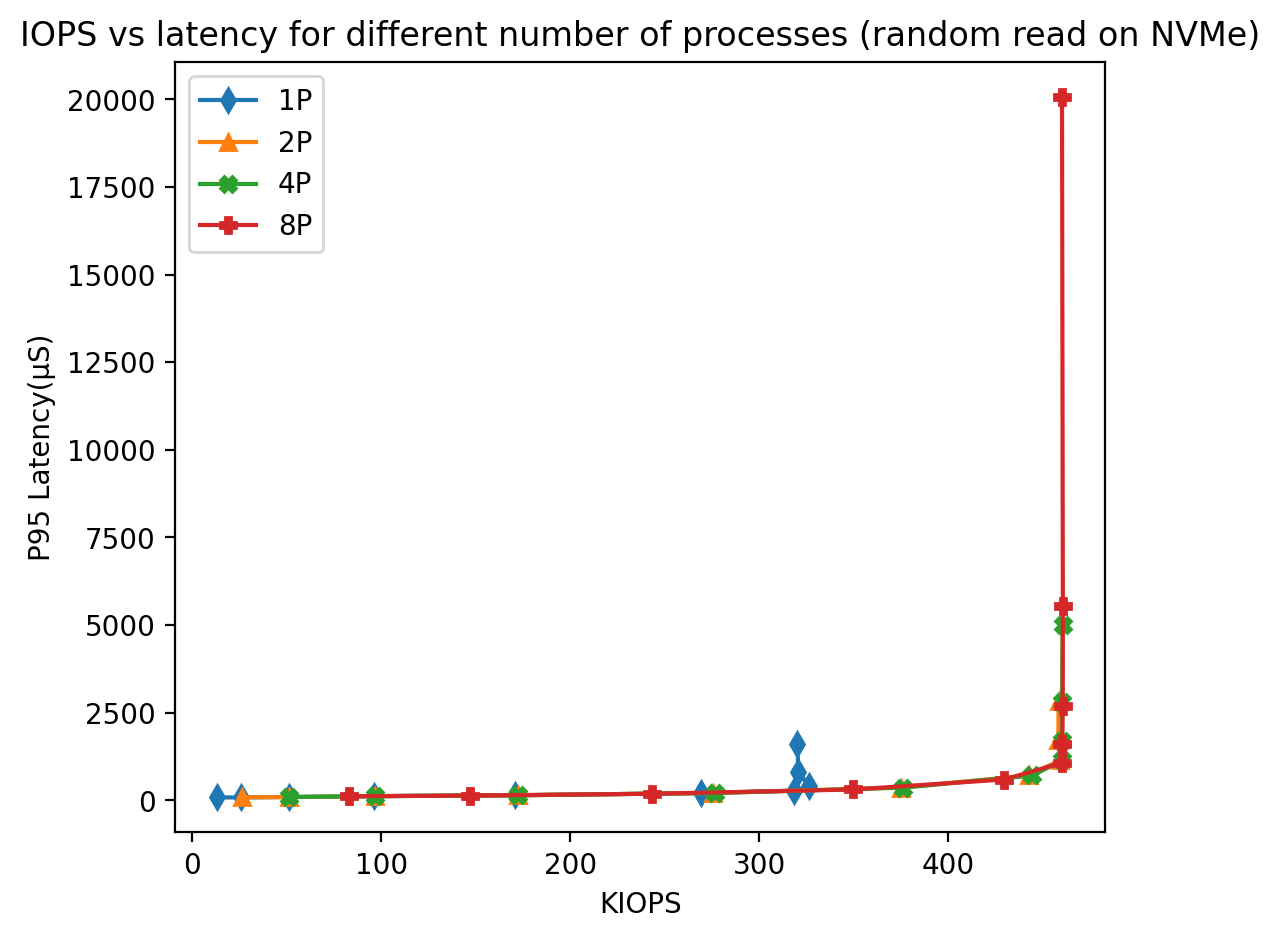

In [10]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("localhost_perf_ioup_SSD_randread_QD{}_P{}_4k".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}P".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for different number of processes (random read on NVMe)")
plt.legend()

{'QD1': [82.432, 13.2819], 'QD2': [83.456, 26.015616667], 'QD4': [94.72, 51.0345375], 'QD8': [119.296, 96.126479167], 'QD16': [144.384, 170.719358333], 'QD32': [207.872, 269.27245], 'QD64': [272.384, 318.345704167], 'QD128': [403.456, 326.374679167], 'QD256': [815.104, 320.70903333300004], 'QD512': [1613.824, 320.20092916699997]}
{'QD1': [88.576, 11.837470833], 'QD2': [120.32, 22.916904167000002], 'QD4': [134.144, 42.9207125], 'QD8': [158.72, 75.9032875], 'QD16': [216.064, 121.876104167], 'QD32': [374.784, 158.5392125], 'QD64': [544.768, 170.82547916700003], 'QD128': [921.6, 170.846170833], 'QD256': [1679.36, 170.85375], 'QD512': [3194.88, 170.8623625]}
{'QD1': [144.384, 9.583516667], 'QD2': [152.576, 18.204820833000003], 'QD4': [175.104, 32.348683333000004], 'QD8': [228.352, 52.896583333], 'QD16': [333.824, 76.839354167], 'QD32': [561.152, 95.2465125], 'QD64': [929.792, 95.29449166699999], 'QD128': [1613.824, 95.298720833], 'QD256': [2965.504, 95.287370833], 'QD512': [5668.864, 95.304

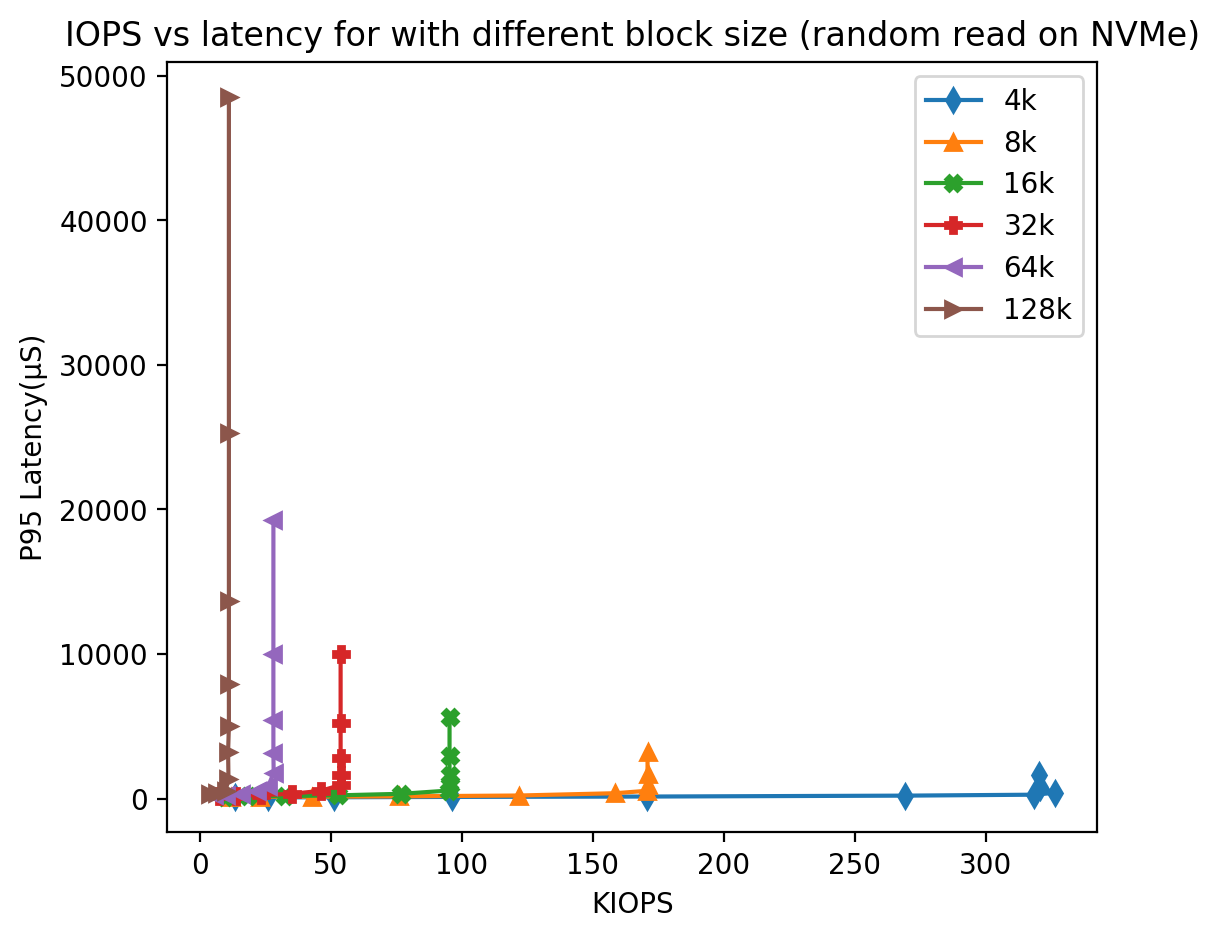

In [12]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in ["4k","8k","16k","32k","64k","128k"]:
    names = []
    experiments = []
    for j in QD:
        experiments.append("localhost_perf_ioup_SSD_randread_QD{}_P1_{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for with different block size (random read on NVMe)")
plt.legend()

{'QD1': [134.144, 7.878103333], 'QD32': [618.496, 89.029878333], 'QD64': [1056.768, 94.01438333300001], 'QD128': [1449.984, 112.950098333], 'QD256': [3096.576, 112.598106845]}
{'QD1': [140.288, 7.5430625], 'QD32': [733.184, 75.8484375], 'QD64': [1204.224, 85.32199583299999], 'QD128': [1417.216, 115.32124583299999], 'QD256': [2768.896, 114.584320833]}
{'QD1': [199.68, 6.2527375], 'QD32': [978.944, 59.685449999999996], 'QD64': [1138.688, 76.977420833], 'QD128': [1826.816, 88.720966667], 'QD256': [3555.328, 86.816479167]}
{'QD1': [280.576, 4.533120833], 'QD32': [1105.92, 41.330329167], 'QD64': [1712.128, 51.030370833], 'QD128': [3096.576, 52.348641667], 'QD256': [6127.616, 51.621941667]}
{'QD1': [378.88, 3.190175], 'QD32': [1777.664, 25.931879166999998], 'QD64': [3325.952, 27.430304167], 'QD128': [6193.152, 27.605929167], 'QD256': [12517.376, 27.5069625]}
{'QD1': [514.048, 2.29], 'QD32': [5144.576, 10.948025], 'QD64': [8159.232, 11.061345832999999], 'QD128': [14090.24, 11.088666667], 'QD2

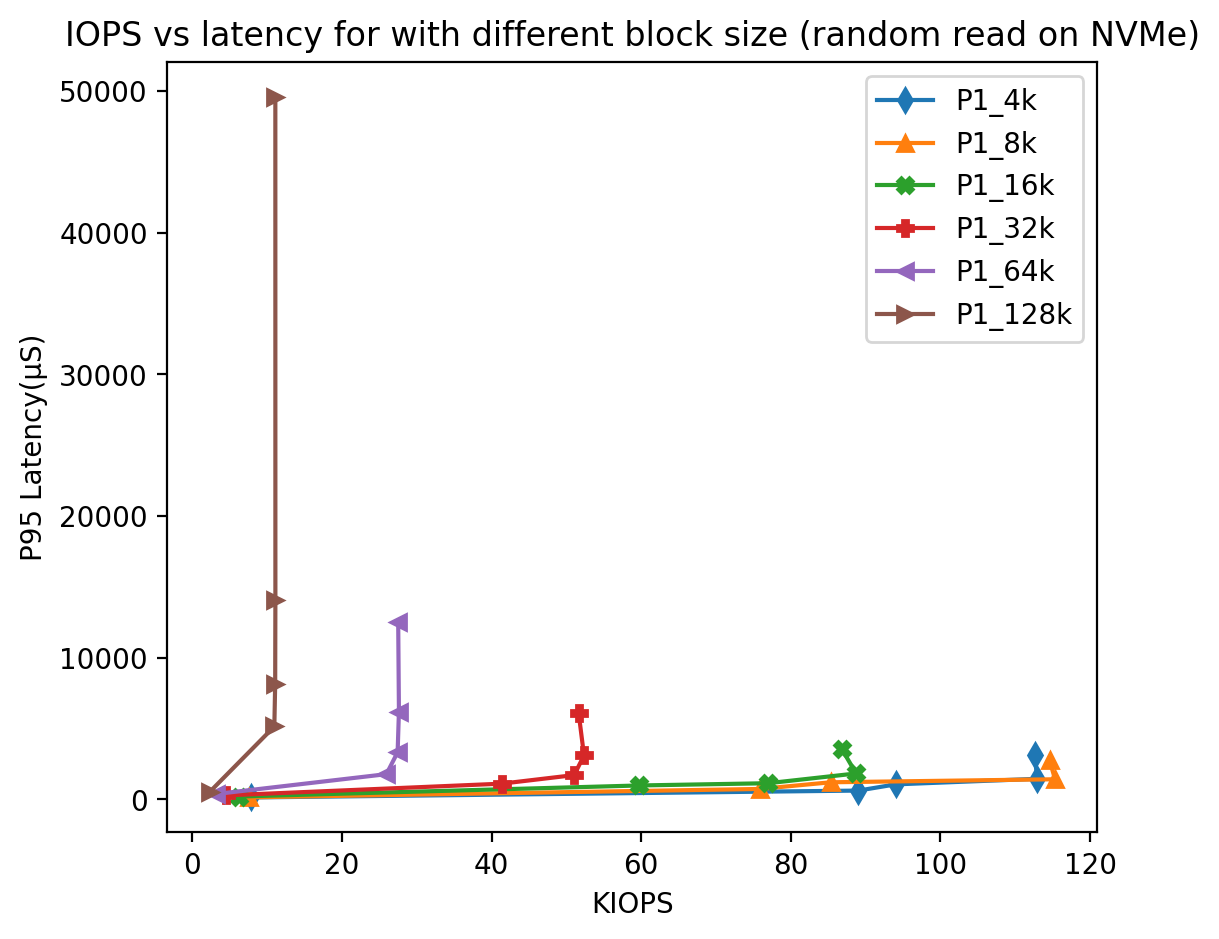

In [10]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in ["P1_4k","P1_8k","P1_16k","P1_32k","P1_64k","P1_128k"]:
    names = []
    experiments = []
    for j in [1, 32, 64, 128, 256]:
        experiments.append("remote_perf_npoll_ioup_SSD_randread_QD{}_{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for with different block size (random read on NVMe)")
plt.legend()

{'QD1': [82.432, 13.275416667], 'QD2': [83.456, 26.139179916], 'QD4': [94.72, 50.8613875], 'QD8': [119.296, 96.058091667], 'QD16': [144.384, 169.832828452], 'QD32': [205.824, 266.9513], 'QD64': [272.384, 317.23183750000004], 'QD128': [411.648, 323.94583750000004], 'QD256': [823.296, 320.84857500000004]}
{'QD1': [82.432, 13.372607723], 'QD2': [85.504, 26.311694561], 'QD4': [110.08, 51.14696454], 'QD8': [128.512, 96.409801621], 'QD16': [162.816, 170.66881171499998], 'QD32': [244.736, 267.459535565], 'QD64': [3194.88, 310.8446125], 'QD128': [4423.68, 305.317038529], 'QD256': [4882.432, 305.70715062799997]}
{'QD1': [82.432, 13.386418410000001], 'QD2': [85.504, 26.33340849], 'QD4': [112.128, 51.102732218], 'QD8': [129.536, 96.053502092], 'QD16': [164.864, 170.551631799], 'QD32': [250.88, 269.10062113], 'QD64': [7241.728, 315.00861234300004], 'QD128': [11468.8, 303.653097751], 'QD256': [12910.592, 294.371242678]}
{'QD1': [82.432, 13.412334728], 'QD2': [85.504, 26.335514644], 'QD4': [112.128,

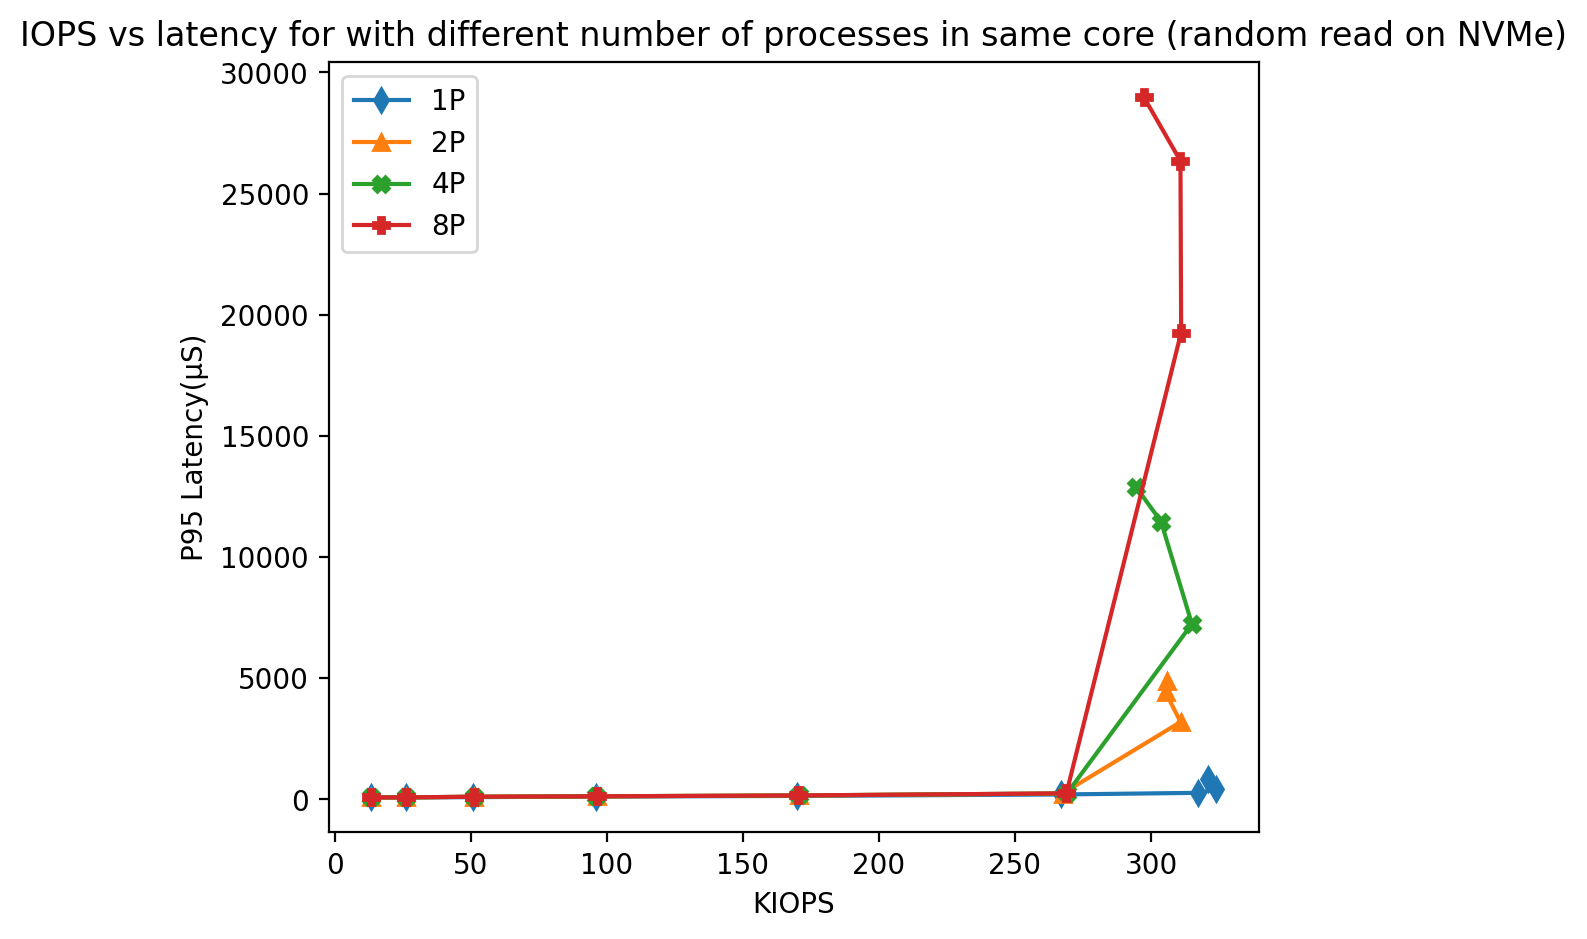

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in [1,2,4,8]:
    names = []
    experiments = []
    for j in [2**k for k in range(9)]:
        experiments.append("localhost_perf_score_ioup_SSD_randread_QD{}_P{}_4k".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}P".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for with different number of processes in same core (random read on NVMe)")
plt.legend()

P2_4k 591201.288889
P2_64K 1779168.999025
P3_4k 926051.866295
P3_64K 1797072.798097
P4_4k 1240938.715715
P4_64K 1797321.814098
P5_4k 1587456.771588
P5_64K 1797351.409471
P6_4k 1781747.467967
P6_64K 1796836.464338
P7_4k 1833306.849582
P7_64K 1796746.986072
P8_4k 1836824.654596
P8_64K 1796908.774629


Text(0.5, 1.0, 'Bandwidth for different block size (random read on NVMeoF-TCP)')

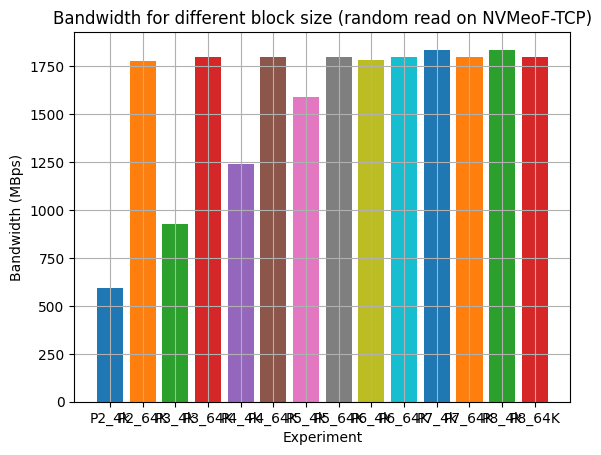

In [17]:
f = []
for i in range(2,9):
    for j in ["4k","64K"]:
        a="P{}_{}".format(i,j)
        f.append(a)

for p in f:
    plot_bw_bar("remote_perf_ioup_SSD_randread_QD128_{}".format(p),"{}".format(p))
plt.title("Bandwidth for different block size (random read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in ["1K","4k","8k","16k"]:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_poll_iou+p_SSD_randread_QD{}_P1_{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for iouring without polling for different block sizes (random read on NVMeoF-TCP)")
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in PROCESS:
    cpu_utilization("local_SSD_randread_QD32_P{}".format(i),"P{}".format(i))
plt.title('CPU utilization vs queue depths')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0
for j in PROCESS:
    CALLS=0
    for i in [1]:
        plot_lat_percentile("local_SSD_randread_QD{}_P{}".format(i,j),"QD{}".format(i),0,1000, ax[pos[index][0], pos[index][1]])
    ax[pos[index][0], pos[index][1]].set_title("{} Fio process".format(j))
    index += 1

ax[0,0].legend()

#plt.title("ECDF latency distribution for diff fio process (random reads on local)")
fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(-0.01, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('Latency percentile for N fio process with different QD (rand read local)', fontsize=16)
plt.tight_layout()

remote_npoll_iou_SSD_randread_QD1_P1_4k {1.0: 85504.0, 5.0: 89600.0, 10.0: 90624.0, 20.0: 91648.0, 30.0: 92672.0, 40.0: 95744.0, 50.0: 138240.0, 60.0: 140288.0, 70.0: 140288.0, 80.0: 142336.0, 90.0: 142336.0, 95.0: 152576.0, 99.0: 158720.0, 99.5: 173056.0, 99.9: 207872.0, 99.95: 246784.0, 99.99: 337920.0}
local_poll_iou_SSD_randread_QD1_P1_4k {1.0: 73216.0, 5.0: 73216.0, 10.0: 74240.0, 20.0: 74240.0, 30.0: 75264.0, 40.0: 75264.0, 50.0: 75264.0, 60.0: 76288.0, 70.0: 86528.0, 80.0: 86528.0, 90.0: 87552.0, 95.0: 87552.0, 99.0: 88576.0, 99.5: 91648.0, 99.9: 102912.0, 99.95: 104960.0, 99.99: 148480.0}
remote_npoll_iou_SSD_randread_QD32_P1_4k {1.0: 181248.0, 5.0: 218112.0, 10.0: 244736.0, 20.0: 284672.0, 30.0: 321536.0, 40.0: 358400.0, 50.0: 391168.0, 60.0: 428032.0, 70.0: 473088.0, 80.0: 552960.0, 90.0: 774144.0, 95.0: 946176.0, 99.0: 1171456.0, 99.5: 1236992.0, 99.9: 1417216.0, 99.95: 1499136.0, 99.99: 1646592.0}
local_poll_iou_SSD_randread_QD32_P1_4k {1.0: 71168.0, 5.0: 76288.0, 10.0: 814

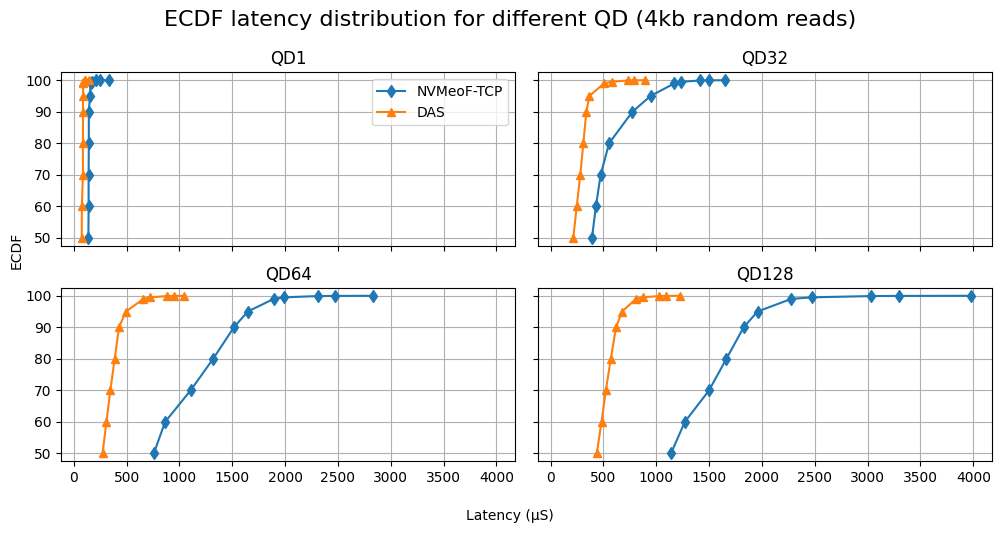

In [36]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,5))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0

for i in [1, 32, 64, 128]:
    CALLS=0
    #plot_lat_percentile("remote_poll_iou_SSD_randread_QD{}_P1_4k".format(i),"Intra",0,1000, ax[pos[index][0], pos[index][1]])
    #plot_lat_percentile("remote_score_poll_iou_SSD_randread_QD1_P{}_4k".format(i),"Inter",0,1000, ax[pos[index][0], pos[index][1]])
    plot_lat_percentile("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"NVMeoF-TCP",50,1000, ax[pos[index][0], pos[index][1]])
    plot_lat_percentile("local_poll_iou_SSD_randread_QD{}_P1_4k".format(i),"DAS",50,1000, ax[pos[index][0], pos[index][1]])
    #plot_lat_percentile("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"Piou",50,1000, ax[pos[index][0], pos[index][1]])


    ax[pos[index][0], pos[index][1]].set_title("QD{}".format(i))
    index += 1

ax[pos[0][0], pos[0][1]].legend()

fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(0, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('ECDF latency distribution for different QD (4kb random reads)', fontsize=16)

plt.tight_layout()

remote_npoll_iou_SSD_randread_QD1_P1_4k {1.0: 85504.0, 5.0: 89600.0, 10.0: 90624.0, 20.0: 91648.0, 30.0: 92672.0, 40.0: 95744.0, 50.0: 138240.0, 60.0: 140288.0, 70.0: 140288.0, 80.0: 142336.0, 90.0: 142336.0, 95.0: 152576.0, 99.0: 158720.0, 99.5: 173056.0, 99.9: 207872.0, 99.95: 246784.0, 99.99: 337920.0}
remote_npoll_ioup_SSD_randread_QD1_P1_4k {1.0: 86528.0, 5.0: 91648.0, 10.0: 91648.0, 20.0: 92672.0, 30.0: 92672.0, 40.0: 94720.0, 50.0: 125440.0, 60.0: 140288.0, 70.0: 142336.0, 80.0: 142336.0, 90.0: 142336.0, 95.0: 156672.0, 99.0: 158720.0, 99.5: 168960.0, 99.9: 193536.0, 99.95: 214016.0, 99.99: 346112.0}
remote_poll_ioup_SSD_randread_QD1_P1_4k {1.0: 89600.0, 5.0: 92672.0, 10.0: 93696.0, 20.0: 94720.0, 30.0: 95744.0, 40.0: 95744.0, 50.0: 97792.0, 60.0: 99840.0, 70.0: 105984.0, 80.0: 108032.0, 90.0: 109056.0, 95.0: 111104.0, 99.0: 120320.0, 99.5: 124416.0, 99.9: 152576.0, 99.95: 183296.0, 99.99: 552960.0}
remote_npoll_iou_SSD_randread_QD32_P1_4k {1.0: 181248.0, 5.0: 218112.0, 10.0: 24

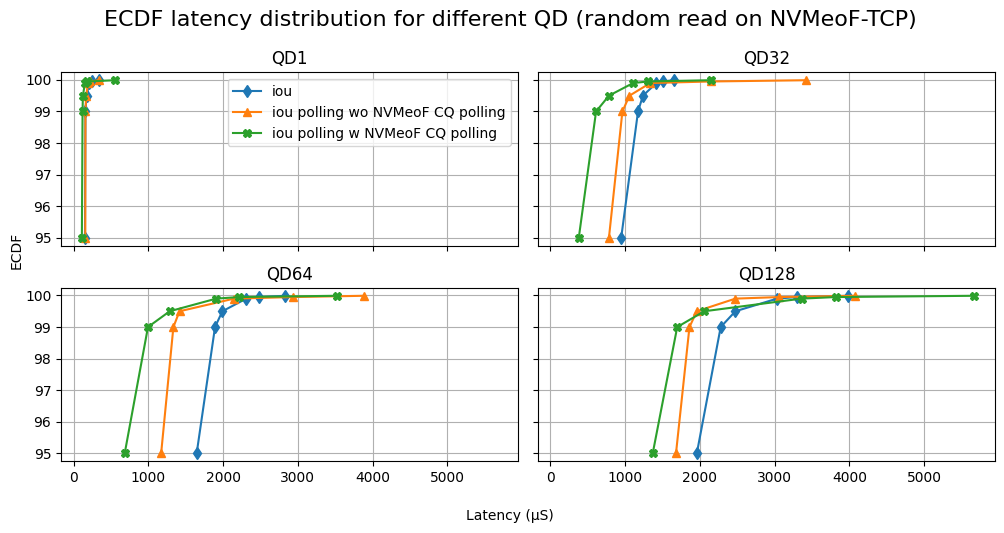

In [30]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,5))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0

for i in [1, 32, 64, 128]:
    CALLS=0
    plot_lat_percentile("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"iou",95,1000, ax[pos[index][0], pos[index][1]])
    #plot_lat_percentile("remote_score_poll_iou_SSD_randread_QD1_P{}_4k".format(i),"Inter",0,1000, ax[pos[index][0], pos[index][1]])
    plot_lat_percentile("remote_npoll_ioup_SSD_randread_QD{}_P1_4k".format(i),"iou polling wo NVMeoF CQ polling",95,1000, ax[pos[index][0], pos[index][1]])
    plot_lat_percentile("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"iou polling w NVMeoF CQ polling",95,1000, ax[pos[index][0], pos[index][1]])


    ax[pos[index][0], pos[index][1]].set_title("QD{}".format(i))
    index += 1

ax[pos[0][0], pos[0][1]].legend()

fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(0, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('ECDF latency distribution for different QD (random read on NVMeoF-TCP)', fontsize=16)

plt.tight_layout()

QD1 {1.0: 109056.0, 5.0: 111104.0, 10.0: 112128.0, 20.0: 115200.0, 30.0: 118272.0, 40.0: 120320.0, 50.0: 122368.0, 60.0: 125440.0, 70.0: 128512.0, 80.0: 132096.0, 90.0: 136192.0, 95.0: 140288.0, 99.0: 171008.0, 99.5: 220160.0, 99.9: 288768.0, 99.95: 337920.0, 99.99: 1122304.0}
Percentage (95% - 50%):  39.74895397489539
QD2 {1.0: 107008.0, 5.0: 110080.0, 10.0: 111104.0, 20.0: 114176.0, 30.0: 116224.0, 40.0: 119296.0, 50.0: 122368.0, 60.0: 125440.0, 70.0: 127488.0, 80.0: 132096.0, 90.0: 140288.0, 95.0: 150528.0, 99.0: 209920.0, 99.5: 234496.0, 99.9: 325632.0, 99.95: 485376.0, 99.99: 1269760.0}
Percentage (95% - 50%):  71.54811715481172
QD4 {1.0: 108032.0, 5.0: 114176.0, 10.0: 119296.0, 20.0: 126464.0, 30.0: 132096.0, 40.0: 138240.0, 50.0: 146432.0, 60.0: 156672.0, 70.0: 168960.0, 80.0: 185344.0, 90.0: 214016.0, 95.0: 236544.0, 99.0: 296960.0, 99.5: 333824.0, 99.9: 448512.0, 99.95: 667648.0, 99.99: 1597440.0}
Percentage (95% - 50%):  102.79720279720279
QD8 {1.0: 119296.0, 5.0: 132096.0, 1

Text(0.5, 1.0, 'ECDF latency plot for different QD (compute-bound) (random read on NVMeoF-TCP)')

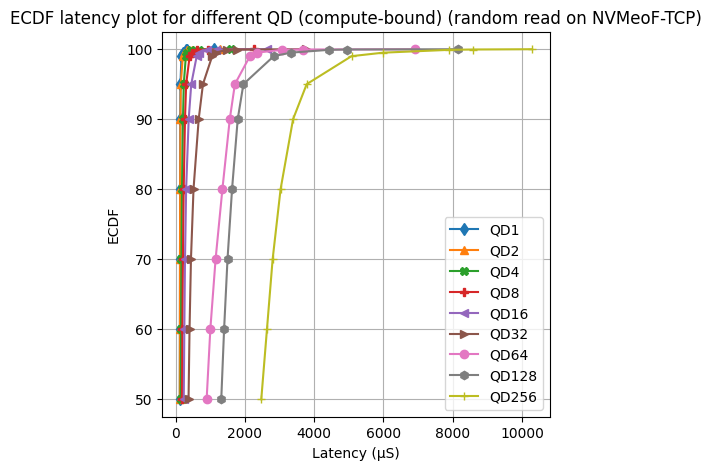

In [44]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
for i in [2**i for i in range(9)]:
    plot_lat_percentile("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i),50,1000, ax)
plt.legend()
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")
plt.title("ECDF latency plot for different QD (compute-bound) (random read on NVMeoF-TCP)")

1P {1.0: 134144.0, 5.0: 138240.0, 10.0: 138240.0, 20.0: 140288.0, 30.0: 140288.0, 40.0: 142336.0, 50.0: 142336.0, 60.0: 150528.0, 70.0: 156672.0, 80.0: 156672.0, 90.0: 158720.0, 95.0: 171008.0, 99.0: 191488.0, 99.5: 207872.0, 99.9: 276480.0, 99.95: 305152.0, 99.99: 544768.0}
Percentage (95% - 50%):  34.53237410071942
2P {1.0: 127488.0, 5.0: 138240.0, 10.0: 140288.0, 20.0: 140288.0, 30.0: 142336.0, 40.0: 144384.0, 50.0: 152576.0, 60.0: 156672.0, 70.0: 156672.0, 80.0: 162816.0, 90.0: 177152.0, 95.0: 197632.0, 99.0: 254976.0, 99.5: 280576.0, 99.9: 337920.0, 99.95: 374784.0, 99.99: 839680.0}
Percentage (95% - 50%):  67.11409395973155
4P {1.0: 126464.0, 5.0: 136192.0, 10.0: 142336.0, 20.0: 150528.0, 30.0: 156672.0, 40.0: 160768.0, 50.0: 168960.0, 60.0: 177152.0, 70.0: 189440.0, 80.0: 205824.0, 90.0: 234496.0, 95.0: 264192.0, 99.0: 321536.0, 99.5: 354304.0, 99.9: 452608.0, 99.95: 536576.0, 99.99: 1318912.0}
Percentage (95% - 50%):  90.30303030303031
8P {1.0: 110080.0, 5.0: 140288.0, 10.0: 15

Text(0.5, 1.0, 'ECDF latency plot for inter process parallelism (compute-bound) (random read on NVMeoF-TCP)')

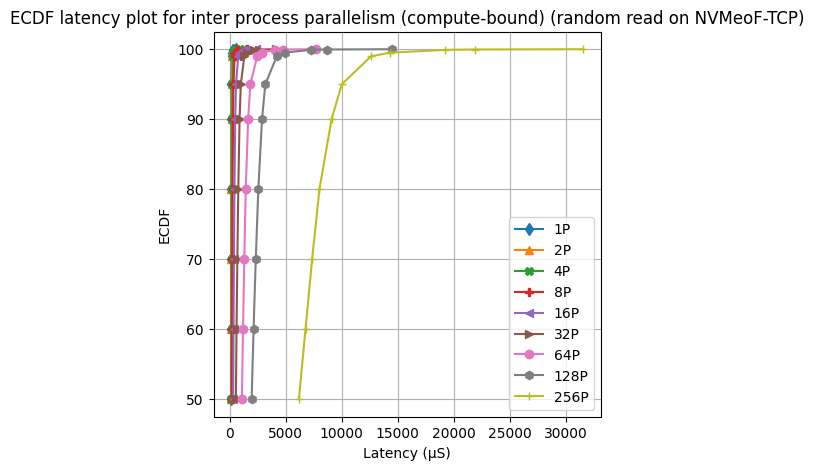

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
for i in [""]:
    plot_lat_percentile("remote_{}_SSD_randread_QD1_P1_4k".format(i),"{}".format(i),50,1000, ax)
plt.legend()
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")
plt.title("ECDF latency plot for inter process parallelism (compute-bound) (random read on NVMeoF-TCP)")

1P {1.0: 798720.0, 5.0: 921600.0, 10.0: 995328.0, 20.0: 1073152.0, 30.0: 1155072.0, 40.0: 1220608.0, 50.0: 1286144.0, 60.0: 1384448.0, 70.0: 1499136.0, 80.0: 1613824.0, 90.0: 1744896.0, 95.0: 1843200.0, 99.0: 2277376.0, 99.5: 2801664.0, 99.9: 3751936.0, 99.95: 4177920.0, 99.99: 5210112.0}
Percentage (95% - 50%):  77.07006369426752
2P {1.0: 839680.0, 5.0: 978944.0, 10.0: 1036288.0, 20.0: 1122304.0, 30.0: 1204224.0, 40.0: 1302528.0, 50.0: 1384448.0, 60.0: 1482752.0, 70.0: 1581056.0, 80.0: 1695744.0, 90.0: 1843200.0, 95.0: 2039808.0, 99.0: 3162112.0, 99.5: 3620864.0, 99.9: 4620288.0, 99.95: 5079040.0, 99.99: 6127616.0}
Percentage (95% - 50%):  128.4023668639053
4P {1.0: 897024.0, 5.0: 1044480.0, 10.0: 1155072.0, 20.0: 1286144.0, 30.0: 1384448.0, 40.0: 1466368.0, 50.0: 1531904.0, 60.0: 1597440.0, 70.0: 1679360.0, 80.0: 1761280.0, 90.0: 1941504.0, 95.0: 2146304.0, 99.0: 3260416.0, 99.5: 3751936.0, 99.9: 5013504.0, 99.95: 5668864.0, 99.99: 7897088.0}
Percentage (95% - 50%):  112.834224598930

Text(0.5, 1.0, 'ECDF latency plot for different number processes (ssd-bound) (random read on NVMeoF-TCP)')

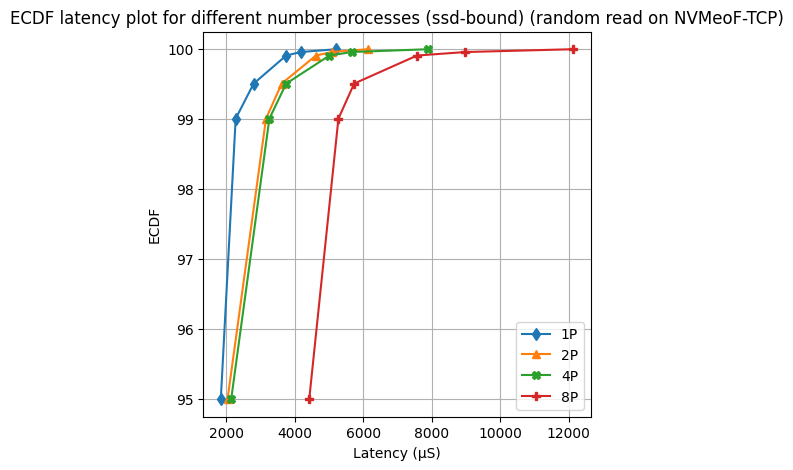

In [47]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
for i in [1, 2, 4, 8]:
    plot_lat_percentile("remote_npoll_iou_SSD_randread_QD128_P{}_4k".format(i),"{}P".format(i),95,1000, ax)
plt.legend()
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")
plt.title("ECDF latency plot for different number processes (ssd-bound) (random read on NVMeoF-TCP)")

64 {1.0: 444416.0, 5.0: 493568.0, 10.0: 528384.0, 20.0: 577536.0, 30.0: 618496.0, 40.0: 659456.0, 50.0: 708608.0, 60.0: 774144.0, 70.0: 880640.0, 80.0: 1044480.0, 90.0: 1220608.0, 95.0: 1368064.0, 99.0: 1761280.0, 99.5: 1974272.0, 99.9: 2605056.0, 99.95: 2932736.0, 99.99: 4227072.0}
Percentage (95% - 50%):  148.5549132947977
65 {1.0: 460800.0, 5.0: 593920.0, 10.0: 667648.0, 20.0: 774144.0, 30.0: 872448.0, 40.0: 970752.0, 50.0: 1089536.0, 60.0: 1236992.0, 70.0: 1400832.0, 80.0: 1548288.0, 90.0: 1728512.0, 95.0: 1875968.0, 99.0: 2277376.0, 99.5: 2506752.0, 99.9: 3227648.0, 99.95: 3686400.0, 99.99: 5275648.0}
Percentage (95% - 50%):  109.02255639097744


Text(0, 0.5, 'ECDF')

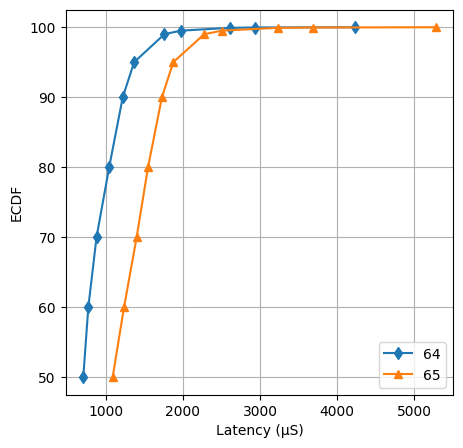

In [21]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
for i in [64,65]:
    plot_lat_percentile("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"{}".format(i),50,1000, ax)
plt.legend()
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")
#plt.title("Inter process parallelism (Compute bound) (random read on NVMeoF-TCP)")

In [12]:
fp = open("./performance_limit/crunched_numbers_performance_limit.json")
op = json.load(fp)

remote_icpu_intra_iou_SSD_randread_L50 {1.0: 240640.0, 5.0: 370688.0, 10.0: 481280.0, 20.0: 659456.0, 30.0: 798720.0, 40.0: 921600.0, 50.0: 1036288.0, 60.0: 1171456.0, 70.0: 1351680.0, 80.0: 2023424.0, 90.0: 7438336.0, 95.0: 9371648.0, 99.0: 12124160.0, 99.5: 13172736.0, 99.9: 14876672.0, 99.95: 15400960.0, 99.99: 17694720.0}
remote_icpu_intra_iou_SSD_randread_L80 {1.0: 313344.0, 5.0: 585728.0, 10.0: 815104.0, 20.0: 1318912.0, 30.0: 2039808.0, 40.0: 4358144.0, 50.0: 5079040.0, 60.0: 5537792.0, 70.0: 5996544.0, 80.0: 6389760.0, 90.0: 7045120.0, 95.0: 7766016.0, 99.0: 11337728.0, 99.5: 13041664.0, 99.9: 21889024.0, 99.95: 30539776.0, 99.99: 49020928.0}
remote_icpu_intra_iou_SSD_randread_L100 {1.0: 3031040.0, 5.0: 3981312.0, 10.0: 4227072.0, 20.0: 4489216.0, 30.0: 4751360.0, 40.0: 4947968.0, 50.0: 5144576.0, 60.0: 5406720.0, 70.0: 5734400.0, 80.0: 6127616.0, 90.0: 6782976.0, 95.0: 7503872.0, 99.0: 12124160.0, 99.5: 16056320.0, 99.9: 34340864.0, 99.95: 42205184.0, 99.99: 70778880.0}


Text(0, 0.5, 'ECDF')

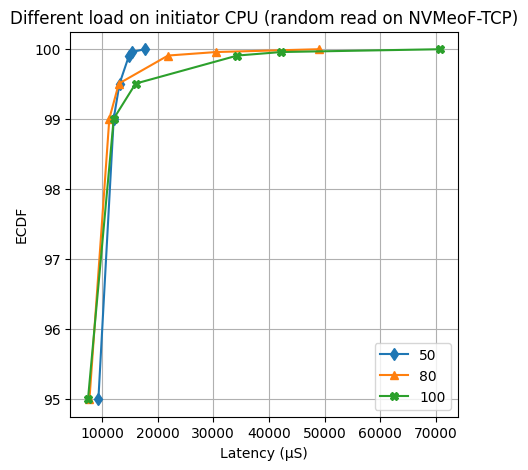

In [21]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
for i in ["50","80","100"]:
    plot_lat_percentile("remote_icpu_intra_iou_SSD_randread_L{}".format(i),i,95,1000, ax)
plt.legend()
plt.title("Different load on initiator CPU (random read on NVMeoF-TCP)")
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")

remote_1c_poll_ioup_SSD_randread_QD1_P8_4k {1.0: 516.0, 5.0: 154624.0, 10.0: 211968.0, 20.0: 309248.0, 30.0: 403456.0, 40.0: 528384.0, 50.0: 675840.0, 60.0: 831488.0, 70.0: 1003520.0, 80.0: 1220608.0, 90.0: 1564672.0, 95.0: 1859584.0, 99.0: 2408448.0, 99.5: 2637824.0, 99.9: 3129344.0, 99.95: 3325952.0, 99.99: 3784704.0}
remote_2c_poll_ioup_SSD_randread_QD1_P8_4k {1.0: 76288.0, 5.0: 107008.0, 10.0: 117248.0, 20.0: 128512.0, 30.0: 138240.0, 40.0: 148480.0, 50.0: 160768.0, 60.0: 175104.0, 70.0: 193536.0, 80.0: 218112.0, 90.0: 259072.0, 95.0: 292864.0, 99.0: 370688.0, 99.5: 403456.0, 99.9: 477184.0, 99.95: 509952.0, 99.99: 577536.0}
remote_4c_poll_ioup_SSD_randread_QD1_P8_4k {1.0: 89600.0, 5.0: 103936.0, 10.0: 110080.0, 20.0: 117248.0, 30.0: 122368.0, 40.0: 127488.0, 50.0: 132096.0, 60.0: 138240.0, 70.0: 146432.0, 80.0: 158720.0, 90.0: 179200.0, 95.0: 199680.0, 99.0: 240640.0, 99.5: 257024.0, 99.9: 292864.0, 99.95: 309248.0, 99.99: 370688.0}
remote_8c_poll_ioup_SSD_randread_QD1_P8_4k {1.0:

Text(0.5, 1.0, 'ECDF latency plot for QD1 with iou polling (random read on NVMeoF-TCP)')

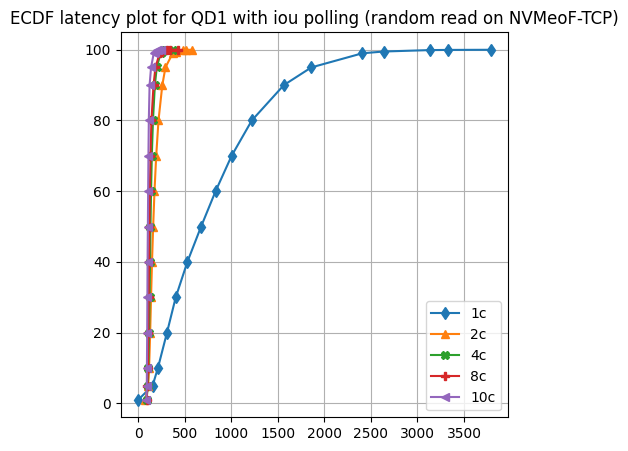

In [37]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
plot_lat_percentile("remote_1c_poll_ioup_SSD_randread_QD1_P8_4k".format(i),"1c",0,1000, ax)
plot_lat_percentile("remote_2c_poll_ioup_SSD_randread_QD1_P8_4k".format(i),"2c",0,1000, ax)
plot_lat_percentile("remote_4c_poll_ioup_SSD_randread_QD1_P8_4k".format(i),"4c",0,1000, ax)
plot_lat_percentile("remote_8c_poll_ioup_SSD_randread_QD1_P8_4k".format(i),"8c",0,1000, ax)
plot_lat_percentile("remote_10c_poll_ioup_SSD_randread_QD1_P8_4k".format(i),"10c",0,1000, ax)

plt.legend()
plt.title("ECDF latency plot for QD1 with iou polling (random read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
plot_lat_percentile("remote_1c_poll_iou_SSD_randread_QD1_P8_4k".format(i),"1c",0,1000, ax)
plot_lat_percentile("remote_2c_poll_iou_SSD_randread_QD1_P8_4k".format(i),"2c",0,1000, ax)
plot_lat_percentile("remote_4c_poll_iou_SSD_randread_QD1_P8_4k".format(i),"4c",0,1000, ax)
plot_lat_percentile("remote_8c_poll_iou_SSD_randread_QD1_P8_4k".format(i),"8c",0,1000, ax)
plot_lat_percentile("remote_10c_poll_iou_SSD_randread_QD1_P8_4k".format(i),"10c",0,1000, ax)

plt.legend()
plt.title("ECDF latency plot for QD1 with iou no polling (random read on NVMeoF-TCP)")

remote_1c_npoll_ioup_SSD_randread_QD1_P8_4k {1.0: 113152.0, 5.0: 122368.0, 10.0: 128512.0, 20.0: 136192.0, 30.0: 144384.0, 40.0: 150528.0, 50.0: 158720.0, 60.0: 168960.0, 70.0: 183296.0, 80.0: 197632.0, 90.0: 226304.0, 95.0: 254976.0, 99.0: 333824.0, 99.5: 378880.0, 99.9: 2375680.0, 99.95: 3063808.0, 99.99: 3719168.0}
remote_2c_npoll_ioup_SSD_randread_QD1_P8_4k {1.0: 105984.0, 5.0: 111104.0, 10.0: 114176.0, 20.0: 119296.0, 30.0: 124416.0, 40.0: 129536.0, 50.0: 134144.0, 60.0: 142336.0, 70.0: 152576.0, 80.0: 166912.0, 90.0: 189440.0, 95.0: 209920.0, 99.0: 264192.0, 99.5: 288768.0, 99.9: 387072.0, 99.95: 456704.0, 99.99: 2965504.0}
remote_4c_npoll_ioup_SSD_randread_QD1_P8_4k {1.0: 103936.0, 5.0: 109056.0, 10.0: 112128.0, 20.0: 115200.0, 30.0: 118272.0, 40.0: 121344.0, 50.0: 125440.0, 60.0: 128512.0, 70.0: 132096.0, 80.0: 142336.0, 90.0: 158720.0, 95.0: 177152.0, 99.0: 218112.0, 99.5: 238592.0, 99.9: 325632.0, 99.95: 872448.0, 99.99: 3915776.0}
remote_8c_npoll_ioup_SSD_randread_QD1_P8_4k 

Text(0.5, 1.0, 'ECDF latency plot for QD1 with iou block polling (random read on NVMeoF-TCP)')

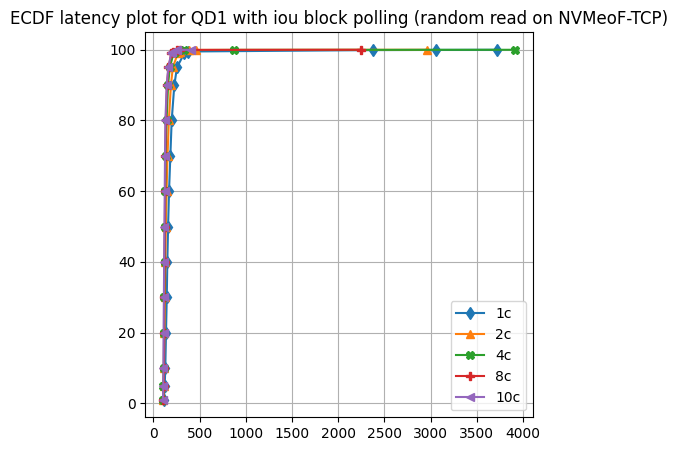

In [40]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
plot_lat_percentile("remote_1c_npoll_ioup_SSD_randread_QD1_P8_4k".format(i),"1c",0,1000, ax)
plot_lat_percentile("remote_2c_npoll_ioup_SSD_randread_QD1_P8_4k".format(i),"2c",0,1000, ax)
plot_lat_percentile("remote_4c_npoll_ioup_SSD_randread_QD1_P8_4k".format(i),"4c",0,1000, ax)
plot_lat_percentile("remote_8c_npoll_ioup_SSD_randread_QD1_P8_4k".format(i),"8c",0,1000, ax)
plot_lat_percentile("remote_10c_npoll_ioup_SSD_randread_QD1_P8_4k".format(i),"10c",0,1000, ax)

plt.legend()
plt.title("ECDF latency plot for QD1 with iou block polling (random read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
plot_lat_percentile("local_poll_iou_SSD_randread_QD1_P1_4k".format(i),"poll_iou",0,1000, ax)
plot_lat_percentile("local_poll_ioup_SSD_randread_QD1_P1_4k".format(i),"poll_ioup",0,1000, ax)
plt.legend()
plt.title("ECDF latency plot for QD1 (random read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for j in PROCESS:
    experiments=[]
    for i in QD:
        experiments.append("local_compute_SSD_randread_QD{}_BP{}".format(i, j))
    plot_iops_line(experiments, QD, "BP{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS vs queue depth compute interference (random read on local)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

In [ ]:
for j in PROCESS:
    plot_lat_percentile("local_compute_SSD_randread_QD1_BP{}".format(j),"BP{}".format(j),0,1000)
plt.legend()
plt.title("Latency ECDF with compute interference (rand read on local)")

In [ ]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0
for j in PROCESS:
    CALLS=0
    for i in [1]:
        plot_lat_percentile("local_compute_SSD_randread_QD{}_BP{}".format(i,j),"QD{}".format(i),0,1000, ax[pos[index][0], pos[index][1]])
    ax[pos[index][0], pos[index][1]].set_title("{} background process".format(j))
    index += 1

ax[0,0].legend()

#plt.title("ECDF latency distribution for diff fio process (random reads on local)")
fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(-0.01, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('Latency percentile for N compute interference with different QD (rand read local)', fontsize=16)
plt.tight_layout()

{'QD1': [24.448, 11.462647059], 'QD2': [70.144, 13.99502521], 'QD4': [91.648, 20.345975], 'QD8': [109.056, 34.203302521], 'QD16': [97.792, 68.674193277], 'QD32': [122.368, 115.538], 'QD64': [164.864, 165.710117647], 'QD128': [337.92, 185.761554622], 'QD256': [782.336, 166.039445378]}
{'QD1': [24.192, 7.742840336], 'QD2': [69.12, 10.437621849], 'QD4': [103.936, 13.489689076000001], 'QD8': [117.248, 21.138697478999998], 'QD16': [125.44, 40.603512605000006], 'QD32': [122.368, 80.263151261], 'QD64': [160.768, 114.227], 'QD128': [378.88, 111.76020833300001], 'QD256': [774.144, 112.10922689099999]}
{'QD1': [24.192, 4.605647059], 'QD2': [69.12, 6.218806722999999], 'QD4': [104.96, 7.957084034], 'QD8': [154.624, 10.476], 'QD16': [134.144, 20.755016807], 'QD32': [138.24, 42.449478991999996], 'QD64': [162.816, 69.821226891], 'QD128': [382.976, 66.999605042], 'QD256': [749.568, 69.73743697500001]}
{'QD1': [24.448, 2.511478992], 'QD2': [69.12, 3.430966387], 'QD4': [104.96, 4.395386555], 'QD8': [154

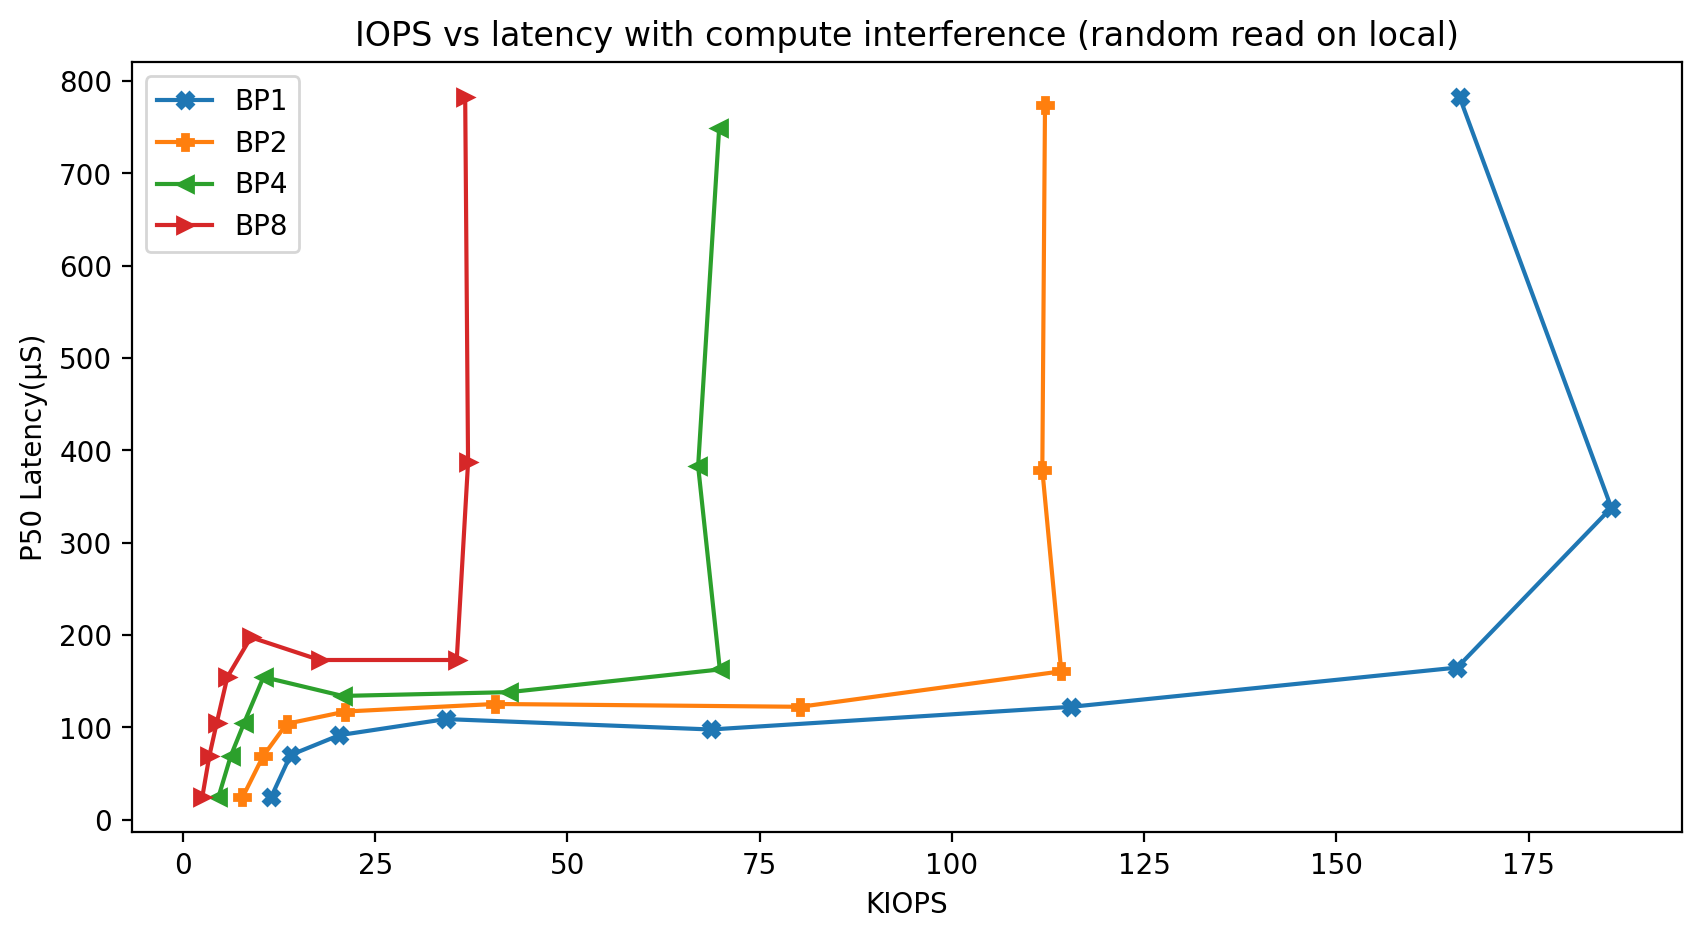

In [21]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("local_compute_SSD_randread_QD{}_BP{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,50.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="BP{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P50 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency with compute interference (random read on local)")
plt.legend()

BP1 [4.341361345, 6.819722689, 11.040848739, 17.814537815, 26.410084034, 33.132722689000005, 40.180596639, 53.411184874, 51.734226891]
BP2 [2.731319328, 4.931907562999999, 7.462815126000001, 11.923084034, 17.741462185, 22.880831933, 28.897151260999998, 36.441705882, 35.929764706]
BP4 [1.469243697, 2.731117647, 4.268873950000001, 6.992764706, 10.941798319, 14.042966387, 17.78107563, 23.181966387, 22.823907563000002]
BP8 [0.79789916, 1.423058824, 2.438218487, 3.868907563, 5.7071176470000005, 7.935722689, 9.871705882, 12.077327730999999, 12.093529412]


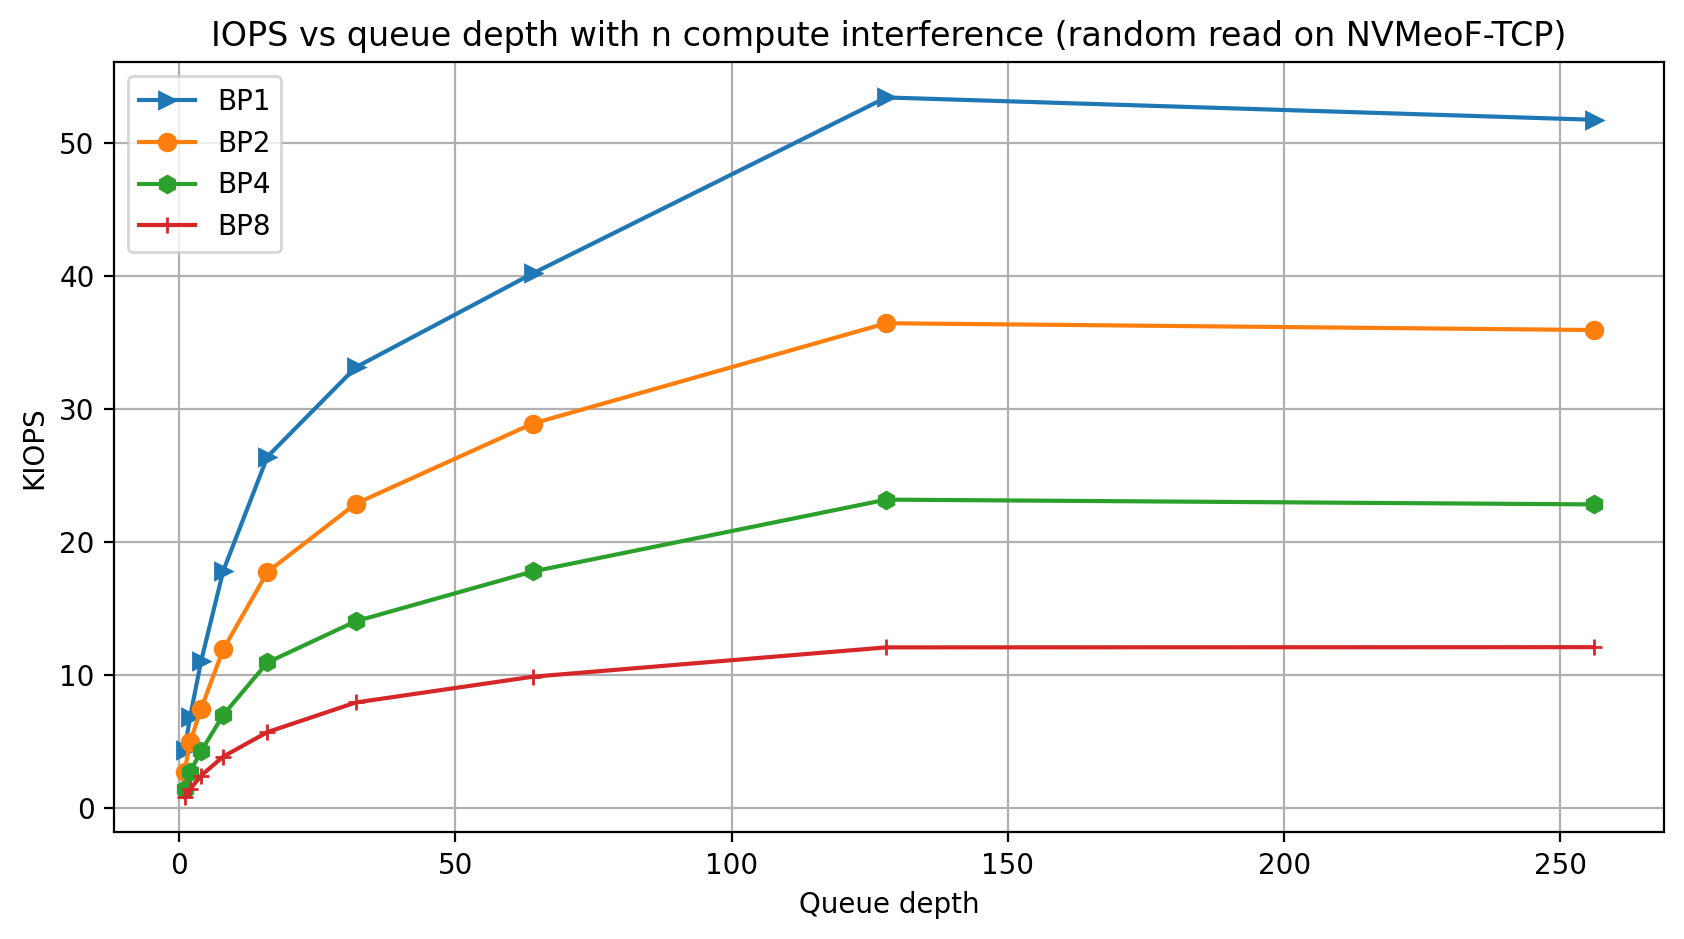

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for j in PROCESS:
    experiments=[]
    for i in QD:
        experiments.append("remote_compute_SSD_randread_QD{}_BP{}".format(i, j))
    plot_iops_line(experiments, QD, "BP{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS vs queue depth with n compute interference (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

KeyError: 'remote_compute_SSD_randread_QD1_BP1'

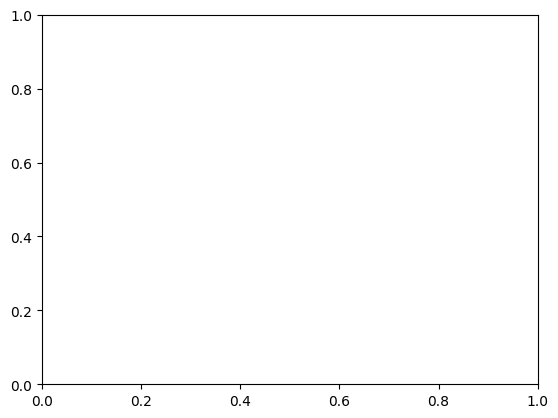

In [32]:
for j in PROCESS:
    plot_lat_percentile("remote_compute_SSD_randread_QD1_BP{}".format(j),"BP{}".format(j),0,1000)
plt.legend()
plt.title("Latency ECDF with compute interference (rand read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0
for j in PROCESS:
    CALLS=0
    for i in [1]:
        plot_lat_percentile("remote_compute_SSD_randread_QD{}_BP{}".format(i,j),"QD{}".format(i),0,1000, ax[pos[index][0], pos[index][1]])
    ax[pos[index][0], pos[index][1]].set_title("{} background process".format(j))
    index += 1

ax[0,0].legend()

#plt.title("ECDF latency distribution for diff fio process (random reads on local)")
fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(-0.01, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('Latency percentile for N compute interference (rand read NVMeoF-TCP)', fontsize=16)
plt.tight_layout()

{'QD1': [102.912, 4.341361345], 'QD2': [140.288, 6.819722689], 'QD4': [173.056, 11.040848739], 'QD8': [234.496, 17.814537815], 'QD16': [309.248, 26.410084034], 'QD32': [518.144, 33.132722689000005], 'QD64': [937.984, 40.180596639], 'QD128': [1499.136, 53.411184874], 'QD256': [5275.648, 51.734226891]}
{'QD1': [115.2, 2.731319328], 'QD2': [134.144, 4.931907562999999], 'QD4': [183.296, 7.462815126000001], 'QD8': [250.88, 11.923084034], 'QD16': [346.112, 17.741462185], 'QD32': [585.728, 22.880831933], 'QD64': [1028.096, 28.897151260999998], 'QD128': [3489.792, 36.441705882], 'QD256': [6586.368, 35.929764706]}
{'QD1': [129.536, 1.469243697], 'QD2': [148.48, 2.731117647], 'QD4': [207.872, 4.268873950000001], 'QD8': [272.384, 6.992764706], 'QD16': [387.072, 10.941798319], 'QD32': [692.224, 14.042966387], 'QD64': [2637.824, 17.78107563], 'QD128': [4882.432, 23.181966387], 'QD256': [11206.656, 22.823907563000002]}
{'QD1': [136.192, 0.79789916], 'QD2': [166.912, 1.423058824], 'QD4': [220.16, 2.4

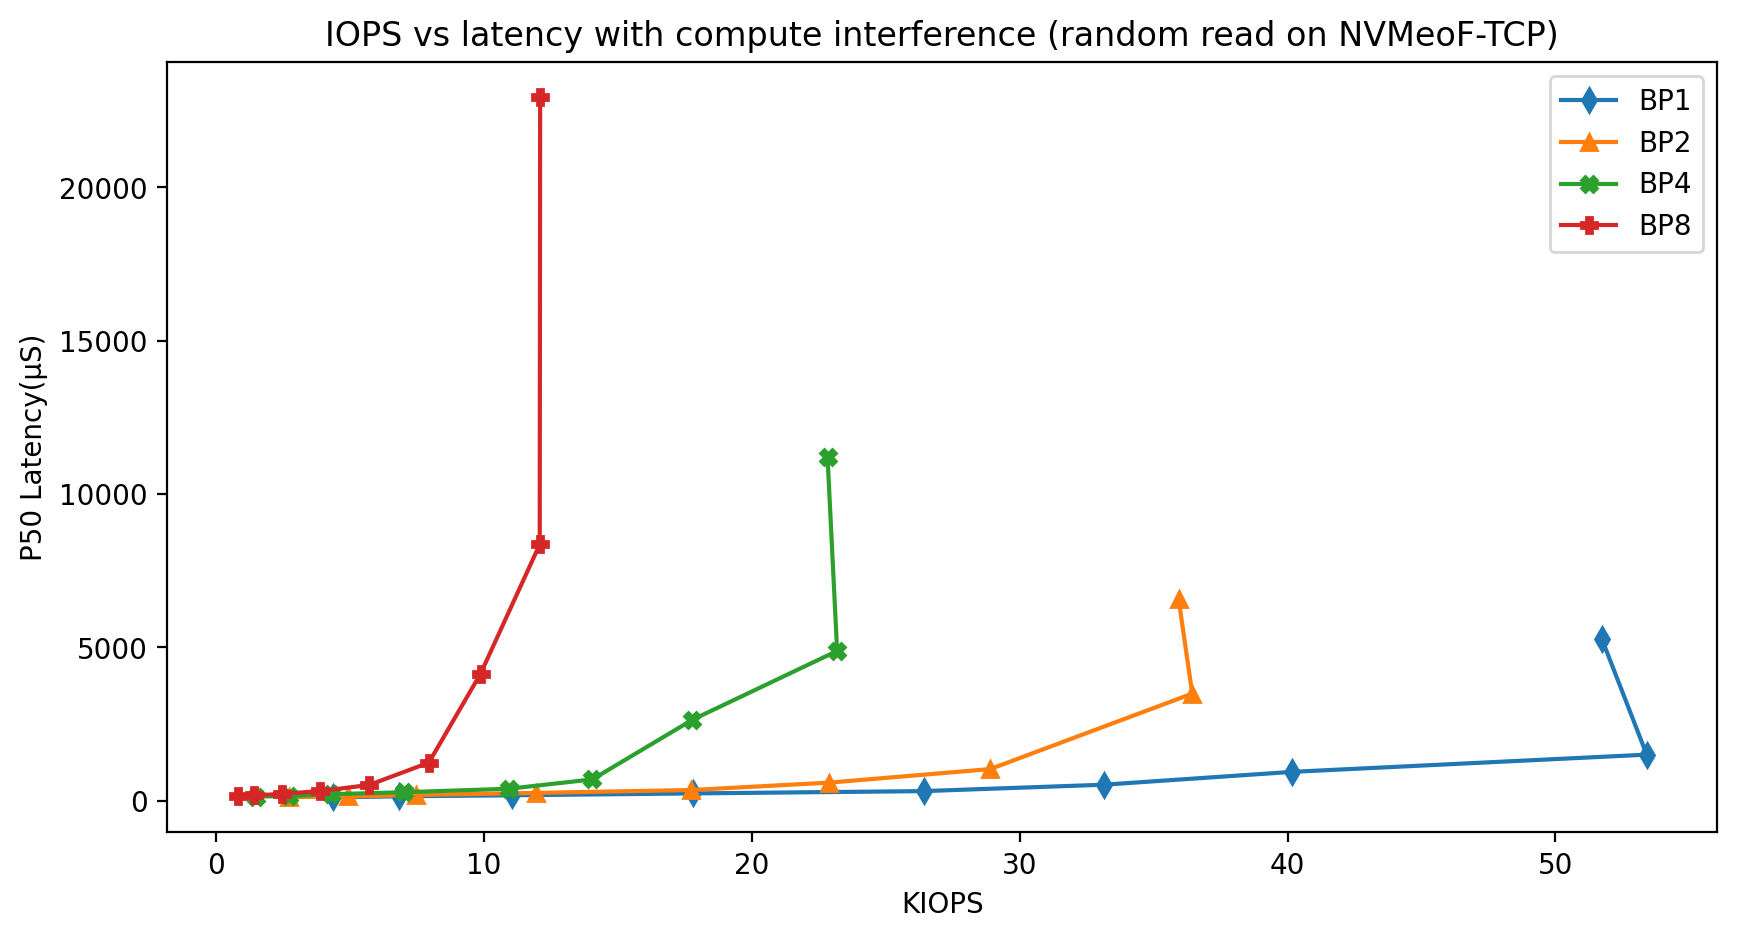

In [29]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_compute_SSD_randread_QD{}_BP{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,50.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="BP{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P50 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency with compute interference (random read on NVMeoF-TCP)")
plt.legend()

<h1>Timeseries of logs</h1>

Run1 106.415 135.97636874051594
Run2 41.822 63.9823121869783


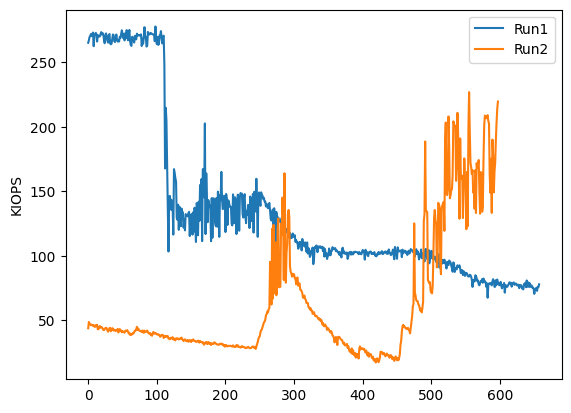

In [13]:
plot_iops_ts("logs/Run1/local_SSD_randwrite_QD32_P1_iops.log","Run1")
plot_iops_ts("logs/local_SSD_randwrite_QD32_P1_iops.log","Run2")
#plot_iops_ts("logs/Run1/local_SSD_randwrite_QD32_P1_iops.log","32")
#plot_iops_ts("logs/local_SSD_randwrite_QD64_P1_iops.log","64")
#plot_iops_ts("logs/local_SSD_randwrite_QD128_P1_iops.log","128")
#plt.xlabel("Time")
plt.ylabel("KIOPS")
plt.legend()

1 13.725
32 247.642
64 340.15
128 367.813


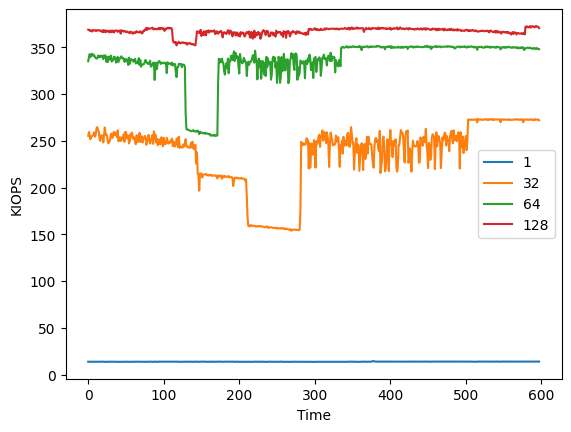

In [33]:
plot_iops_ts("logs/Run1/local_SSD_randread_QD1_P1_iops.log","1")
plot_iops_ts("logs/Run1/local_SSD_randread_QD32_P1_iops.log","32")
plot_iops_ts("logs/Run1/local_SSD_randread_QD64_P1_iops.log","64")
plot_iops_ts("logs/Run1/local_SSD_randread_QD128_P1_iops.log","128")
plt.xlabel("Time")
plt.ylabel("KIOPS")
plt.legend()

1 58.457
32 80.325
64 298.212
128 301.563


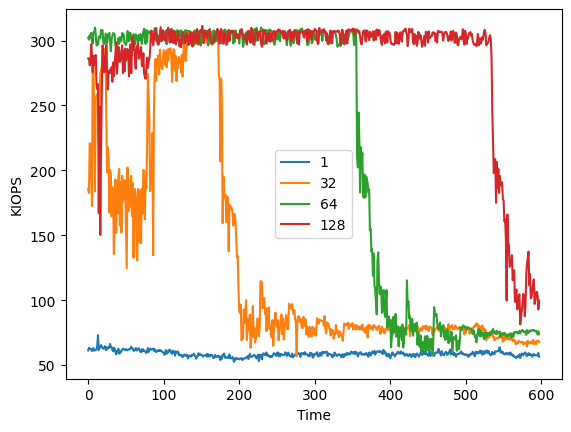

In [35]:
plot_iops_ts("logs/Run1/local_SSD_write_QD1_P1_iops.log","1")
plot_iops_ts("logs/Run1/local_SSD_write_QD32_P1_iops.log","32")
plot_iops_ts("logs/Run1/local_SSD_write_QD64_P1_iops.log","64")
plot_iops_ts("logs/Run1/local_SSD_write_QD128_P1_iops.log","128")
plt.xlabel("Time")
plt.ylabel("KIOPS")
plt.legend()

<h1>QoS</h1>

In [3]:
fp = open("./qos/crunched_numbers_qos.json")
op = json.load(fp)
op.keys()

dict_keys(['local_mqd_bread_fread_SSD_BP7_BS64k', 'remote_isolate_fread_bread_SSD_BP6_BS64k', 'remote_isolate_fread_bread_SSD_BP9_BS64k', 'local_isolate_fread_bread_SSD_BP7_BS4k', 'remote_isolate_fread_bread_SSD_BP0_BS64k', 'local_mqd_bread_fread_SSD_BP8_BS64k', 'local_mqd_bread_fread_SSD_BP4_BS64k', 'local_isolate_fread_bread_SSD_BP3_BS4k', 'local_isolate_fread_bread_SSD_BP10_BS64k', 'local_isolate_fread_bread_SSD_BP3_BS64k', 'remote_isolate_fread_bread_SSD_BP7_BS4k', 'local_isolate_fread_bread_SSD_BP7_BS64k', 'remote_isolate_fread_bread_SSD_BP8_BS64k', 'local_isolate_fread_bread_SSD_BP9_BS4k', 'local_isolate_fread_bread_SSD_BP1_BS4k', 'local_mqd_bread_fread_SSD_BP4_BS4k', 'local_mqd_bread_fread_SSD_BP9_BS64k', 'remote_isolate_fread_bread_SSD_BP2_BS64k', 'remote_isolate_fread_bread_SSD_BP3_BS64k', 'remote_isolate_fread_bread_SSD_BP1_BS4k', 'remote_isolate_fread_bread_SSD_BP0_BS4k', 'local_mqd_bread_fread_SSD_BP6_BS64k', 'local_isolate_fread_bread_SSD_BP8_BS4k', 'local_mqd_bread_fread_

remote_share_BP1 {1.0: 121344.0, 5.0: 144384.0, 10.0: 166912.0, 20.0: 230400.0, 30.0: 276480.0, 40.0: 350208.0, 50.0: 477184.0, 60.0: 659456.0, 70.0: 790528.0, 80.0: 987136.0, 90.0: 1204224.0, 95.0: 1335296.0, 99.0: 1777664.0, 99.5: 2023424.0, 99.9: 3031040.0, 99.95: 3522560.0, 99.99: 5603328.0}
remote_share_BP2 {1.0: 140288.0, 5.0: 201728.0, 10.0: 309248.0, 20.0: 528384.0, 30.0: 667648.0, 40.0: 782336.0, 50.0: 905216.0, 60.0: 1036288.0, 70.0: 1187840.0, 80.0: 1368064.0, 90.0: 1679360.0, 95.0: 2007040.0, 99.0: 3063808.0, 99.5: 3620864.0, 99.9: 5079040.0, 99.95: 5799936.0, 99.99: 8093696.0}
remote_share_BP4 {1.0: 152576.0, 5.0: 313344.0, 10.0: 501760.0, 20.0: 774144.0, 30.0: 995328.0, 40.0: 1220608.0, 50.0: 1466368.0, 60.0: 1744896.0, 70.0: 2113536.0, 80.0: 2670592.0, 90.0: 4177920.0, 95.0: 6389760.0, 99.0: 14614528.0, 99.5: 20054016.0, 99.9: 34340864.0, 99.95: 43253760.0, 99.99: 64749568.0}
remote_share_BP8 {1.0: 193536.0, 5.0: 489472.0, 10.0: 741376.0, 20.0: 1105920.0, 30.0: 1433600.0

Text(0.5, 1.0, 'Latency ECDF with interference from other flows (rand read on NVMeoF-TCP)')

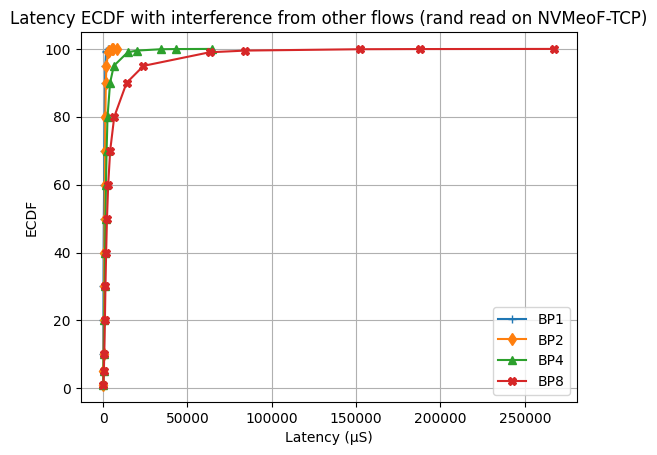

In [31]:
for j in [1,2,4,8]:
    plot_lat_percentile("remote_share_BP{}".format(j),"BP{}".format(j),0,1000)
plt.legend()
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")
plt.title("Latency ECDF with interference from other flows (rand read on NVMeoF-TCP)")

[{'label': 'same core', 'whislo': 31.872, 'q1': 80.384, 'med': 119.296, 'q3': 199.68, 'whishi': 321.536, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 30.848, 'q1': 77.312, 'med': 110.08, 'q3': 183.296, 'whishi': 292.864, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 30.592, 'q1': 76.288, 'med': 105.984, 'q3': 175.104, 'whishi': 276.48, 'fliers': []}]
[{'label': 'different core', 'whislo': 41.216, 'q1': 88.576, 'med': 122.368, 'q3': 193.536, 'whishi': 301.056, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 46.848, 'q1': 95.744, 'med': 127.488, 'q3': 193.536, 'whishi': 296.96, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 28.544, 'q1': 29.568, 'med': 30.592, 'q3': 75.264, 'whishi': 87.552, 'fliers': []}]


Text(0.5, 1.0, 'Latency for local L-Flow')

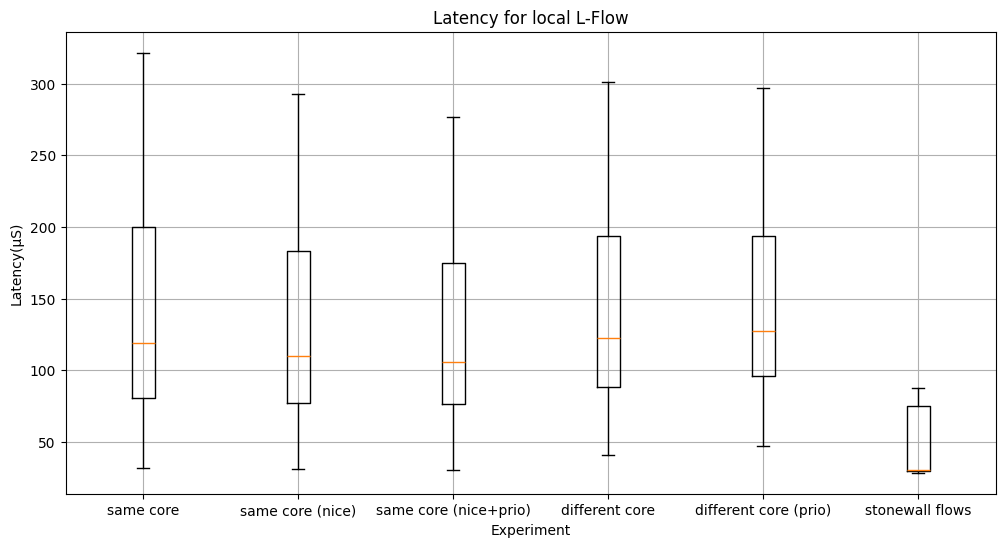

In [11]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

plot_lat_bar("local_same_core_latency","same core", ax, 0)
plot_lat_bar("local_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_prio_diff_core_latency","different core (prio)", ax, 4)
plot_lat_bar("local_stonewall_latency", "stonewall flows", ax, 5)
#plt.yscale("log")
plt.title('Latency for local L-Flow')

[{'label': 'same core', 'whislo': 189.44, 'q1': 276.48, 'med': 419.84, 'q3': 708.608, 'whishi': 970.752, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 181.248, 'q1': 268.288, 'med': 399.36, 'q3': 684.032, 'whishi': 921.6, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 187.392, 'q1': 284.672, 'med': 428.032, 'q3': 716.8, 'whishi': 1003.52, 'fliers': []}]
[{'label': 'different core', 'whislo': 72.192, 'q1': 85.504, 'med': 127.488, 'q3': 150.528, 'whishi': 197.632, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 64.256, 'q1': 67.072, 'med': 81.408, 'q3': 122.368, 'whishi': 132.096, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

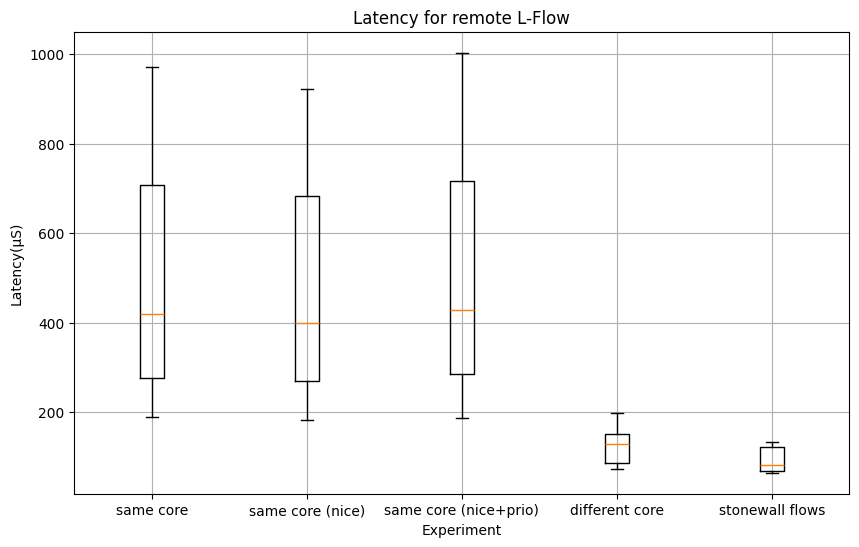

In [12]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
#plt.yscale("log")
plt.title('Latency for remote L-Flow')

[{'label': 'different core', 'whislo': 72.192, 'q1': 85.504, 'med': 127.488, 'q3': 150.528, 'whishi': 197.632, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 64.256, 'q1': 67.072, 'med': 81.408, 'q3': 122.368, 'whishi': 132.096, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

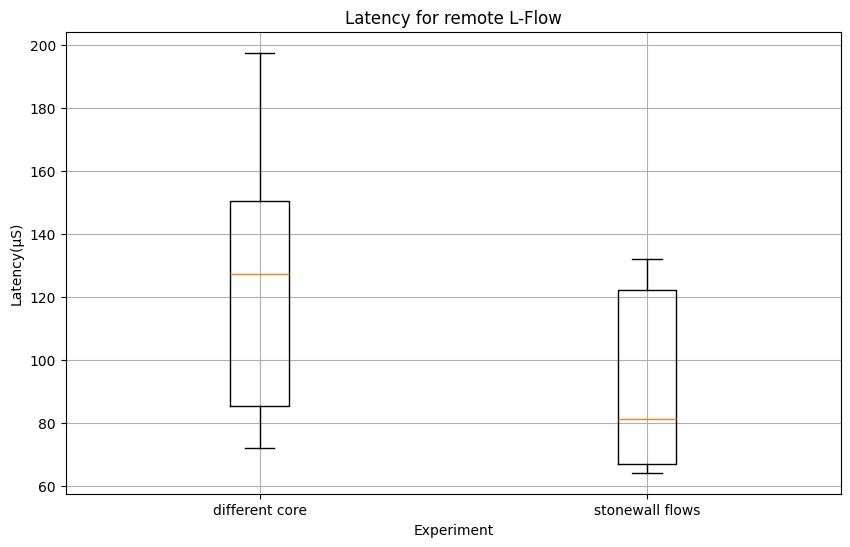

In [13]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
#plt.yscale("log")
plt.title('Latency for remote L-Flow')

Text(0.5, 1.0, 'IOPS bar graph for local T-Flow')

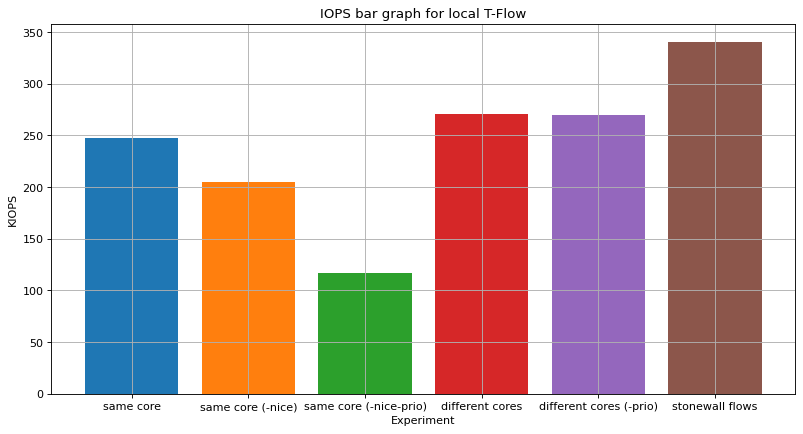

In [6]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("local_same_core_throughput","same core")
plot_iops_bar("local_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("local_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("local_diff_core_throughput","different cores")
plot_iops_bar("local_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("local_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for local T-Flow')


Text(0.5, 1.0, 'IOPS bar graph for remote T-Flow')

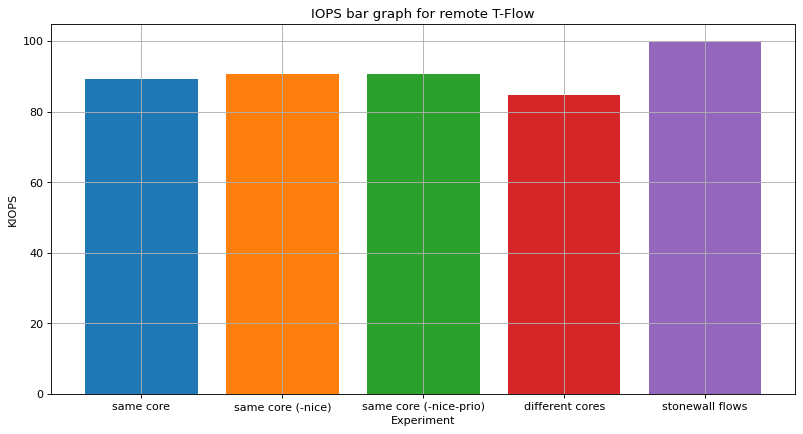

In [7]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("remote_same_core_throughput","same core")
plot_iops_bar("remote_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("remote_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("remote_diff_core_throughput","different cores")
#plot_iops_bar("remote_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("remote_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for remote T-Flow')


[{'label': 'same core', 'whislo': 13.12, 'q1': 13.504, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 13.12, 'q1': 13.376, 'med': 13.888, 'q3': 14.4, 'whishi': 15.936, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 13.12, 'q1': 13.376, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'different core', 'whislo': 14.272, 'q1': 15.68, 'med': 15.936, 'q3': 16.192, 'whishi': 17.024, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 14.528, 'q1': 15.68, 'med': 15.936, 'q3': 16.192, 'whishi': 16.768, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 14.272, 'q1': 15.296, 'med': 15.552, 'q3': 15.936, 'whishi': 16.512, 'fliers': []}]


Text(0.5, 1.0, 'Latency for no shared storage local L-Flow')

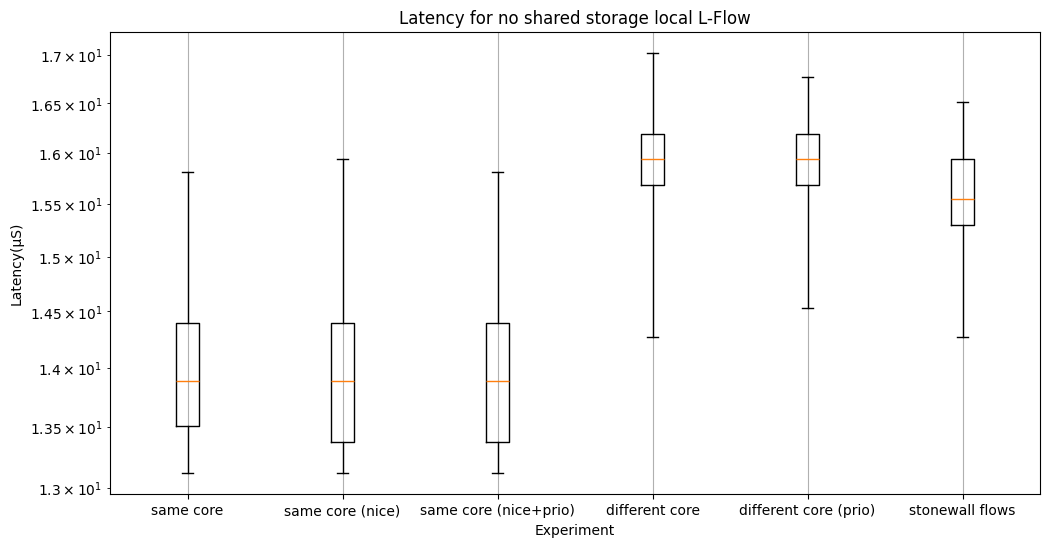

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)


plot_lat_bar("local_ns_same_core_latency","same core", ax, 0)
plot_lat_bar("local_ns_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_ns_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_ns_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_ns_prio_diff_core_latency","different core (prio)", ax, 4)
#plot_lat_bar("local_same_stonewall_latency","stonewall flows (same)", ax, 5)
plot_lat_bar("local_ns_stonewall_latency", "stonewall flows", ax, 5)
plt.yscale("log")
plt.title('Latency for no shared storage local L-Flow')

[{'label': 'same core', 'whislo': 569.344, 'q1': 724.992, 'med': 806.912, 'q3': 929.792, 'whishi': 1187.84, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 399.36, 'q1': 651.264, 'med': 749.568, 'q3': 847.872, 'whishi': 1073.152, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 387.072, 'q1': 651.264, 'med': 741.376, 'q3': 847.872, 'whishi': 1073.152, 'fliers': []}]
[{'label': 'different core', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.088, 'whishi': 64.256, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 48.896, 'q1': 50.944, 'med': 52.48, 'q3': 56.576, 'whishi': 64.768, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

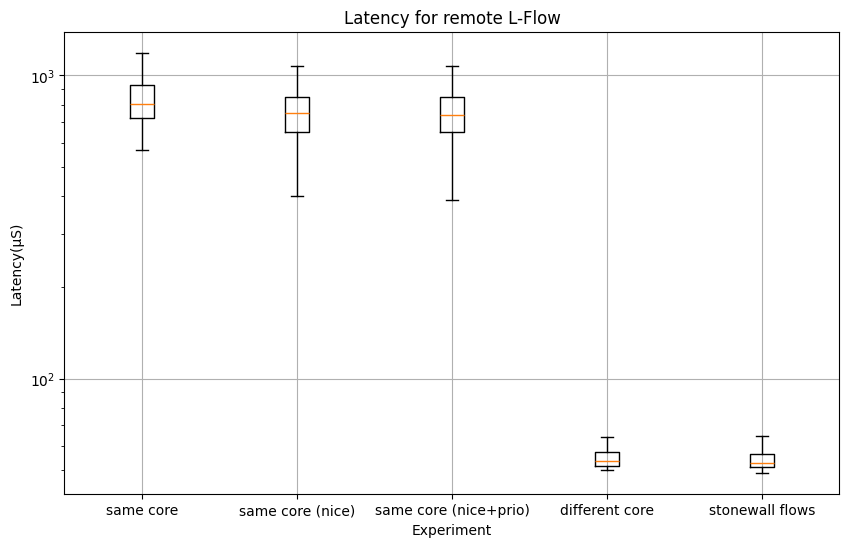

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_ns_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_ns_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_ns_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_ns_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_ns_stonewall_latency","stonewall flows", ax, 4)
plt.yscale("log")
plt.title('Latency for remote L-Flow')

[{'label': 'Shared compute only', 'whislo': 13.12, 'q1': 13.504, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'Shared storage and compute', 'whislo': 11.968, 'q1': 12.736, 'med': 14.528, 'q3': 20.096, 'whishi': 62.208, 'fliers': []}]


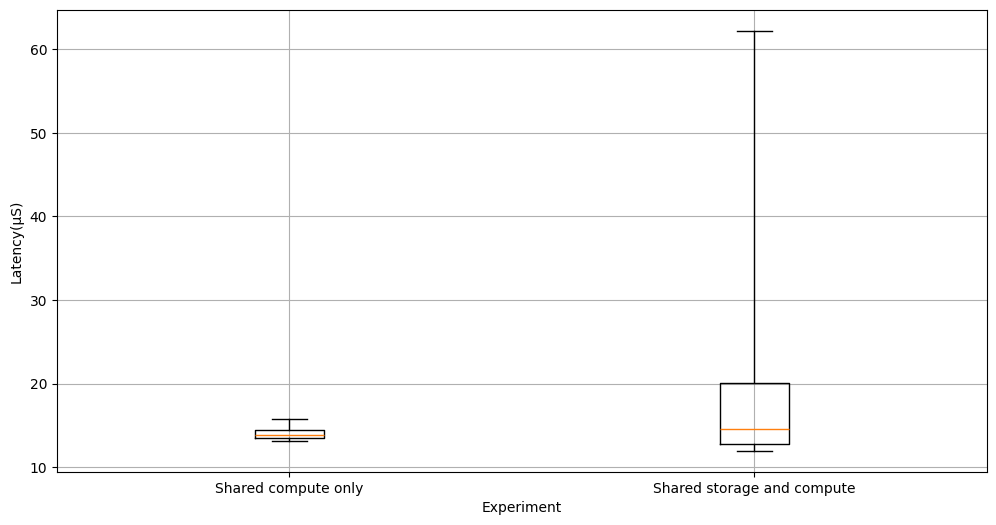

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("local_ns_same_core_latency","Shared compute only", ax, 0)
plot_lat_bar("local_same_core_latency","Shared storage and compute", ax, 1)

[{'label': 'Shared compute and network', 'whislo': 569.344, 'q1': 724.992, 'med': 806.912, 'q3': 929.792, 'whishi': 1187.84, 'fliers': []}]
[{'label': 'Shared storage, network and compute', 'whislo': 148.48, 'q1': 280.576, 'med': 602.112, 'q3': 798.72, 'whishi': 1056.768, 'fliers': []}]


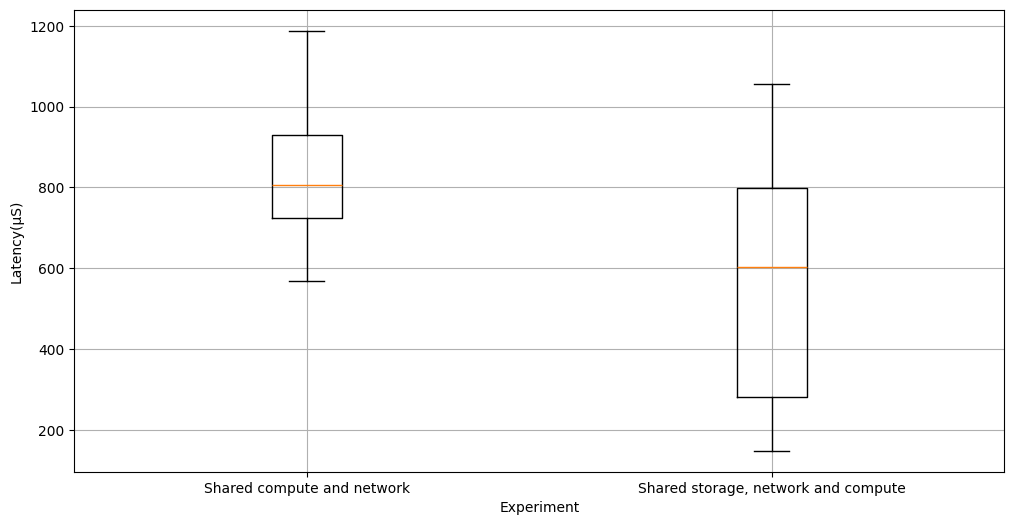

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("remote_ns_same_core_latency","Shared compute and network", ax, 0)
plot_lat_bar("remote_same_core_latency","Shared storage, network and compute", ax, 1)

[{'label': 'Shared network only', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.088, 'whishi': 64.256, 'fliers': []}]
[{'label': 'Shared storage and network', 'whislo': 51.968, 'q1': 54.528, 'med': 58.112, 'q3': 65.28, 'whishi': 98.816, 'fliers': []}]


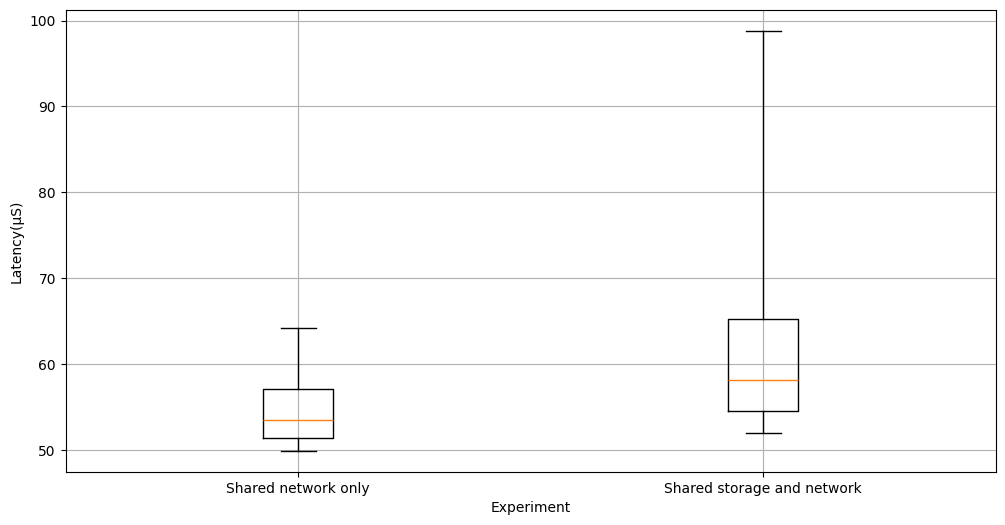

In [13]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("remote_ns_diff_core_latency","Shared network only", ax, 0)
plot_lat_bar("remote_diff_core_latency","Shared storage and network", ax, 1)

In [4]:
fp = open("./performance/crunched_numbers_performance.json")
op = json.load(fp)

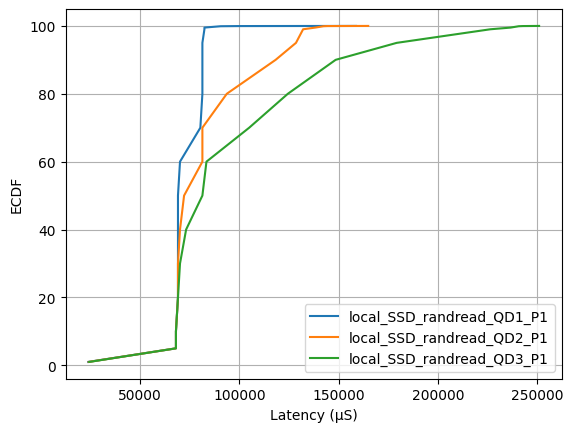

In [6]:
plot_lat_percentile("local_SSD_randread_QD1_P1")
plot_lat_percentile("local_SSD_randread_QD2_P1")
plot_lat_percentile("local_SSD_randread_QD3_P1")

[{'label': 'QD1', 'whislo': 68.096, 'q1': 69.12, 'med': 69.12, 'q3': 81.408, 'whishi': 81.408, 'fliers': []}]
[{'label': 'QD2', 'whislo': 68.096, 'q1': 69.12, 'med': 72.192, 'q3': 93.696, 'whishi': 128.512, 'fliers': []}]
[{'label': 'QD3', 'whislo': 68.096, 'q1': 69.12, 'med': 81.408, 'q3': 124.416, 'whishi': 179.2, 'fliers': []}]


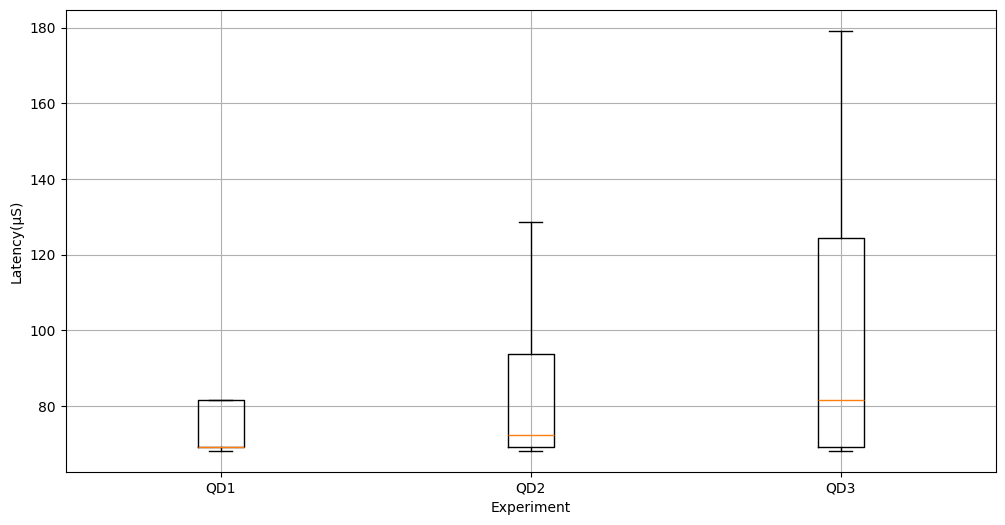

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("local_SSD_randread_QD1_P1","QD1",ax,0)
plot_lat_bar("local_SSD_randread_QD2_P1","QD2",ax,1)
plot_lat_bar("local_SSD_randread_QD3_P1","QD3",ax,2)

In [7]:
fp = open("./network/crunched_numbers.json")
op = json.load(fp)

4KB [1.217493372997897, 2.4065616664501097, 4.493486480763976, 7.594380877488612]
8KB [1.6628541218200819, 3.261855658635338, 5.944796711769821, 8.336409292688108]
16KB [2.0585520169567038, 4.039250133872504, 6.881880087921808, 8.535547273838253]
32KB [2.3262586855171086, 4.440473484677523, 7.513293588906342, 8.594807495691766]
64KB [2.5582125880428768, 4.884044976962366, 7.92601893775299, 8.633697670039185]


Text(0.5, 0, 'Number of parallel connection(s)')

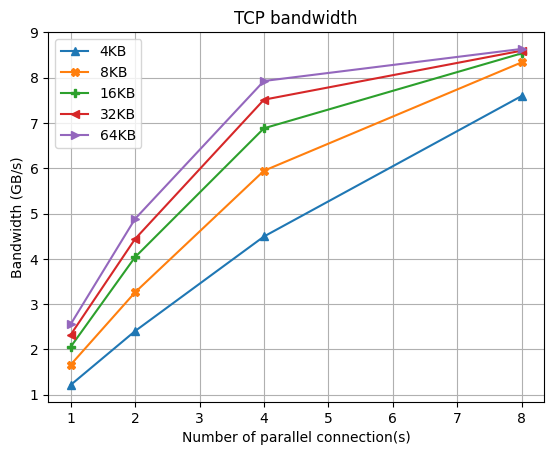

In [12]:
for i in ["4","8","16","32","64"]:
    experiments = []
    for j in [1, 2, 4, 8]:
        experiments.append("qemu_tcpbw_S{}_{}".format(j,i))
    plot_net_line(experiments, "bw", [1, 2, 4, 8], "{}KB".format(i))
plt.legend()
plt.title("TCP bandwidth")
plt.ylabel("Bandwidth (GB/s)")
plt.xlabel("Number of parallel connection(s)")

qemu_s2c_tcpbw_S8_1024
qemu_c2s_tcpbw_S8_1024
host_s2c_tcpbw_S8_1024
host_c2s_tcpbw_S8_1024
GB/s :  {'qemu_s2c': 11.111800244525895, 'qemu_c2s': 10.526995441099558, 'host_s2c': 4.6940426618090285, 'host_c2s': 4.893712785578596}


Text(0.5, 1.0, 'TCP bandwidth')

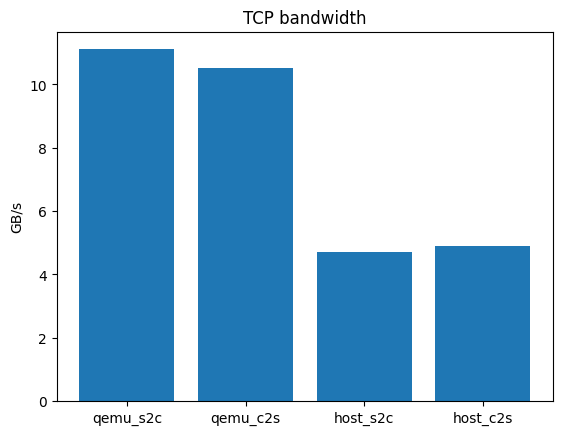

In [20]:
node = ["qemu", "host"]
direction = ["s2c","c2s"]
msg = ["4","64","256","512","1024"]
streams = [1, 2, 3, 4, 5, 6, 7, 8]

max_bw_test = {}
for i in node:
    for j in direction:
        max_bw = 0
        max_exp = ""
        for a in msg:
            for b in streams:
                exp = "{}_{}_tcpbw_S{}_{}".format(i,j,b,a)
                if op[exp]["bw"] > max_bw:
                    max_bw = op[exp]["bw"]
                    max_exp = exp
        max_bw_test["{}_{}".format(i,j)] = max_bw
        print(exp)
print("GB/s : ", max_bw_test)
x = max_bw_test.keys()
plt.bar(x, [max_bw_test[i] for i in x])
plt.ylabel("GB/s")
plt.title("TCP bandwidth")

In [9]:
max_rt_test = {}
for i in node:
    for j in direction:
        max_bw = 0
        rt = 0
        for a in msg:
            for b in streams:
                exp = "{}_{}_tcpbw_S{}_{}".format(i,j,b,a)
                if op[exp]["bw"] > max_bw:
                    max_bw = op[exp]["bw"]
                    rt = op[exp]["rt"]
        max_rt_test["{}_{}".format(i,j)] = rt
print("Retries : ", max_rt_test)

Retries :  {'qemu_s2c': 3124, 'qemu_c2s': 5546, 'host_s2c': 0, 'host_c2s': 0}


In [12]:
max_rt_test = {}
for i in node:
    for j in direction:
        max_bw = 0
        rt = 0
        for a in msg:
            for b in streams:
                exp = "{}_{}_tcpbw_S{}_{}".format(i,j,b,a)
                if op[exp]["bw"] > max_bw:
                    max_bw = op[exp]["bw"]
                    rt = op[exp]["avg_win"] / (1024)**2
        max_rt_test["{}_{}".format(i,j)] = rt
print("Window size (MB) : ", max_rt_test)

Window size (MB) :  {'qemu_s2c': 0.0, 'qemu_c2s': 3.8656654357910156, 'host_s2c': 0.0, 'host_c2s': 3.0379180908203125}


Text(0, 0.5, 'Latency(μS)')

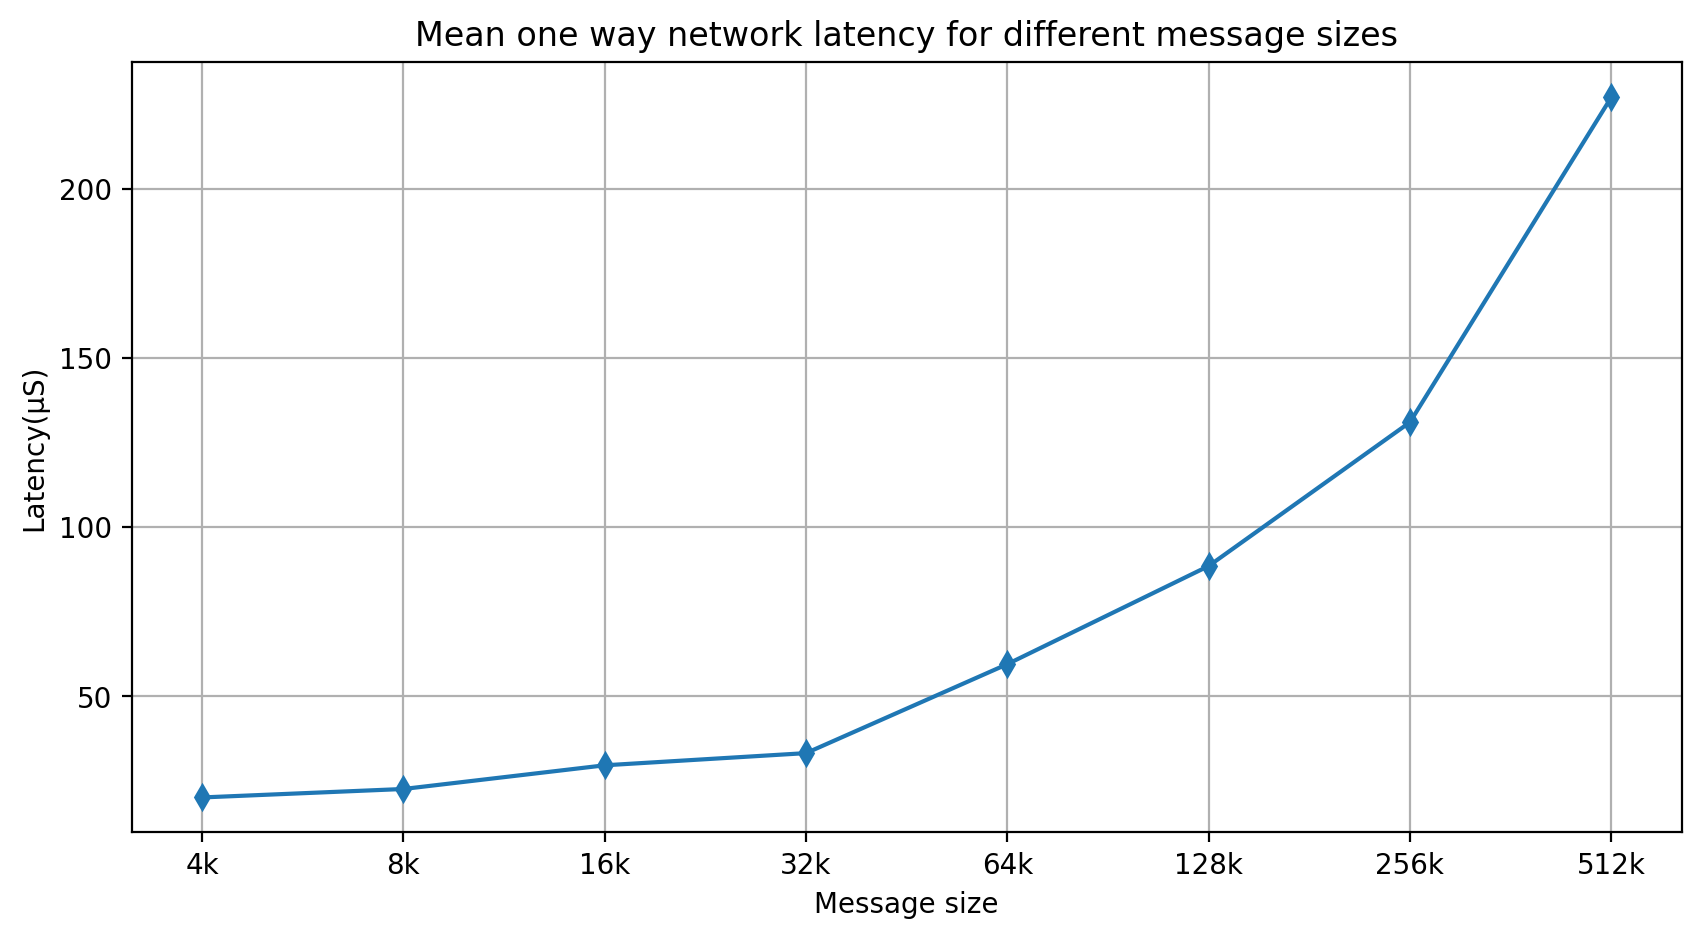

In [4]:
#In micro seconds
lat = {
    "4k" : 20.1,
    "8k" : 22.6,
    "16k" : 29.6,
    "32k" : 33.2,
    "64k" : 59.5,
    "128k" : 88.5,
    "256k": 131,
    "512k" : 227,
}
x = []
y = []
for i in lat.keys():
    x.append(i)
    y.append(lat[i])

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
global CALLS
CALLS=0
mark = MARKERS[CALLS]
CALLS = (CALLS + 1)%len(MARKERS)
plt.plot(x,y,'-'+mark)
plt.title("Mean one way network latency for different message sizes")
plt.xlabel("Message size")
plt.grid(True)
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')

Text(0, 0.5, 'Latency(μS)')

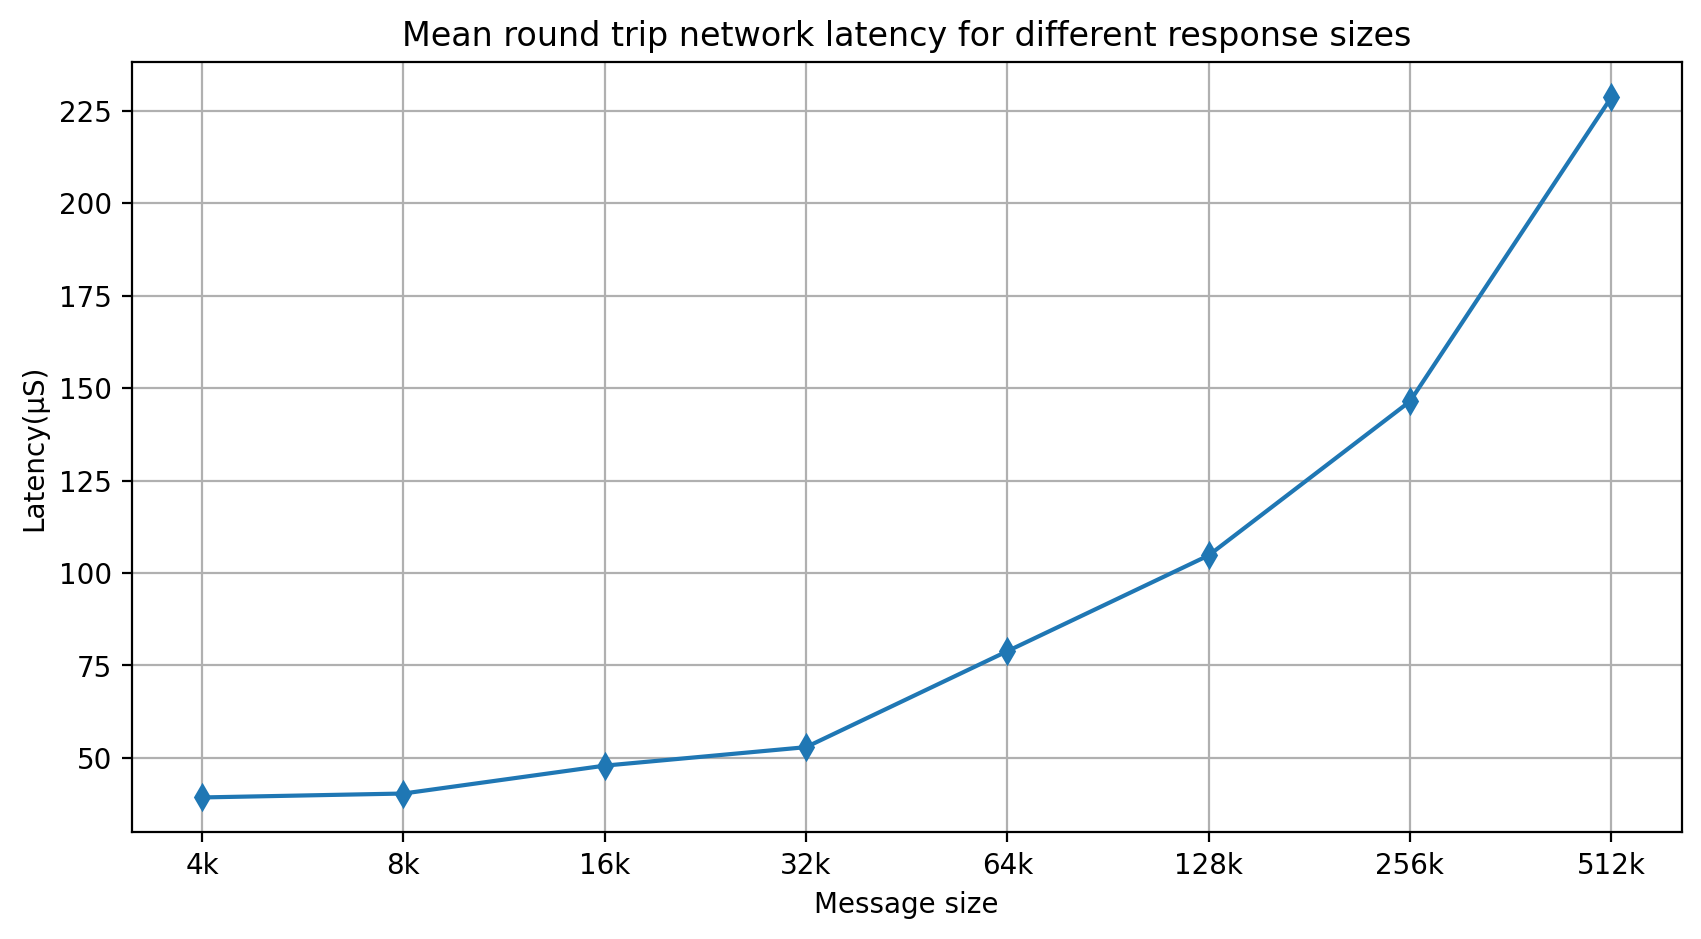

In [3]:
#In micro seconds
lat = {
    "4k" : 39.31,
    "8k" : 40.37,
    "16k" : 47.91,
    "32k" : 52.91,
    "64k" : 78.86,
    "128k" : 104.77,
    "256k": 146.41,
    "512k" : 228.62,
}
x = []
y = []
for i in lat.keys():
    x.append(i)
    y.append(lat[i])

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
global CALLS
CALLS=0
mark = MARKERS[CALLS]
CALLS = (CALLS + 1)%len(MARKERS)
plt.plot(x,y,'-'+mark)
plt.title("Mean round trip network latency for different response sizes")
plt.xlabel("Message size")
plt.grid(True)
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')

Text(0, 0.5, 'Latency(μS)')

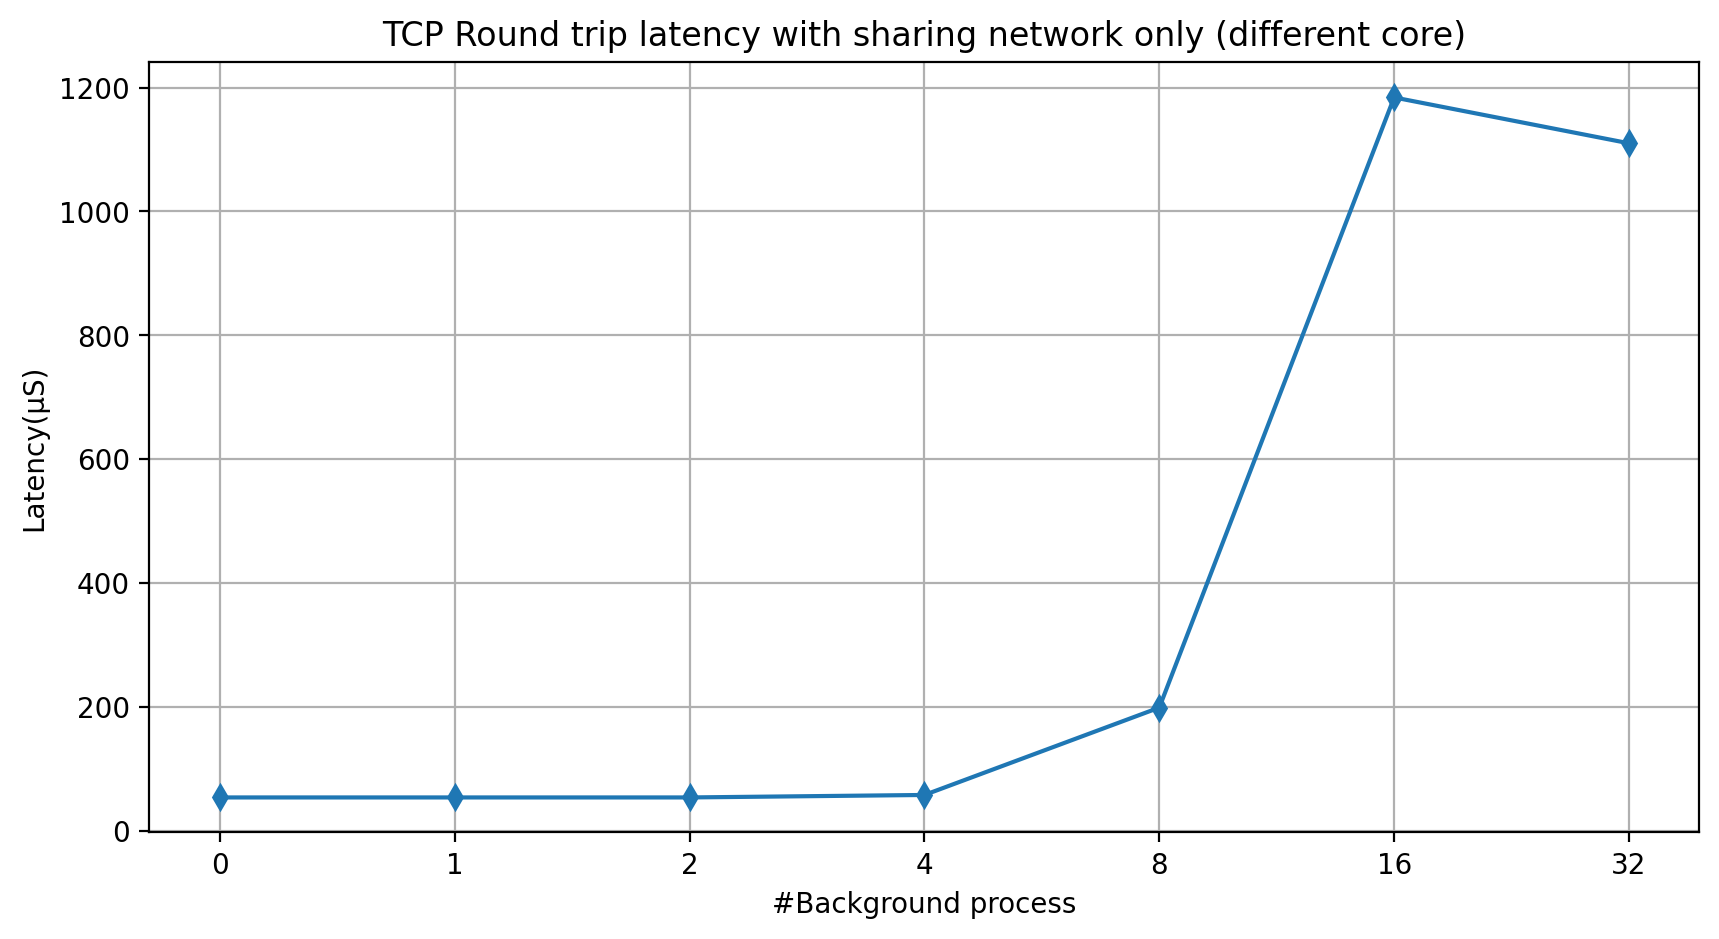

In [6]:
"""
BG flow count 0
42.22        
BG flow count 1
45.70        
BG flow count 2
66.59        
BG flow count 4
118.97       
BG flow count 8
361.76     
"""  
#In micro seconds
lat4k = {
    "0" : 54,
    "1" : 54,
    "2": 54,
    "4": 58,
    "8": 199,
    "16": 1184,
    "32": 1110,
}

"""
lat64k = {
  "0" : 42.22,
  "1" : 54,
  "2": 54,
  "4": 58,
  "8": 199,
  "16": 1184,
  "32": 1110,
}
"""

x1 = []
y1 = []
for i in lat4k.keys():
    x1.append(i)
    y1.append(lat4k[i])
"""
x2 = []
y2 = []
for i in lat64k.keys():
    x2.append(i)
    y2.append(lat64k[i])
"""

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
global CALLS
CALLS=0
mark = MARKERS[CALLS]
CALLS = (CALLS + 1)%len(MARKERS)
plt.plot(x1,y1,'-'+mark, label="4k")
mark = MARKERS[CALLS]
CALLS = (CALLS + 1)%len(MARKERS)
#plt.plot(x2,y2,'-'+mark, label="64k")
plt.title("TCP Round trip latency with sharing network only (different core)")
plt.xlabel("#Background process")
plt.grid()
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')

In [6]:
f = open("qos/crunched_numbers_qos.json")
op = json.load(f)

4k 99 [134.144, 136.192, 136.192, 137.55733333333333, 185.344, 213.33333333333334, 280.576]
64k 99 [134.144, 138.24, 138.92266666666666, 139.60533333333333, 139.60533333333333, 139.60533333333333, 140.288]


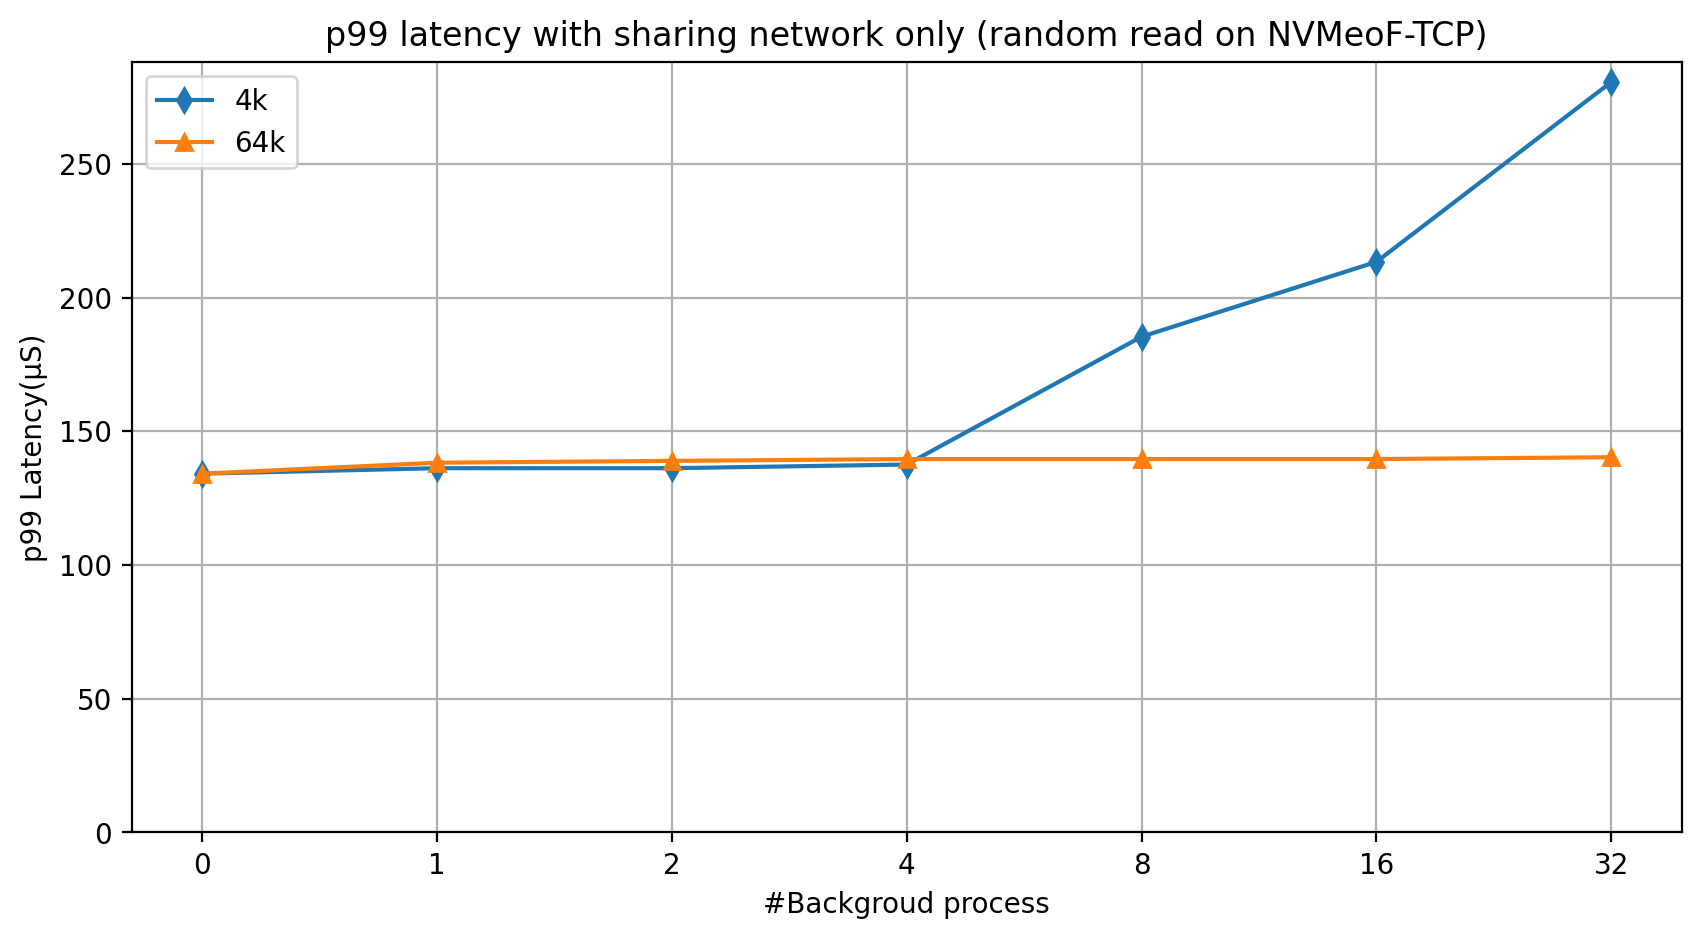

In [4]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing network only (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.ylim(0)
plt.legend()

4k 99 [134.144, 134.144, 134.144, 134.144, 156.672, 214.016, 179.2]
64k 99 [132.096, 138.24, 138.24, 136.192, 138.24, 140.288, 138.24]


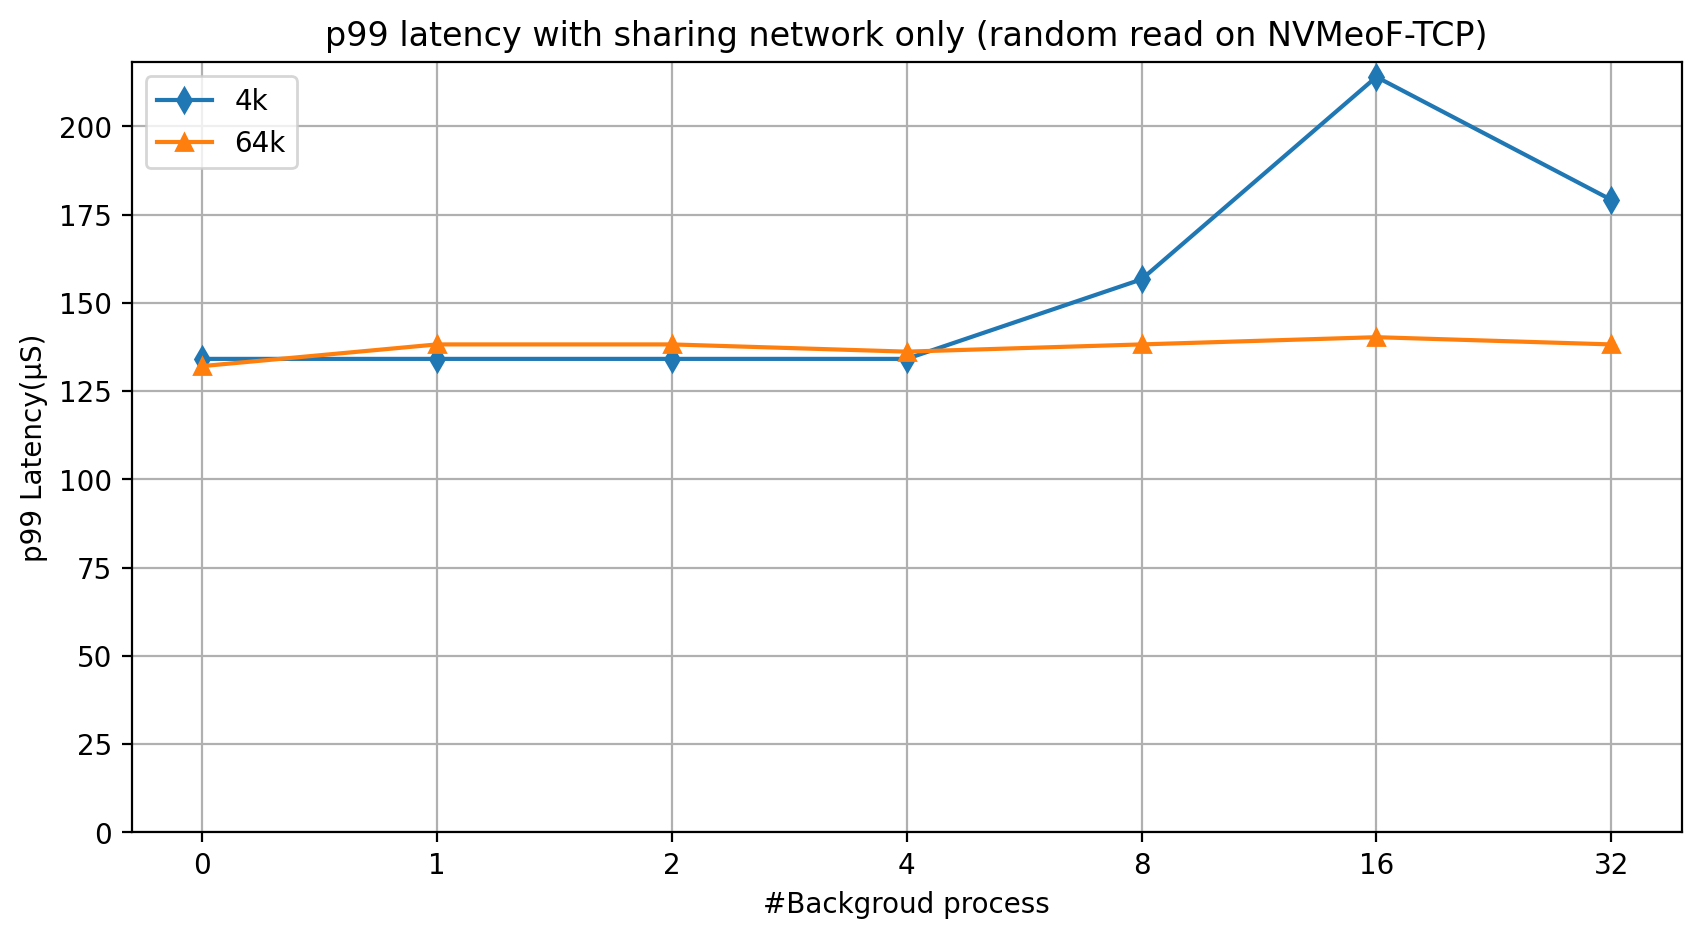

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_split_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing network only (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.ylim(0)
plt.legend()

4k 99 [140.288, 138.24, 136.192, 142.336, 995.328, 189.44, 187.392]


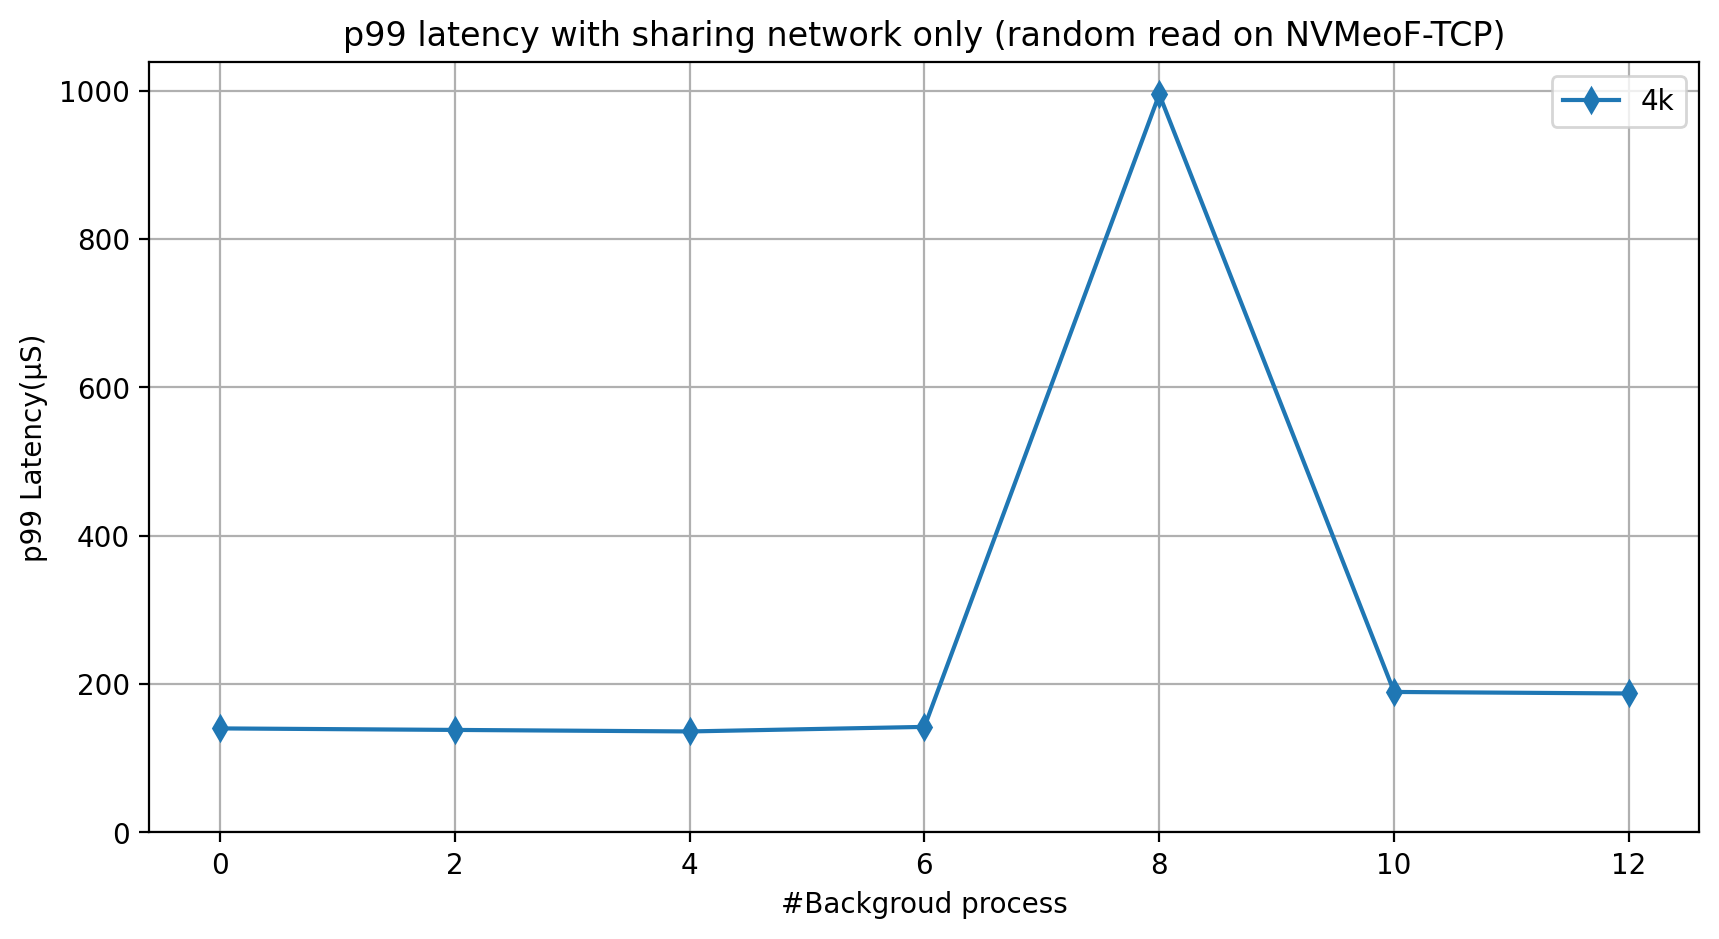

In [36]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k"]:
    experiments=[]
    for i in [0, 2, 4,6, 8, 10, 12]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 2, 4, 6, 8, 10, 12], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing network only (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.ylim(0)
plt.legend()

4k [1793.7, 1761.9, 1665.50004, 1651.29996, 1474.89996, 1401.50004, 1481.8999199999998]
64k [1813.9000800000001, 1620.9999599999999, 1606.40004, 1545.09996, 1540.8999600000002, 1559.20008, 1540.1000399999998]


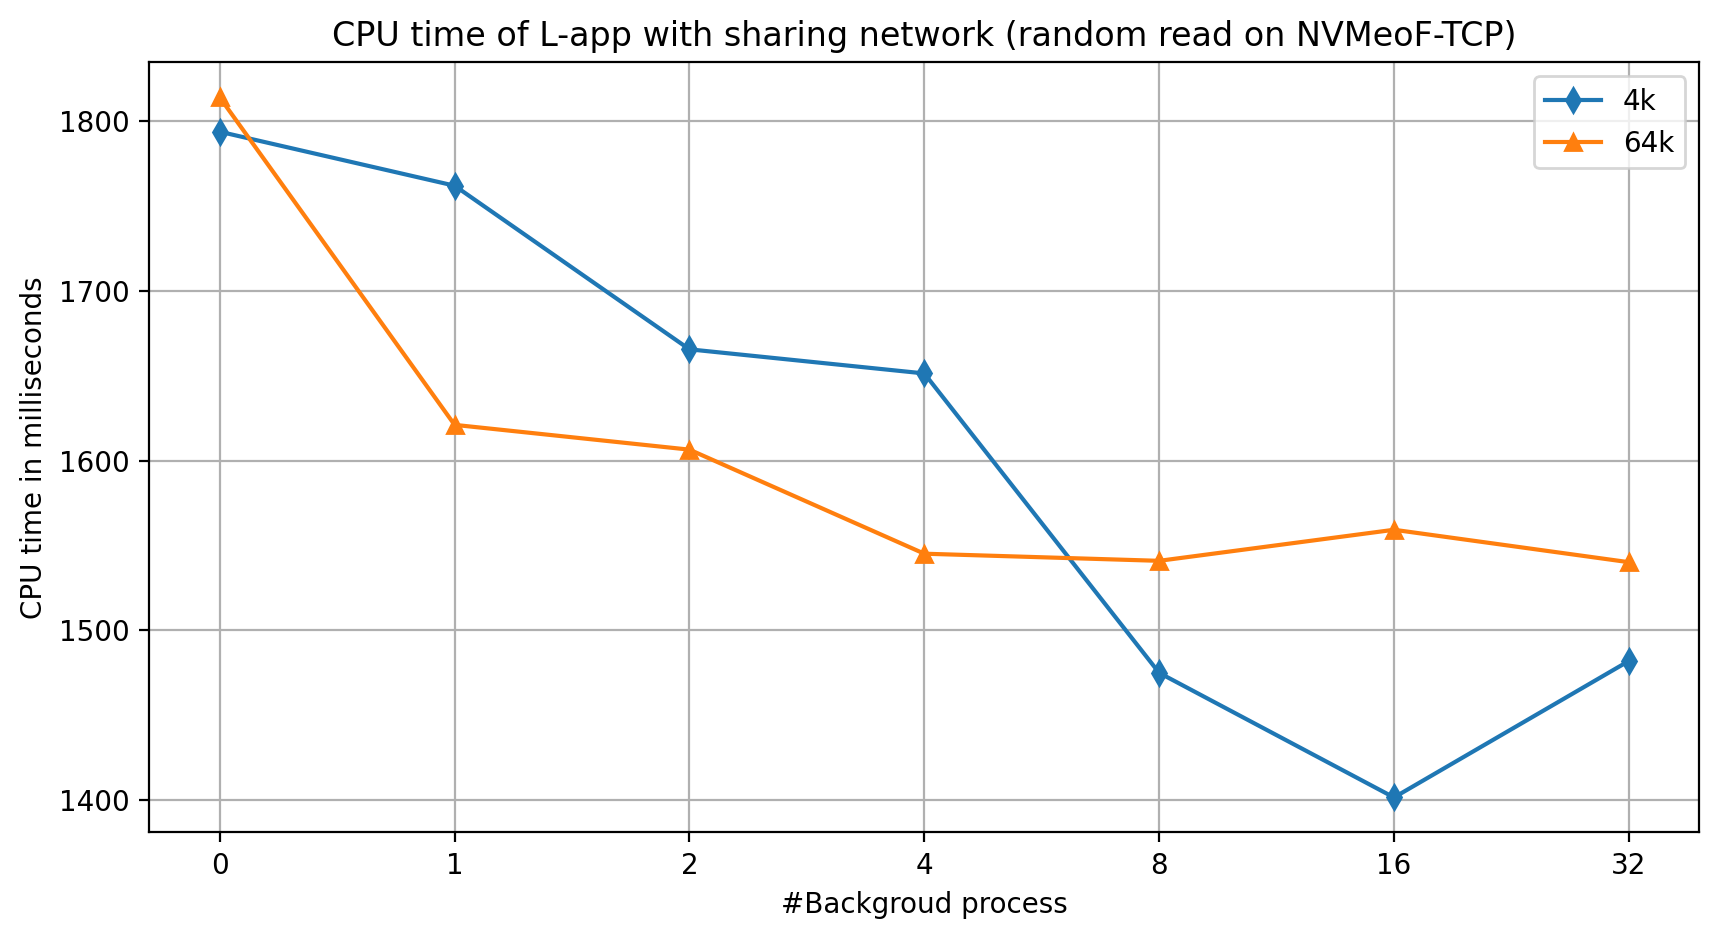

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_run_time(experiments, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('CPU time of L-app with sharing network (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('CPU time in milliseconds')
plt.grid(True)
plt.legend()

remote_ID_TD_SD_bread_fread_SSD_BP0_BS4k_latency
remote_ID_TD_SD_bread_fread_SSD_BP1_BS4k_latency
remote_ID_TD_SD_bread_fread_SSD_BP2_BS4k_latency
remote_ID_TD_SD_bread_fread_SSD_BP4_BS4k_latency
remote_ID_TD_SD_bread_fread_SSD_BP8_BS4k_latency
remote_ID_TD_SD_bread_fread_SSD_BP16_BS4k_latency
remote_ID_TD_SD_bread_fread_SSD_BP32_BS4k_latency
4k [2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0]
remote_ID_TD_SD_bread_fread_SSD_BP0_BS64k_latency
remote_ID_TD_SD_bread_fread_SSD_BP1_BS64k_latency
remote_ID_TD_SD_bread_fread_SSD_BP2_BS64k_latency
remote_ID_TD_SD_bread_fread_SSD_BP4_BS64k_latency
remote_ID_TD_SD_bread_fread_SSD_BP8_BS64k_latency
remote_ID_TD_SD_bread_fread_SSD_BP16_BS64k_latency
remote_ID_TD_SD_bread_fread_SSD_BP32_BS64k_latency
64k [2.0, 2.0, 3.0, 2.0, 2.0, 3.0, 2.0]


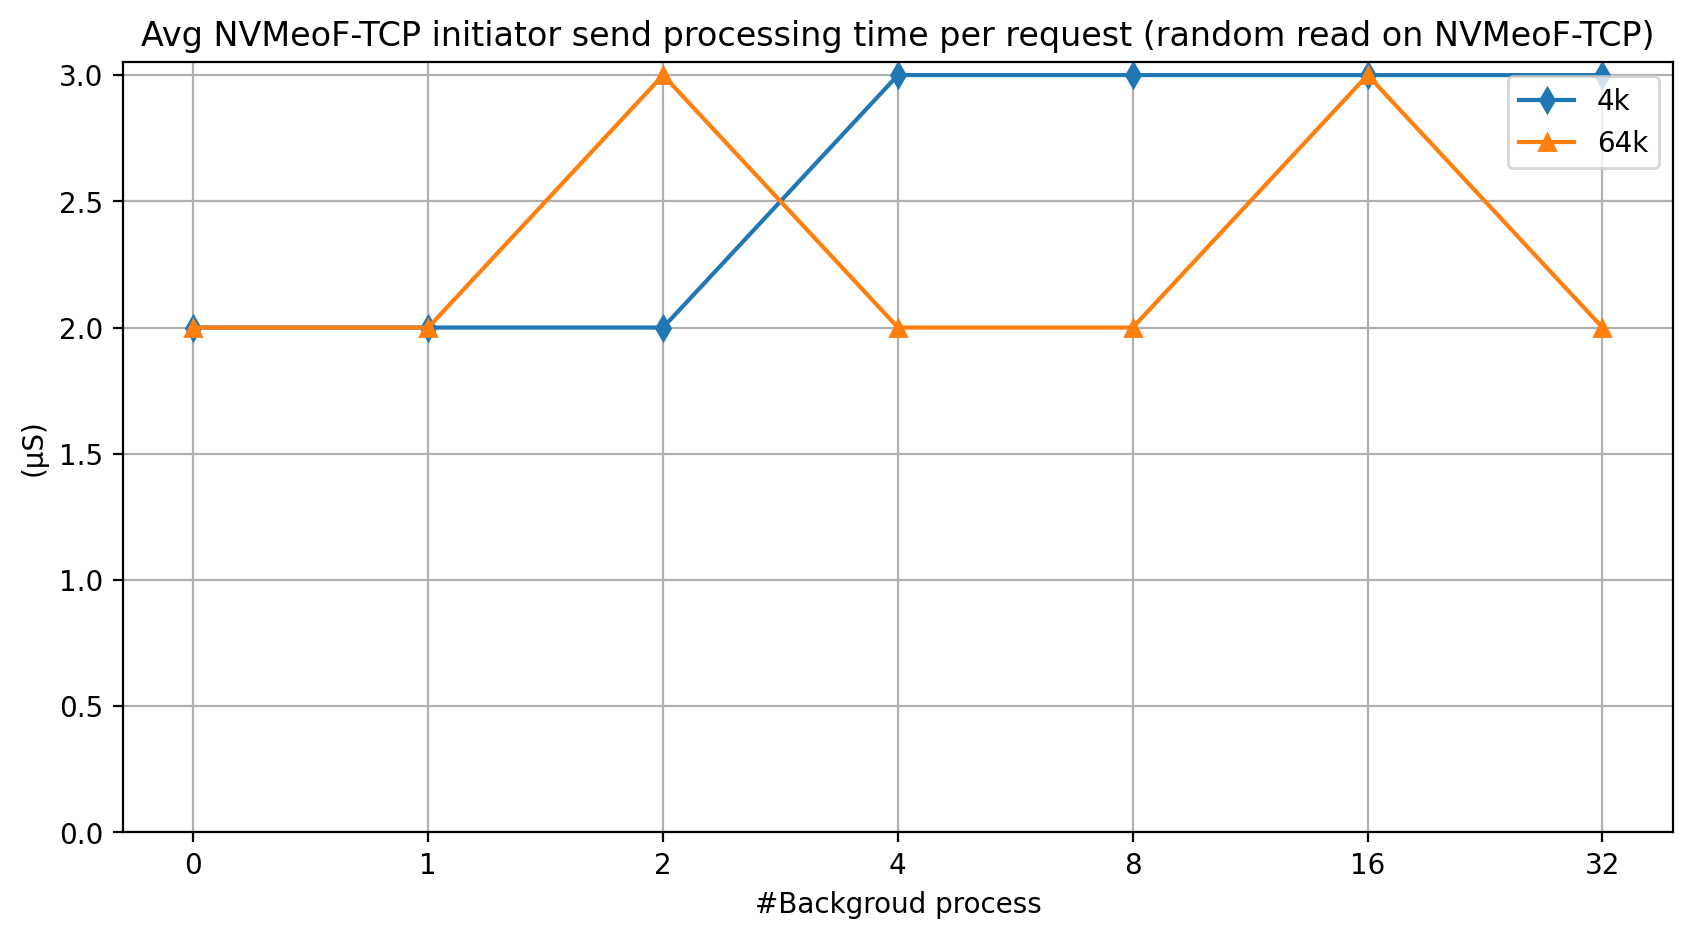

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_init_rp_time(experiments, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Avg NVMeoF-TCP initiator send processing time per request (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('(' + u"\u03bc"+ 'S)')
plt.grid(True)
plt.ylim(0)
plt.legend()

4k [49.0, 49.0, 49.0, 49.0, 52.0, 54.0, 54.0]
64k [49.0, 49.0, 49.0, 50.0, 50.0, 50.0, 50.0]


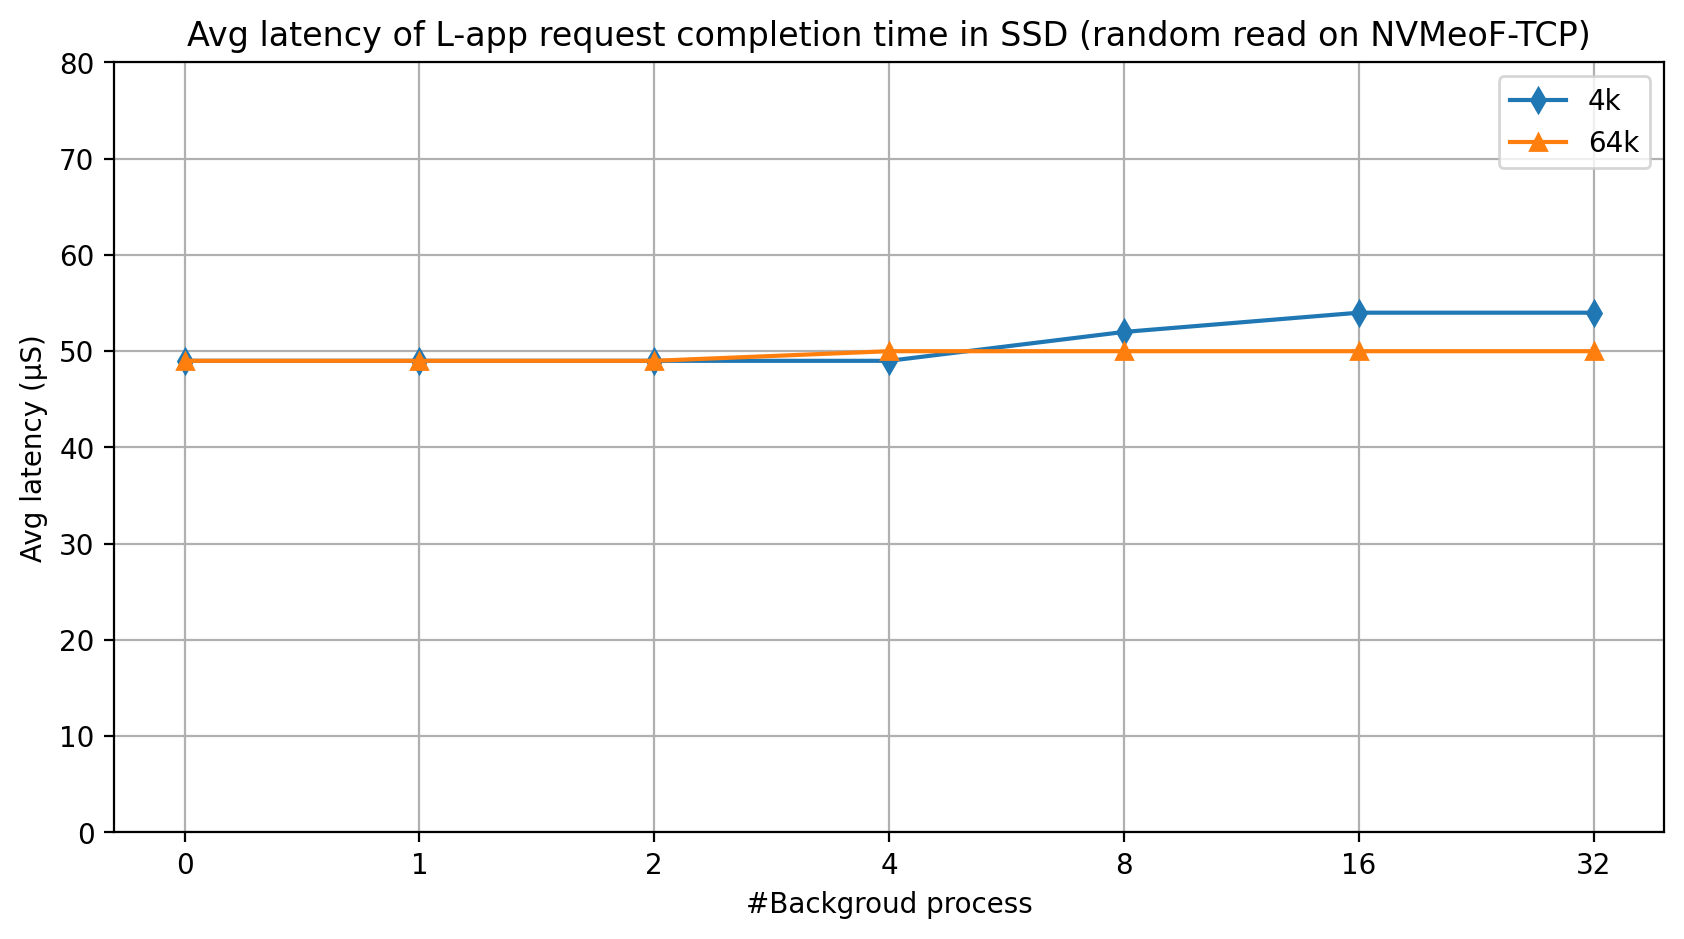

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_target_blk_time(experiments, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Avg latency of L-app request completion time in SSD (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('Avg latency (' + u"\u03bc"+ 'S)')
plt.grid(True)
plt.ylim(0,80)
plt.legend()

4k [0.1935963328968684, 0.39203879894701643, 0.9001048333584468, 1.6642642493365607, 1.6949720781723656, 1.7340923945121762]
64k [0.9990759388004941, 1.6547375952018102, 1.7039842029603323, 1.7099337883857089, 1.712173597738266, 1.71216913824749]


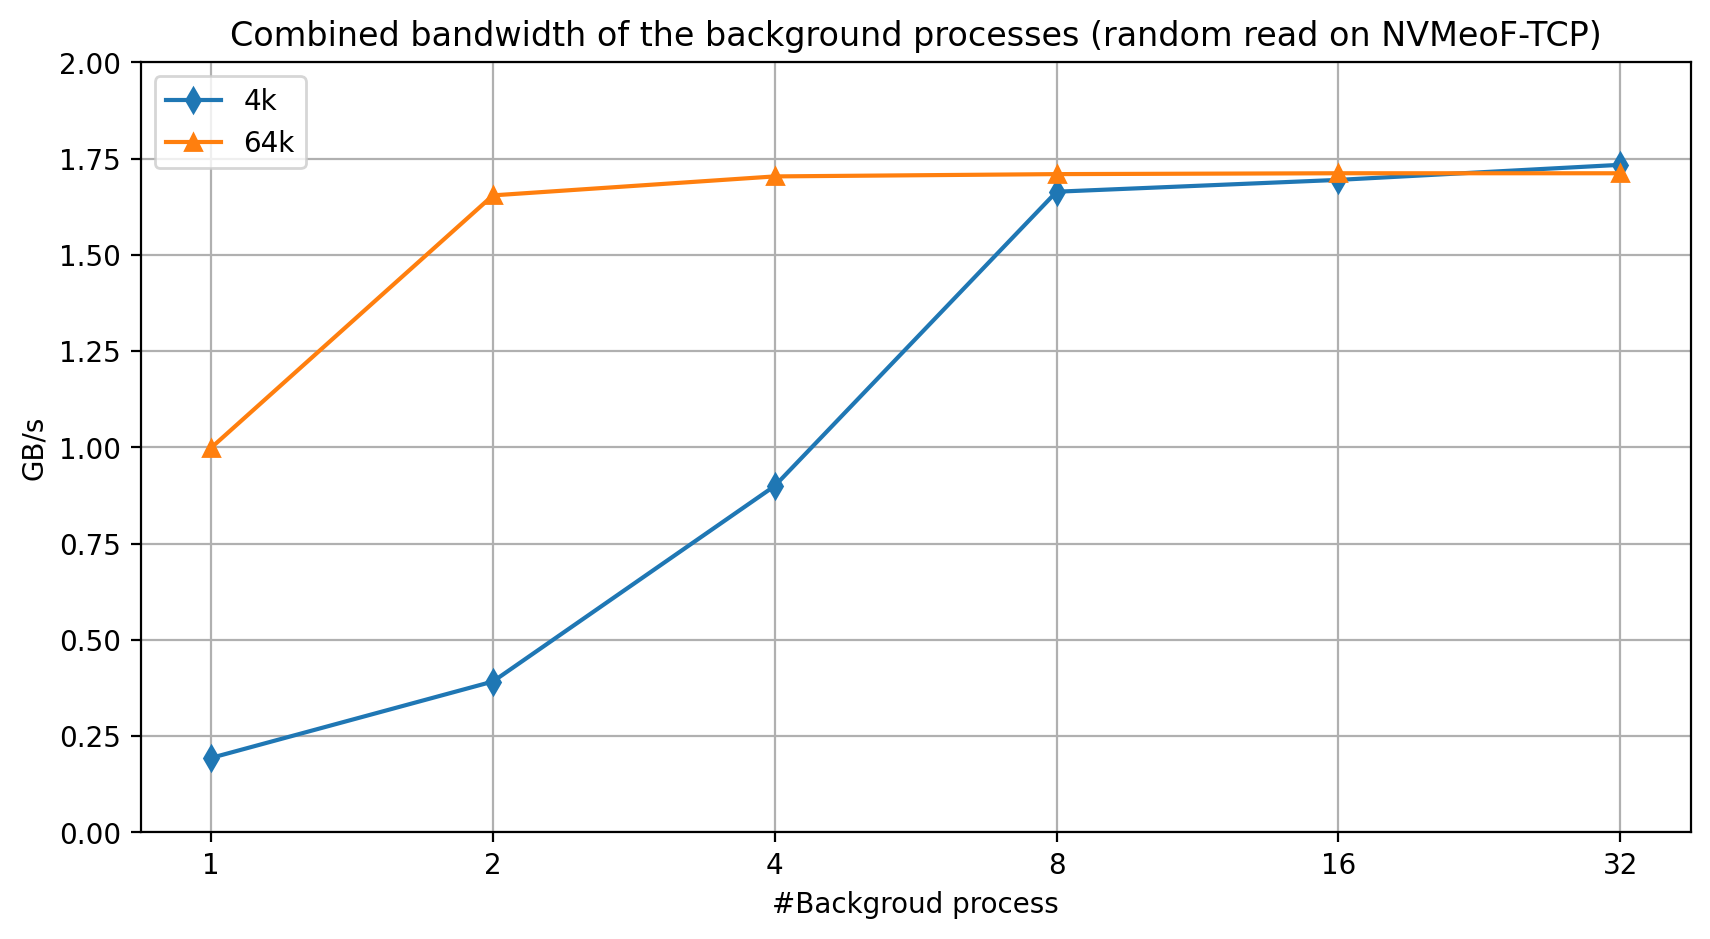

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_throughput".format(i, j))
    plot_bw_line(experiments, [1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Combined bandwidth of the background processes (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylim(0,2)
plt.legend()

4k [0.7901164412498474, 1.5113551965818406, 1.7567396124038697, 1.7555514618921277, 1.740349135139465, 1.7444635654592515]


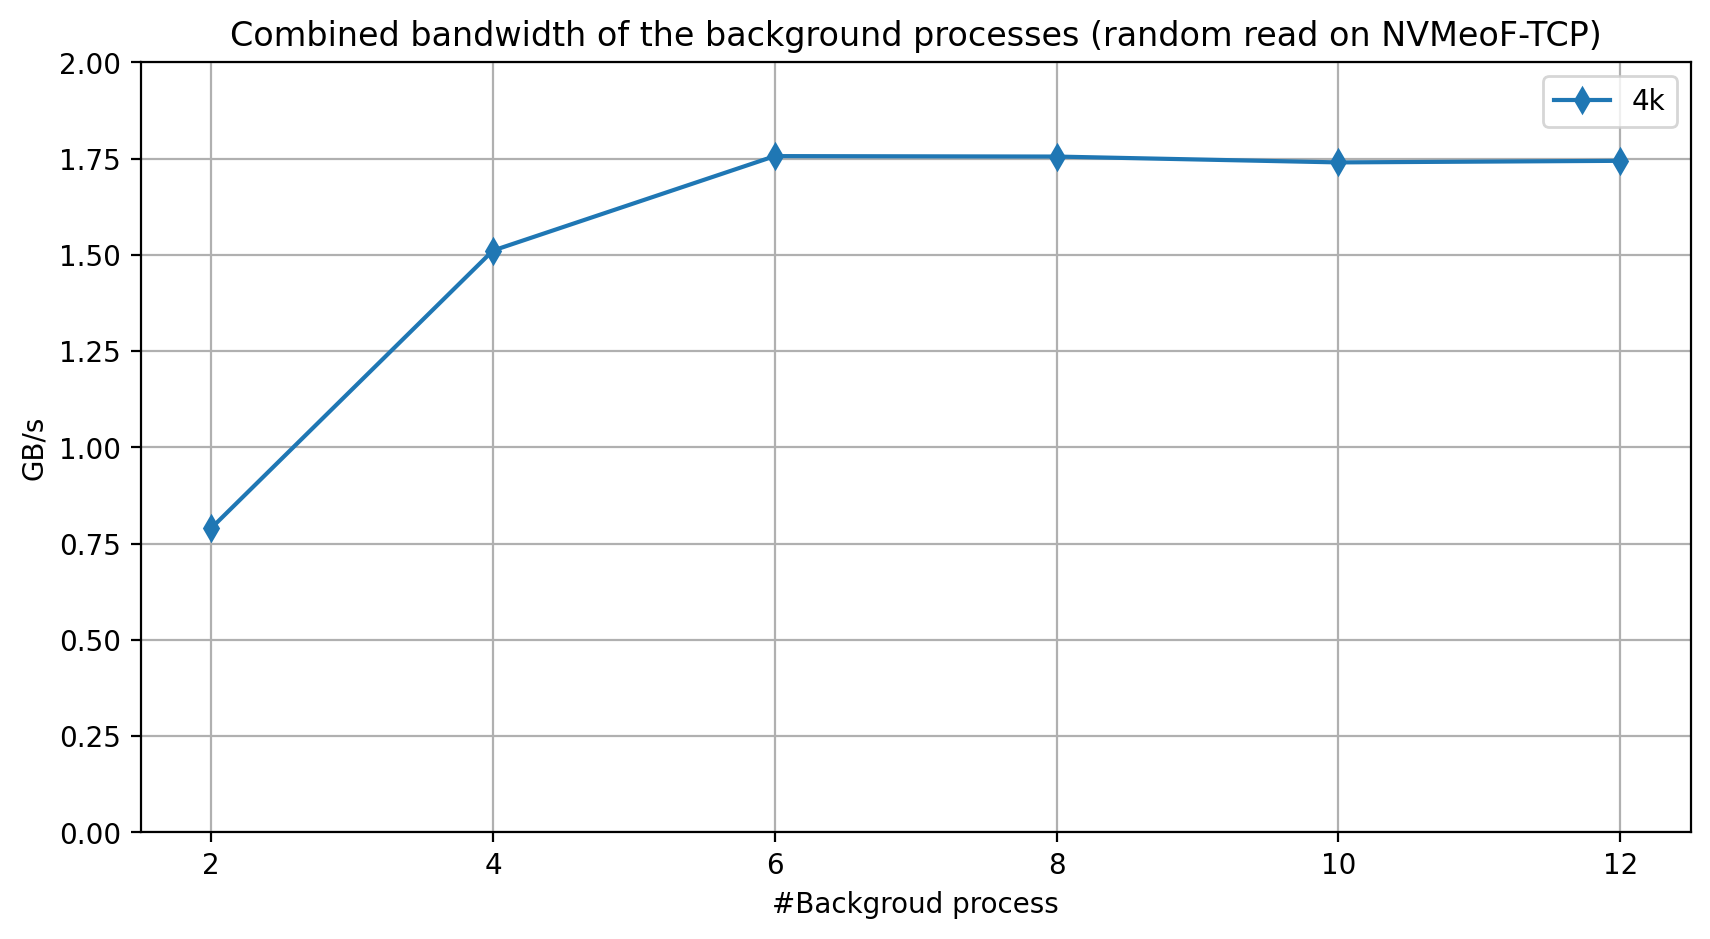

In [39]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k"]:
    experiments=[]
    for i in [2, 4, 6, 8, 10, 12]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_throughput".format(i, j))
    plot_bw_line(experiments, [2, 4, 6, 8, 10, 12], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Combined bandwidth of the background processes (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylim(0,2)
plt.legend()

4k [50.203740586, 57.774115759999994, 64.58343765699999, 51.12233147366666, 27.086048486352944, 13.879524026757576]
64k [11.935328452, 9.356216178333334, 5.6147715482, 3.1179286437777773, 1.6510738431764704, 0.8505890706363636]


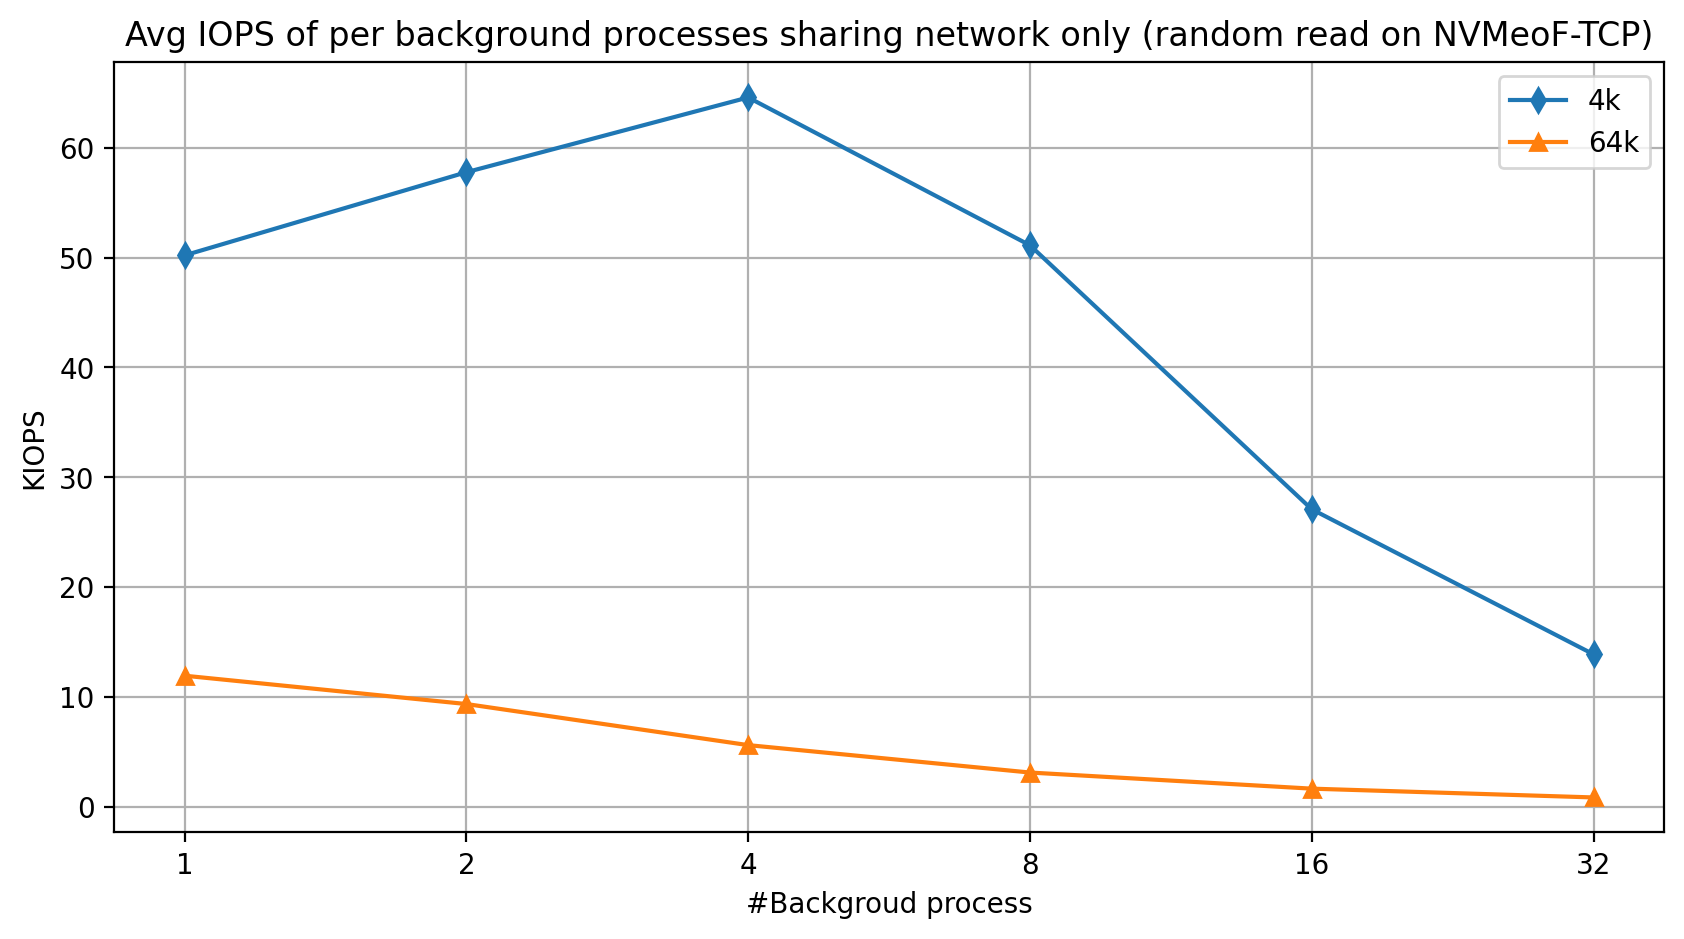

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SD_bread_fread_SSD_BP{}_BS{}_throughput".format(i, j))
    plot_iops_across_line(experiments, [1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Avg IOPS of per background processes sharing network only (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel("KIOPS")
plt.legend()

4k 99 [138.24, 153.25866666666667, 224.93866666666665, 266.9226666666667, 700.416, 1466.368, 2757.9733333333334]
64k 99 [138.92266666666666, 957.0986666666666, 752.2986666666666, 333.824, 274.09066666666666, 306.51733333333334, 329.728]


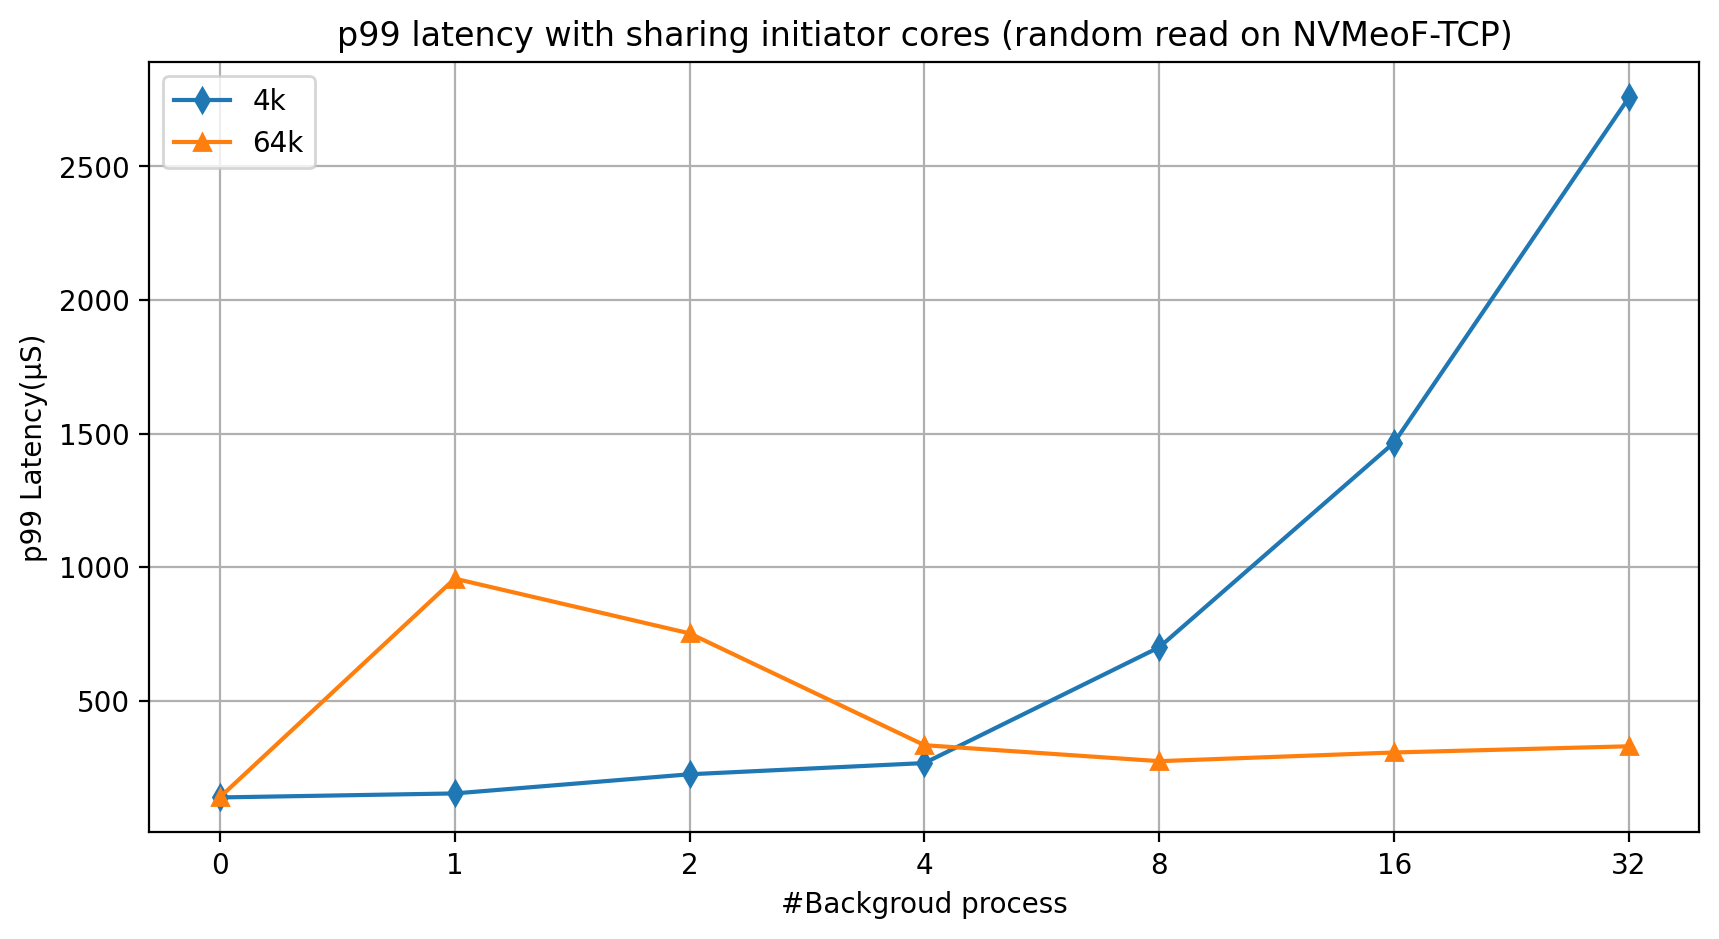

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_IS_TD_SD_baseline_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing initiator cores (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

4k [0.34283058245944975, 0.5156634223012924, 0.9979628721876144, 1.752688056755066, 1.7526476472988126, 1.7530147680177683]
64k [1.1213976768274307, 1.6882065808925628, 1.71292554783535, 1.7123967128658295, 1.7135663163871766, 1.7120761874666213]


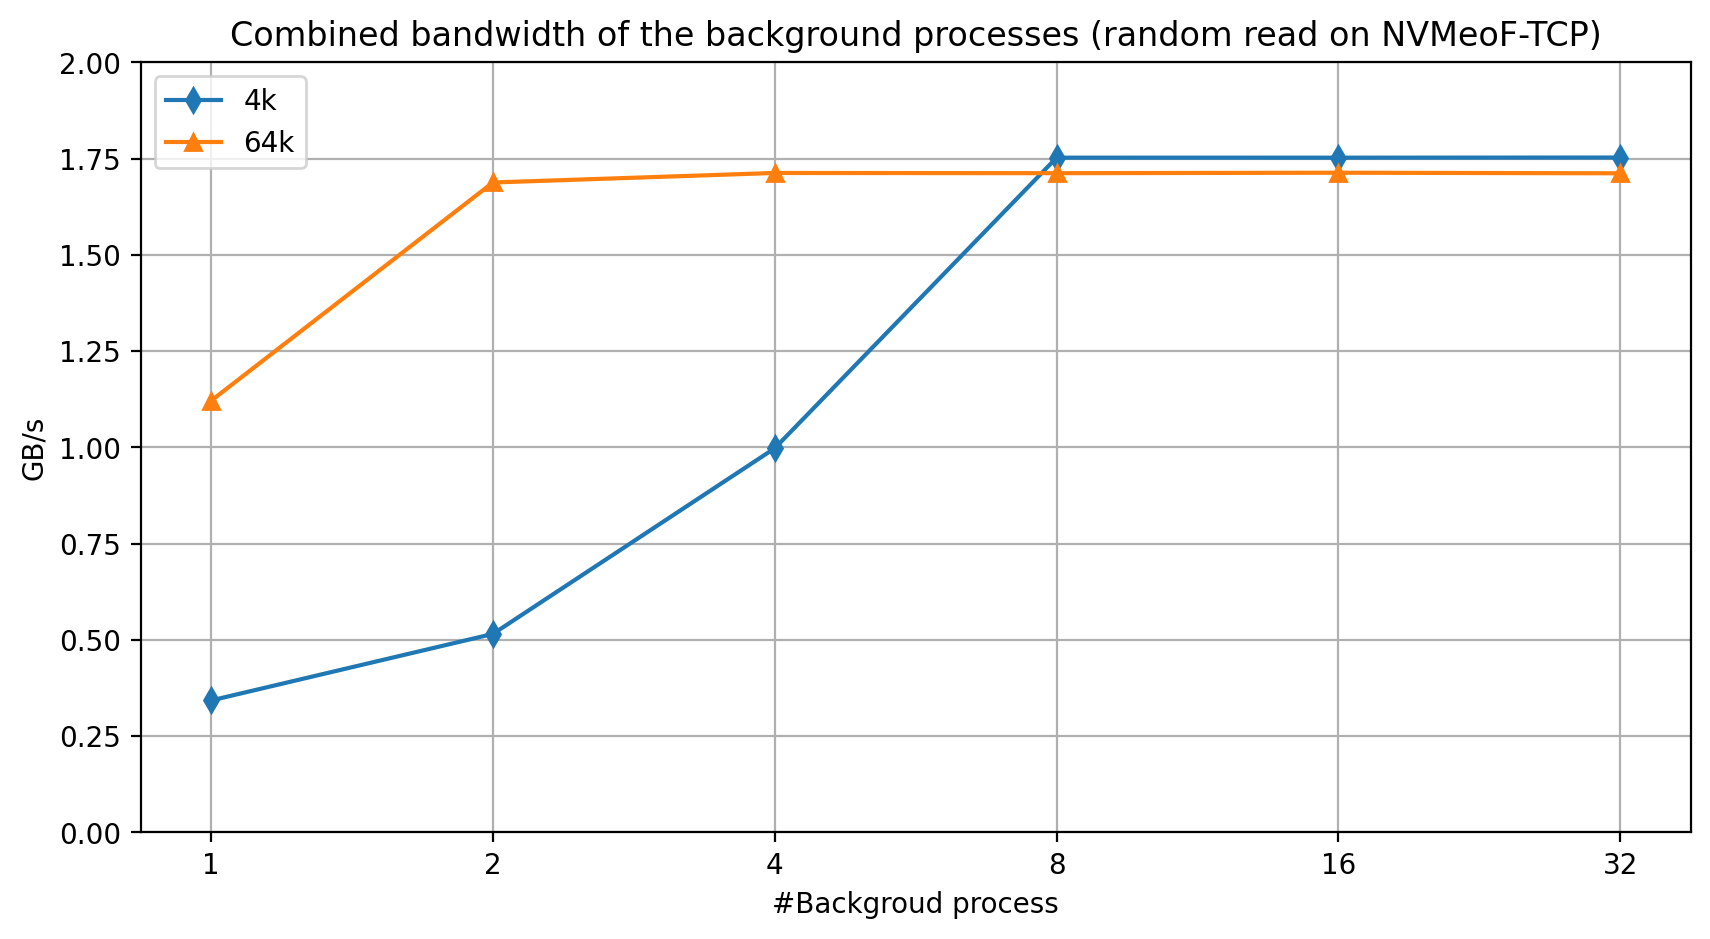

In [28]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [1, 2, 4, 8, 16, 32]:
        experiments.append("remote_IS_TD_SD_baseline_bread_fread_SSD_BP{}_BS{}_throughput".format(i, j))
    plot_bw_line(experiments, [1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Combined bandwidth of the background processes (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylim(0,2)
plt.legend()

remote_IS_TD_SD_baseline_bread_fread_SSD_BP0_BS4k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP1_BS4k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP2_BS4k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP4_BS4k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP8_BS4k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP16_BS4k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP32_BS4k_latency
4k [2.0, 2.0, 3.0, 3.0, 8.0, 13.333333333333334, 19.333333333333332]
remote_IS_TD_SD_baseline_bread_fread_SSD_BP0_BS64k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP1_BS64k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP2_BS64k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP4_BS64k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP8_BS64k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP16_BS64k_latency
remote_IS_TD_SD_baseline_bread_fread_SSD_BP32_BS64k_latency
64k [2.0, 15.333333333333334, 12.666666666666666, 4.0, 3.3333333333333335, 3.3333333333333335, 4.0]


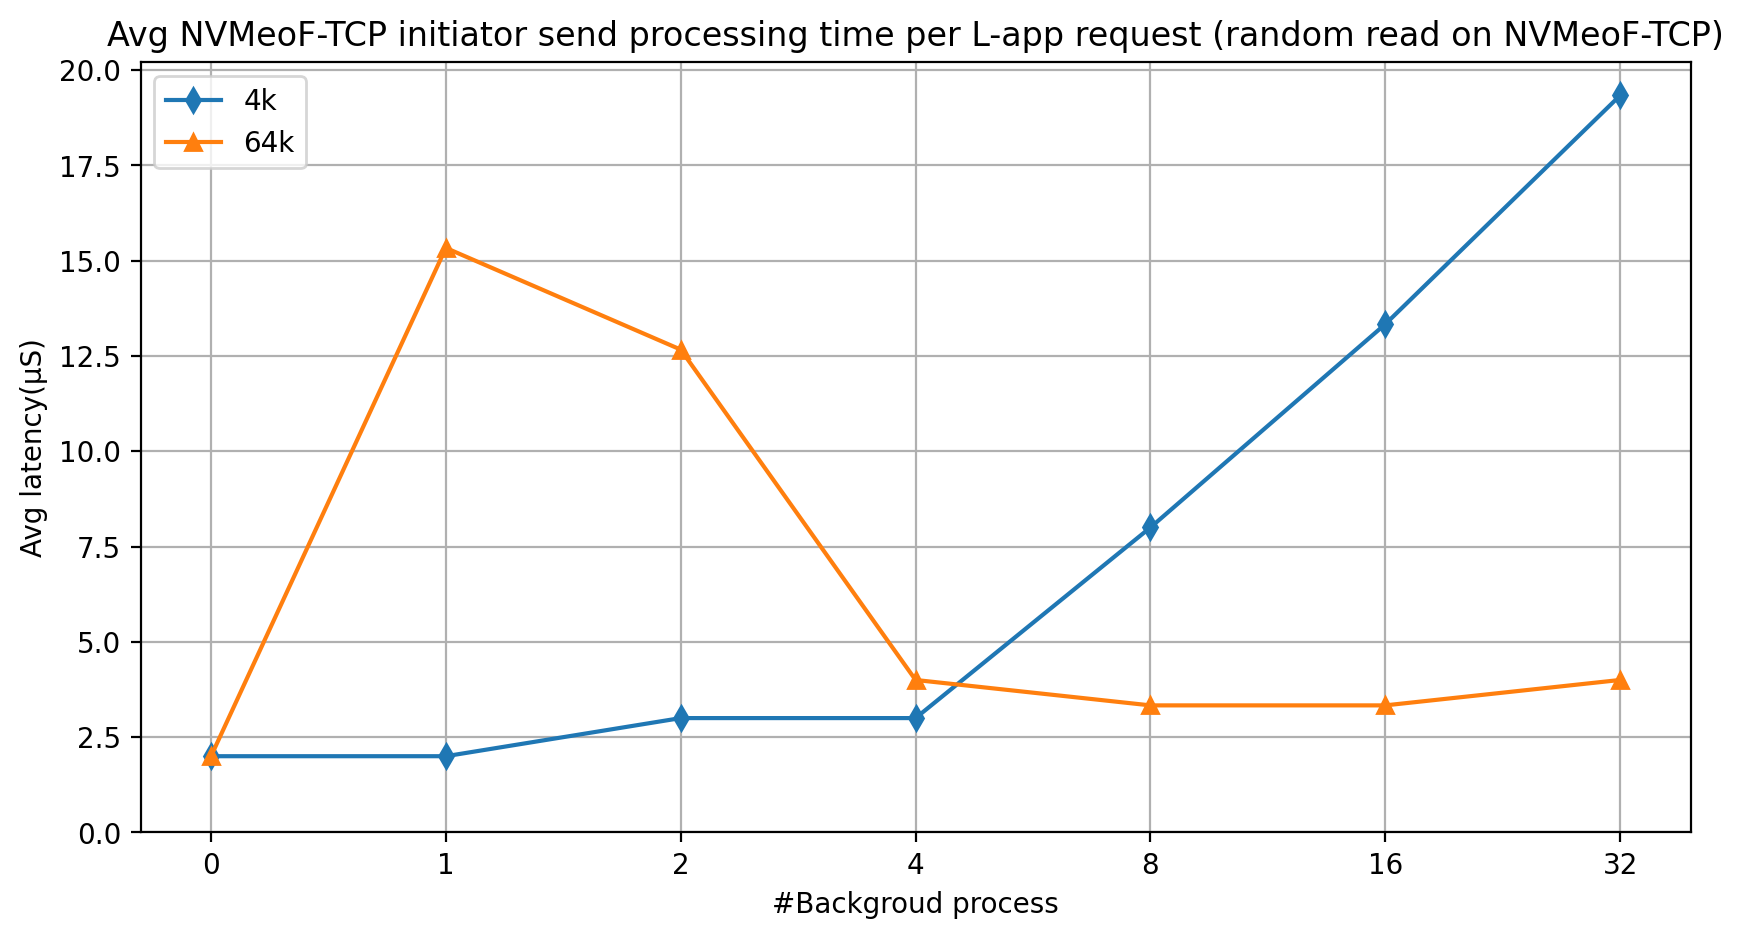

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0,1, 2,4,8,16,32]:
        experiments.append("remote_IS_TD_SD_baseline_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_init_rp_time(experiments, [0,1,2,4,8,16,32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Avg NVMeoF-TCP initiator send processing time per L-app request (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('Avg latency(' + u"\u03bc"+ 'S)')
plt.grid(True)
plt.ylim(0)
plt.legend()

4k [1158.56664, 1144.5000400000001, 1212.06668, 1143.3000000000002, 824.7665999999998, 623.46668, 469.16664]
64k [1193.36668, 1269.36668, 1290.7666799999997, 1128.5000400000001, 1122.26672, 1126.16664, 1111.33336]


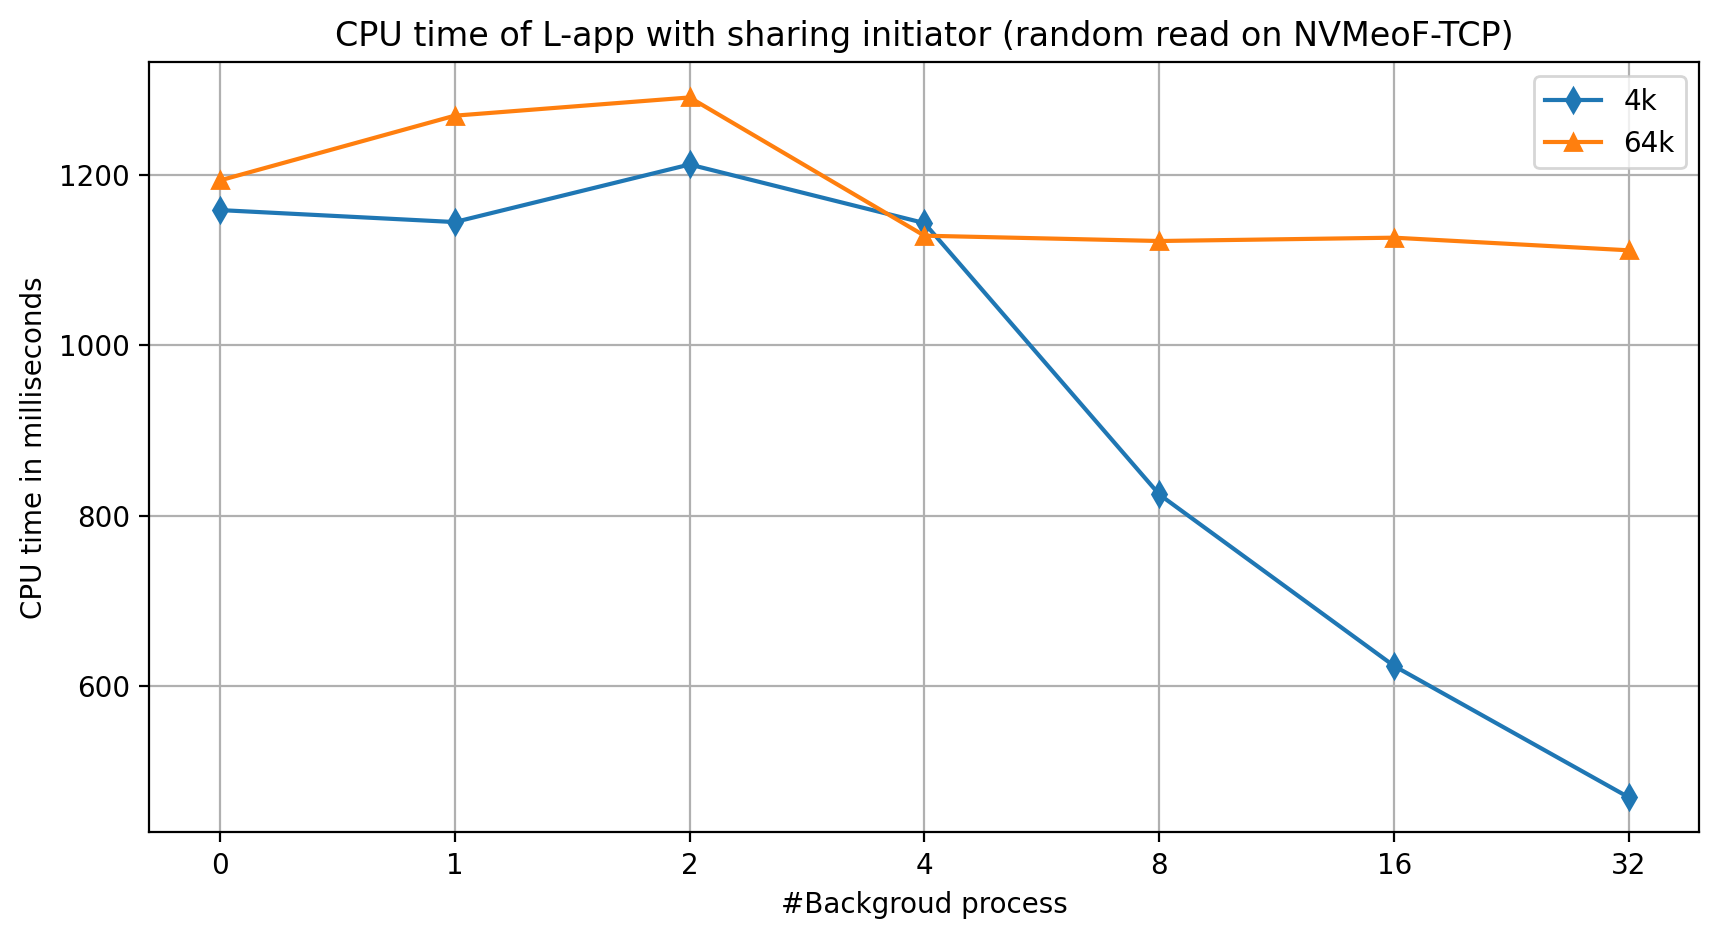

In [14]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0,1, 2,4,8,16,32]:
        experiments.append("remote_IS_TD_SD_baseline_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_run_time(experiments, [0,1, 2,4,8,16,32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('CPU time of L-app with sharing initiator (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('CPU time in milliseconds')
plt.grid(True)
plt.legend()

4k 99 [133.46133333333336, 444.416, 1258.8373333333332, 1892.352, 3522.56, 3609.9413333333337, 3642.7093333333337]
64k 99 [134.144, 2012.5013333333332, 4751.36, 11162.965333333334, 19267.584, 21539.498666666666, 21539.498666666666]


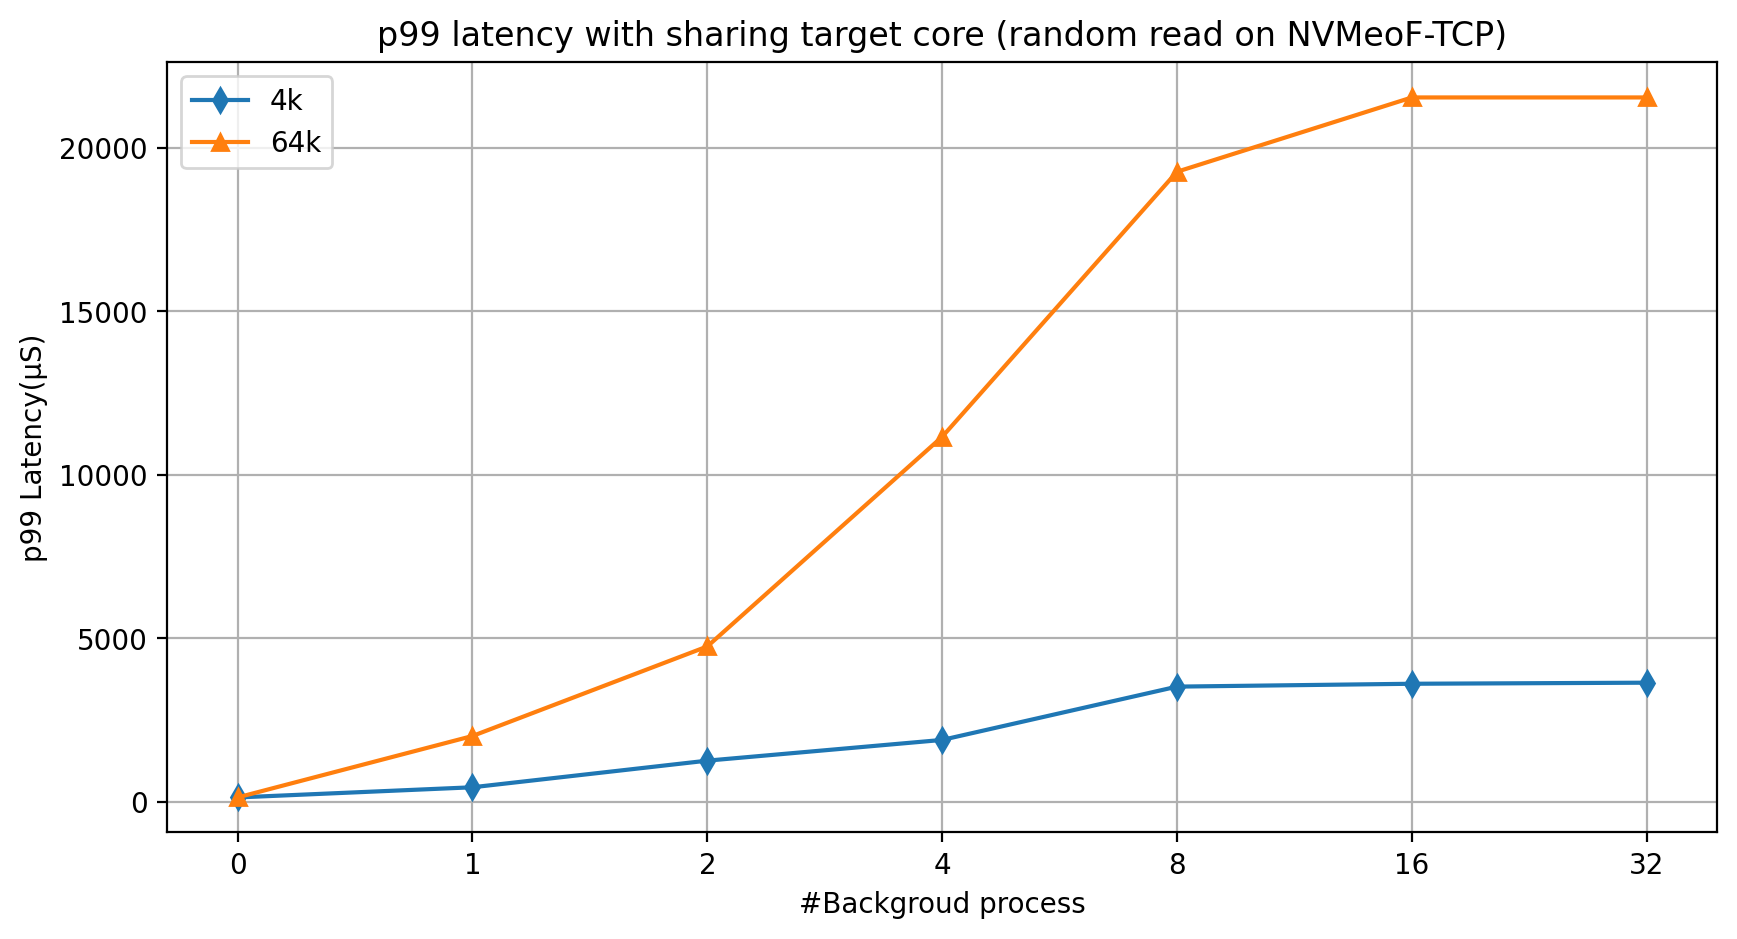

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TS_SD_split_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing target core (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

4k 99 [132.096, 235.17866666666666, 325.632, 1444.5226666666667, 3511.6373333333336, 2211.84, 2113.536]
64k 99 [133.46133333333336, 2441.216, 8454.144, 9109.504, 9153.194666666666, 9153.194666666666, 9153.194666666666]


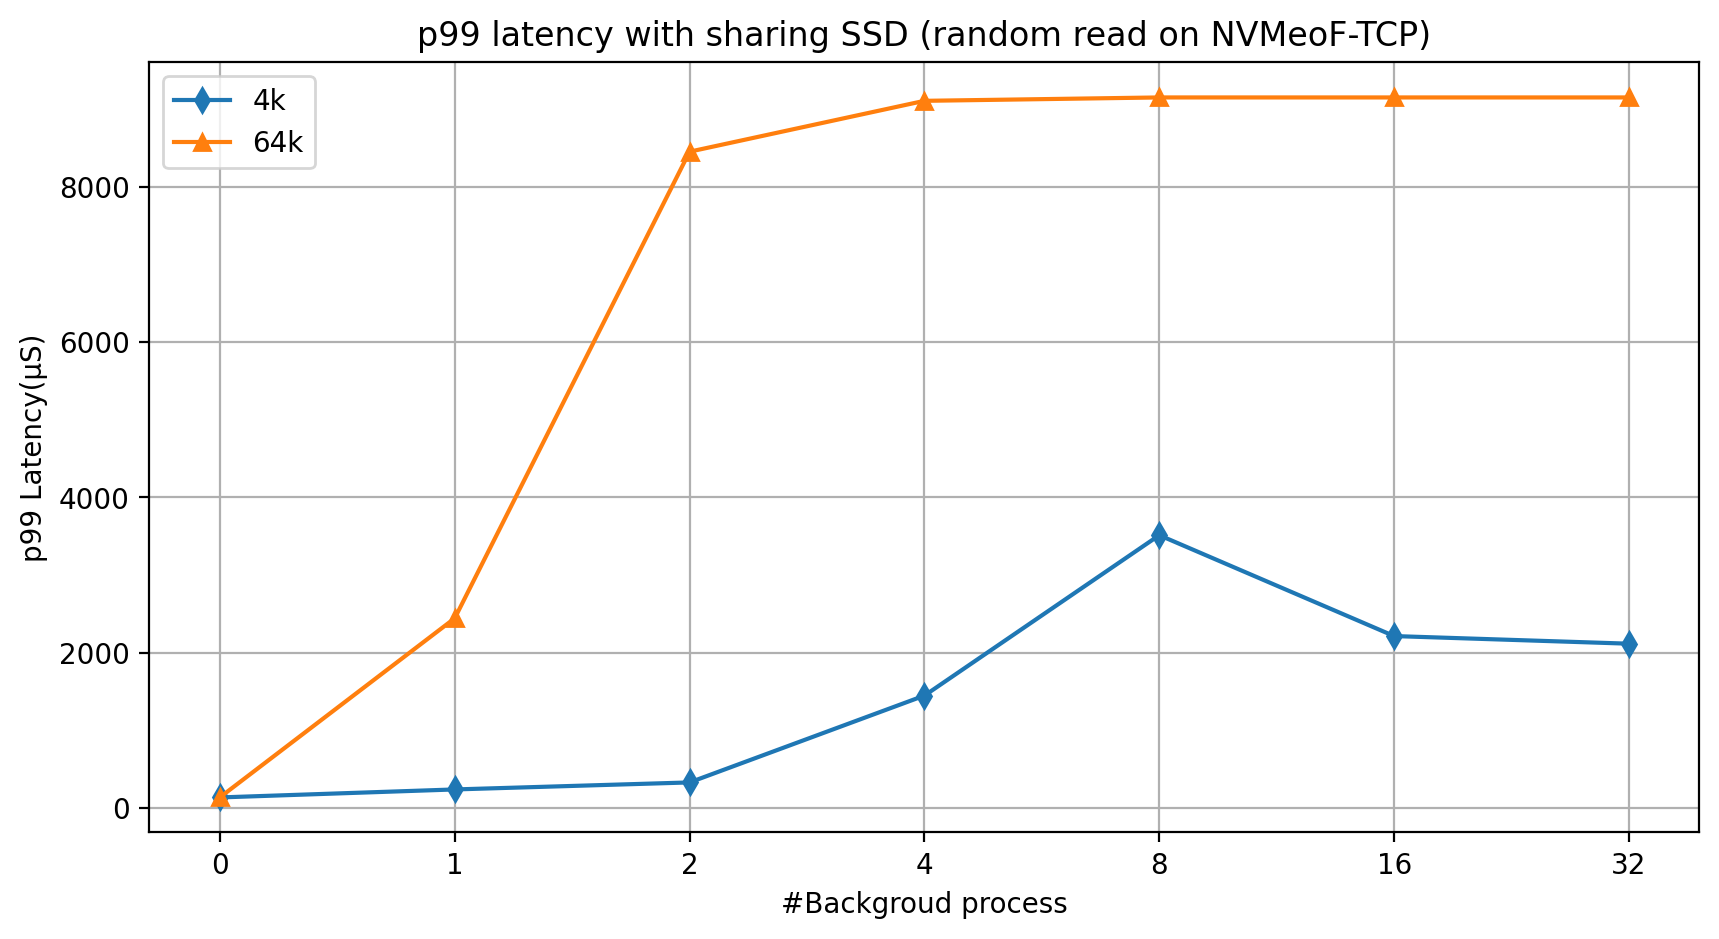

In [4]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_ID_TD_SS_baseline_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 16, 32], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing SSD (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

4k 99 [0.134144, 0.47581866666666667, 1.417216, 3.7082453333333336, 9.153194666666666, 140.85870933333334, 448.09147733333333]
64k 99 [0.13277866666666666, 4.642133333333333, 10.507605333333334, 27.394048, 56.885248, 466.96584533333333, 1315.8754986666668]


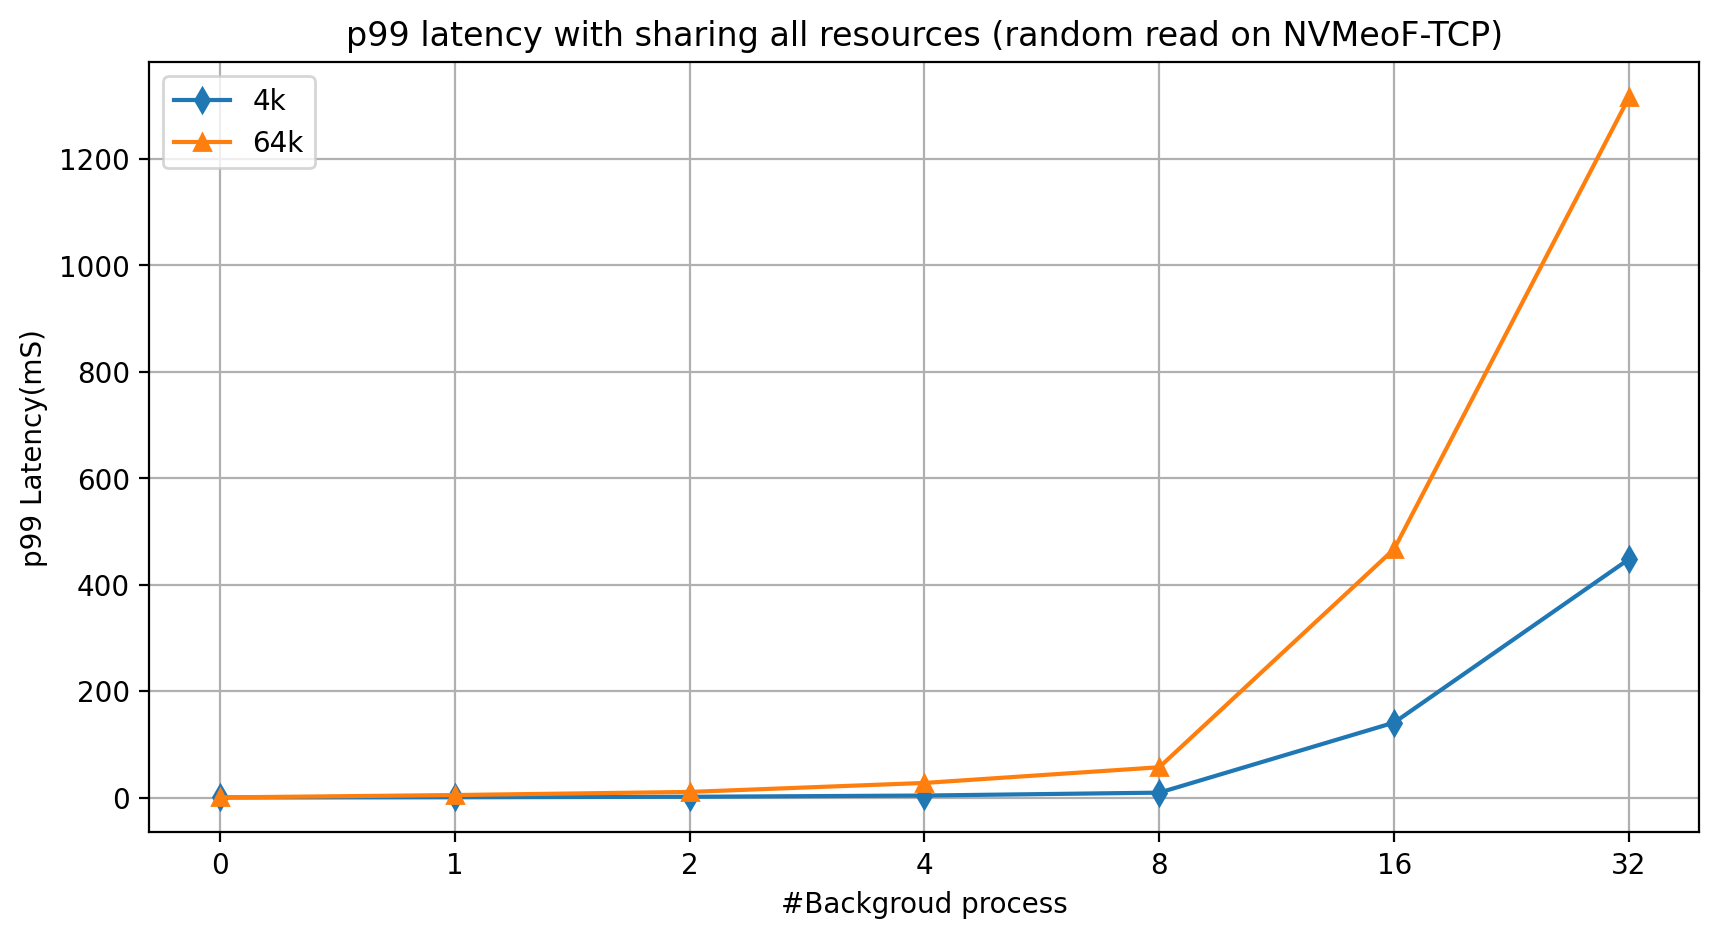

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["4k","64k"]:
    experiments=[]
    for i in [0, 1, 2, 4, 8, 16, 32]:
        experiments.append("remote_IS_TS_SS_baseline_bread_fread_SSD_BP{}_BS{}_latency".format(i, j))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 16, 32], j, 10**6)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with sharing all resources (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(mS)')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["baseline","nice5","nice10","nice15","nice19"]:
    experiments=[]
    for i in [0, 5, 10, 15, 20, 25, 30]:
        experiments.append("remote_IS_TD_SD_{}_bread_fread_SSD_BP{}_BS4k".format(j, i))
    label = "0"
    if "nice" in j:
        label = "-{}".format(j[4:])
    plot_lat_line(experiments, 99, [0, 5, 10, 15, 20, 25, 30], label)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with different nice values sharing initiator with 4KB BS (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["baseline","nice5","nice10","nice15","nice19"]:
    experiments=[]
    for i in [0, 5, 10, 15, 20, 25, 30]:
        experiments.append("remote_IS_TD_SD_{}_bread_fread_SSD_BP{}_BS4k".format(j, i))
    label = "0"
    if "nice" in j:
        label = "-{}".format(j[4:])
    plot_run_time(experiments, [0, 5, 10, 15, 20, 25, 30], label)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('CPU time of L-app with different nice values sharing initiator with 4KB BS (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('CPU time in seconds')
plt.grid(True)
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["baseline","baseline_tos"]:
    experiments=[]
    for i in [0, 5, 10, 15, 20, 25, 30]:
        experiments.append("remote_IS_TD_SD_{}_bread_fread_SSD_BP{}_BS4k".format(j, i))
    plot_lat_line(experiments, 99, [0, 5, 10, 15, 20, 25, 30], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with tos sharing initiator with 4KB BS (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["baseline","baseline_tos"]:
    experiments=[]
    for i in [0, 5, 10, 15, 20, 25, 30]:
        experiments.append("remote_IS_TD_SD_{}_bread_fread_SSD_BP{}_BS64k".format(j, i))
    plot_lat_line(experiments, 99, [0, 5, 10, 15, 20, 25, 30], j)

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with tos sharing initiator with 64KB BS (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

None 99 [88.576, 366.592, 1728.512, 1728.512, 2088.96, 4423.68, 11599.872]
Poll 99 [82.432, 358.4, 1679.36, 1695.744, 1695.744, 1728.512, 1662.976]
MQ-Deadline 99 [81.408, 201.728, 497.664, 765.952, 2473.984, 3620.864, 6062.08]
IONice 99 [81.408, 209.92, 593.92, 815.104, 2375.68, 3850.24, 5865.472]
Nice -10 99 [81.408, 207.872, 561.152, 815.104, 1499.136, 2072.576, 2539.52]
Nice -19 99 [81.408, 203.776, 585.728, 806.912, 1400.832, 1761.28, 5210.112]


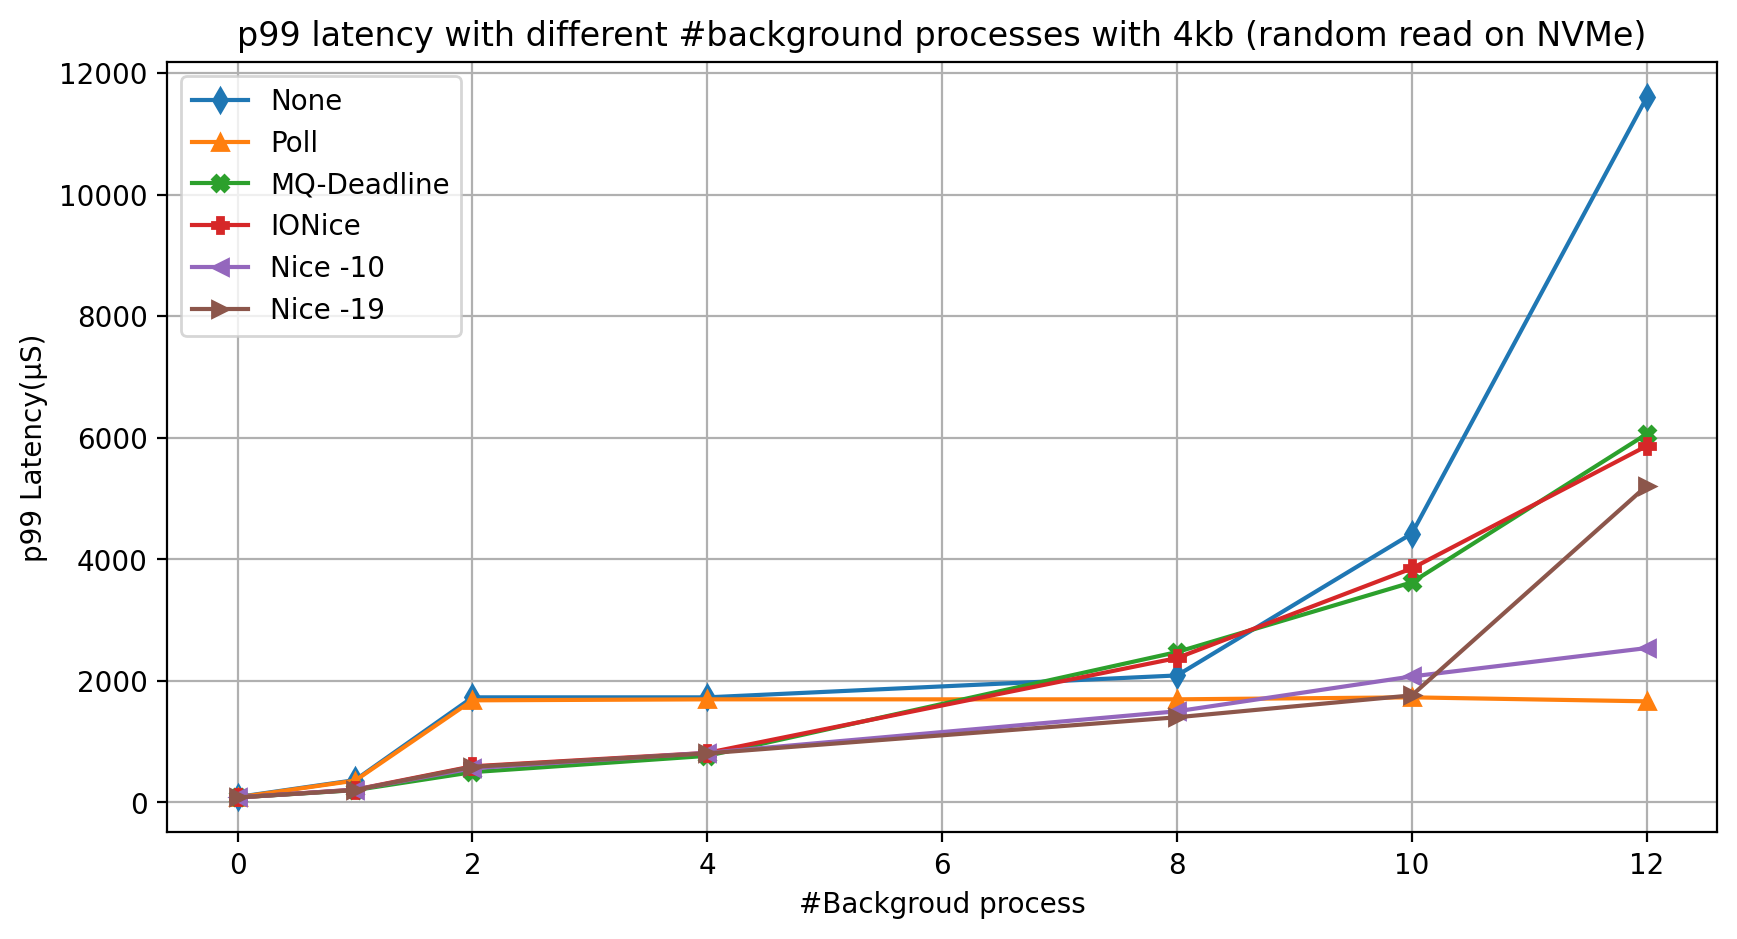

In [4]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels=["None","Poll", "MQ-Deadline", "IONice", "Nice -10","Nice -19"]
for k,j in enumerate(["baseline","poll","mqdpoll","pollprio","pollprio_nice10","pollprio_nice19"]):
    experiments = []
    for i in [0, 1, 2, 4, 8, 10, 12]:
        experiments.append("local_{}_bread_fread_SSD_BP{}_BS4k".format(j, i))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 10, 12], labels[k])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with different #background processes with 4kb (random read on NVMe)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

None 99 [89.6, 4292.608, 8716.288, 9371.648, 38010.88, 63700.992, 116916.224]
Poll 99 [82.432, 4177.92, 8716.288, 8716.288, 8847.36, 8847.36, 8847.36]
MQ-Deadline 99 [82.432, 4112.384, 8716.288, 8716.288, 8847.36, 8847.36, 8847.36]
IONice 99 [81.408, 4177.92, 8716.288, 8716.288, 8847.36, 8847.36, 8847.36]
Nice -10 99 [81.408, 4177.92, 8716.288, 8847.36, 8847.36, 8847.36, 8847.36]
Nice -19 99 [82.432, 4112.384, 8716.288, 8716.288, 8847.36, 8847.36, 8847.36]


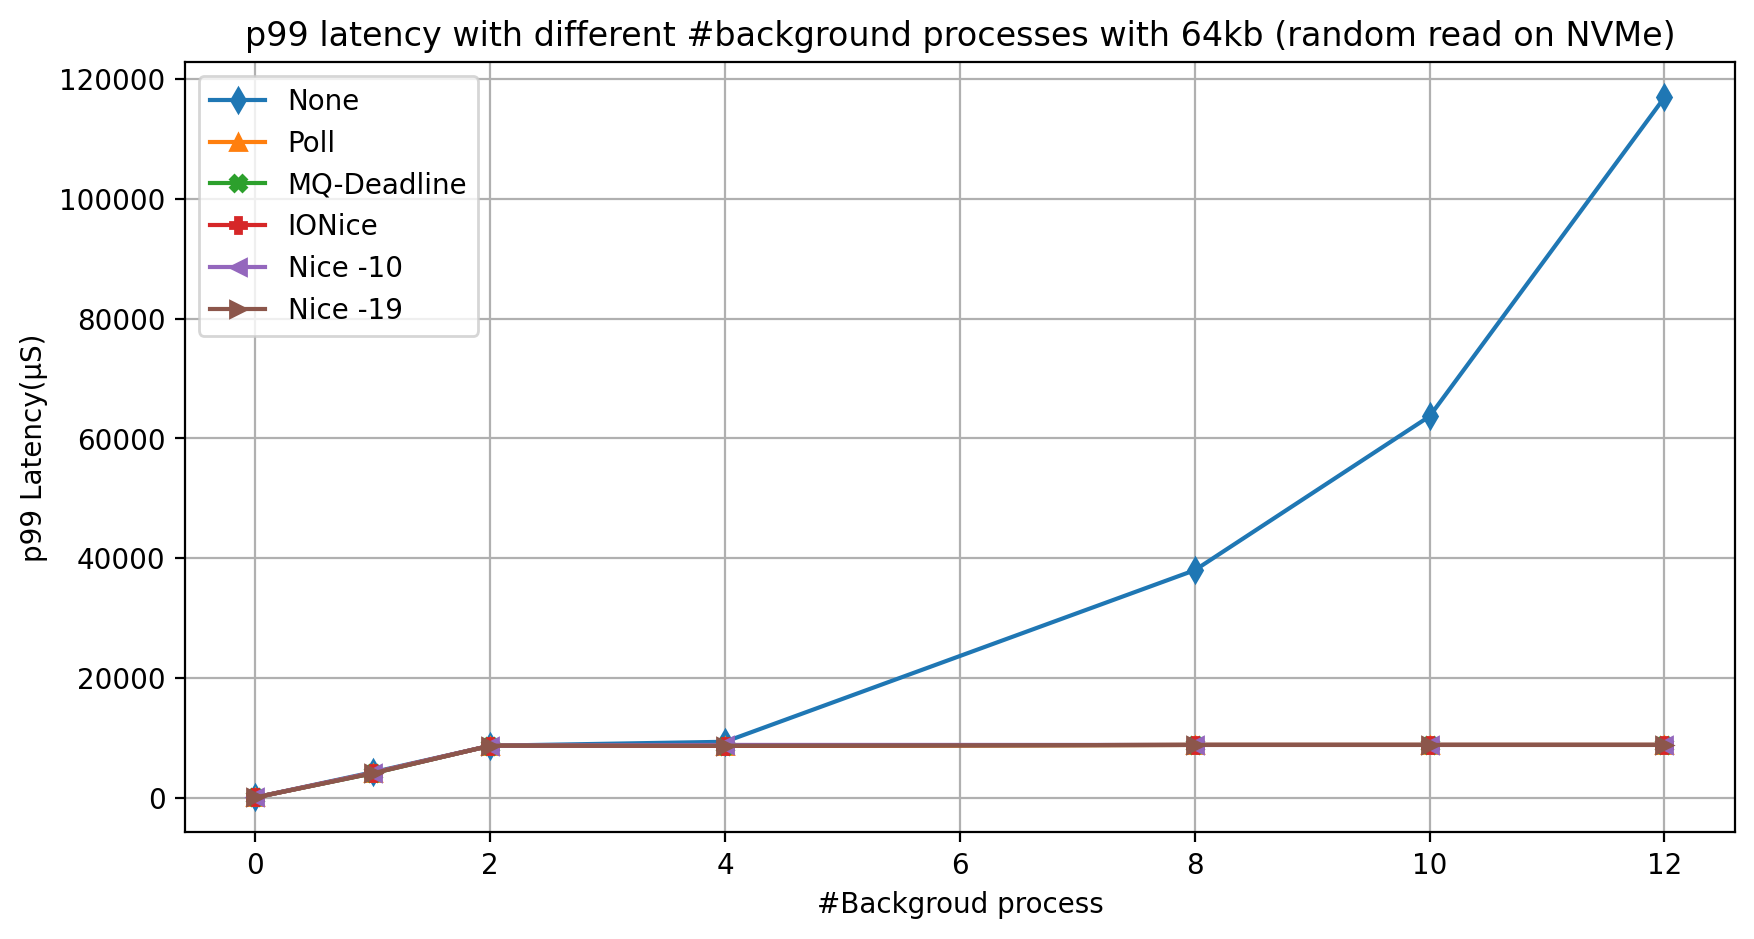

In [8]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels=["None", "Poll", "MQ-Deadline", "IONice", "Nice -10","Nice -19"]
for k,j in enumerate(["baseline","poll","mqdpoll","pollprio","pollprio_nice10", "pollprio_nice19"]):
    experiments = []
    for i in [0, 1, 2, 4, 8, 10, 12]:
        experiments.append("local_{}_bread_fread_SSD_BP{}_BS64k".format(j, i))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 10, 12], labels[k])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with different #background processes with 64kb (random read on NVMe)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

None 99 [228.352, 264.192, 313.344, 1220.608, 5341.184, 5996.544, 13434.88, 21364.736]
Poll 99 [152.576, 220.16, 272.384, 765.952, 3063.808, 4685.824, 13172.736, 28704.768]
MQ-Deadline 99 [156.672, 246.784, 268.288, 473.088, 2179.072, 4358.144, 11206.656, 13828.096]
IONice 99 [154.624, 248.832, 272.384, 415.744, 2146.304, 4227.072, 10158.08, 14090.24]
Nice -10 99 [152.576, 248.832, 272.384, 415.744, 1417.216, 1826.816, 3653.632, 5406.72]
Nice -19 99 [154.624, 248.832, 272.384, 464.896, 2244.608, 4227.072, 7766.016, 15532.032]


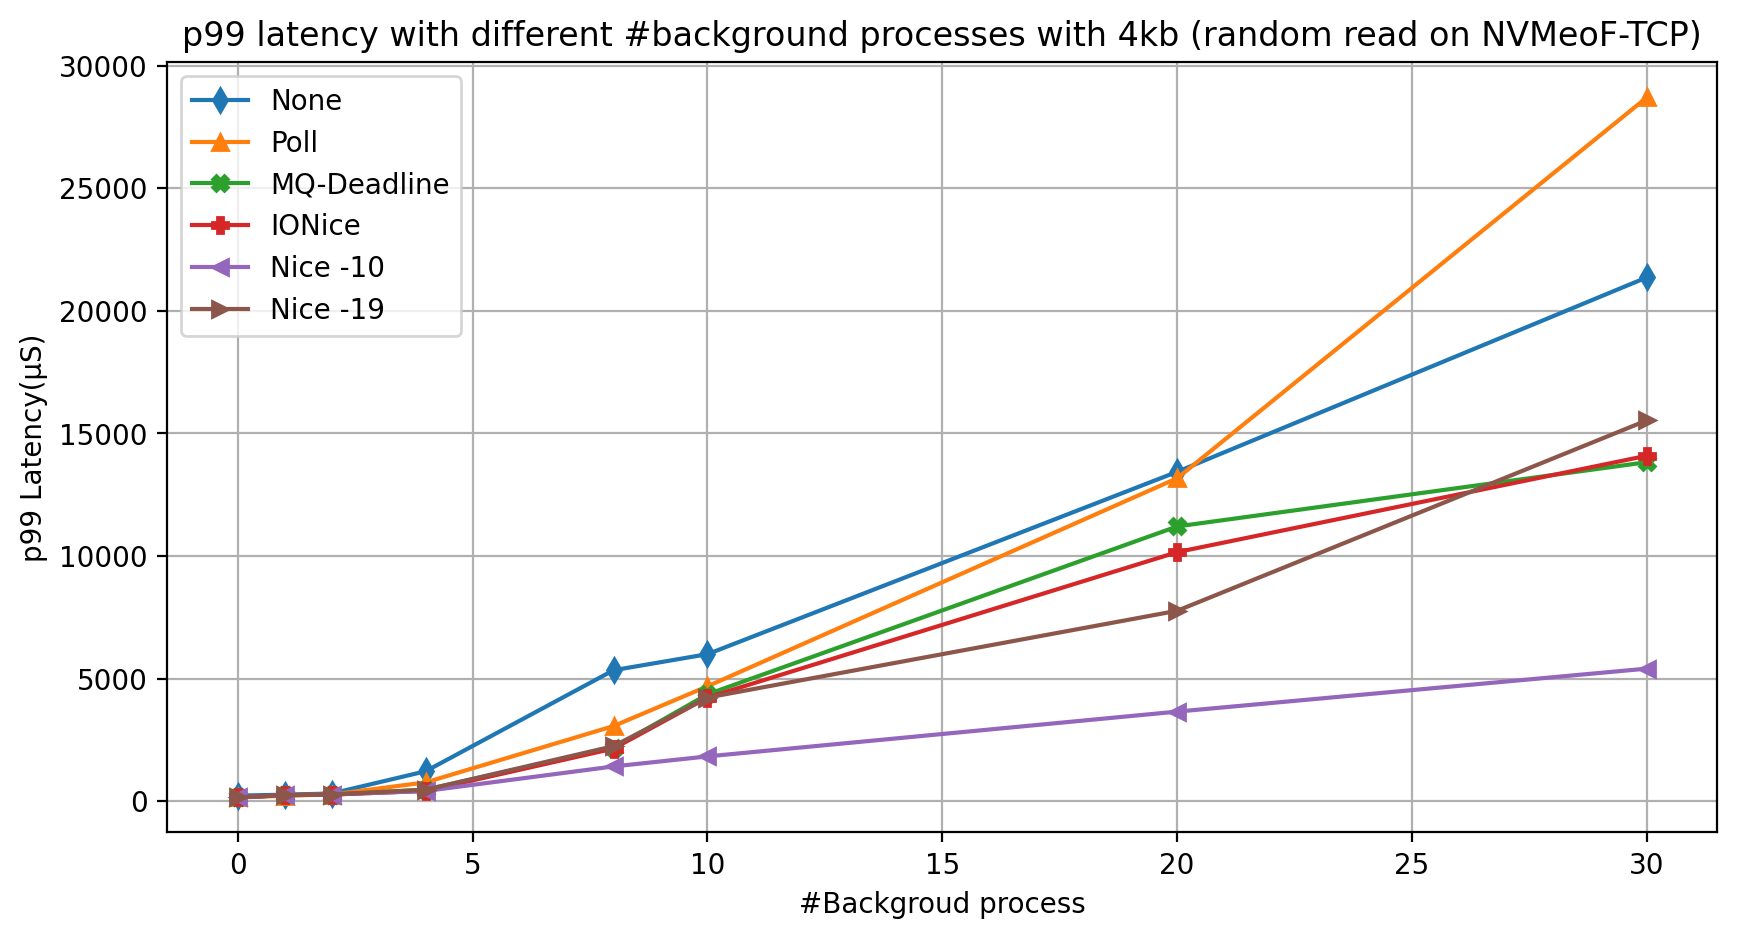

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels=["None","Poll", "MQ-Deadline", "IONice", "Nice -10","Nice -19"]
for k,j in enumerate(["baseline","poll","mqdpoll","pollprio","pollprio_nice10","pollprio_nice19"]):
    if j in ["baseline"]:
        pass
    experiments = []
    for i in [0, 1, 2, 4, 8, 10, 20, 30]:
        experiments.append("remote_{}_bread_fread_SSD_BP{}_BS4k".format(j, i))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 10, 20, 30], labels[k])
    if j in ["mqdpoll"]:
        pass
#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with different #background processes with 4kb (random read on NVMeoF-TCP)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
labels=["None","Poll", "MQ-Deadline", "IONice", "Nice -10","Nice -19"]
for k,j in enumerate(["baseline","poll","mqdpoll","pollprio","pollprio_nice10","pollprio_nice19"]):
    if j in ["baseline"]:
        continue
    experiments = []
    for i in [0, 1, 2, 4, 8, 10, 12]:
        experiments.append("remote_{}_bread_fread_SSD_BP{}_BS64k".format(j, i))
    plot_lat_line(experiments, 99, [0, 1, 2, 4, 8, 10, 12], labels[k])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('p99 latency with different #background processes with 64kb (random read on NVMe)')
plt.xlabel("#Backgroud process")
plt.ylabel('p99 Latency(' + u"\u03bc"+ 'S)')
plt.legend()

In [4]:
op = open("qos/crunched_micro.json")
data = json.load(op)

In [ ]:
for i in [0]:
    microbench(data, "remote_baseline_bread_fread_SSD_BP{}_BS4k_initiator_micro".format(i), 99, "BP{}".format(i), False)
plt.legend()
plt.ylabel("Latency(ns)")